In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mrwellsdavid/unsw-nb15


In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

DATASET AUDIT


In [4]:
import os
import pandas as pd
import numpy as np

BASE_PATH = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15"
TRAIN_PATH = os.path.join(
    BASE_PATH,
    "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv"
)

TEST_PATH = os.path.join(
    BASE_PATH,
    "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv"
)

print("Train exists:", os.path.exists(TRAIN_PATH))
print("Test exists :", os.path.exists(TEST_PATH))

train_df = pd.read_csv(
    TRAIN_PATH,
    encoding="latin1"
)

test_df = pd.read_csv(
    TEST_PATH,
    encoding="latin1"
)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train exists: True
Test exists : True
Train shape: (82332, 45)
Test shape : (175341, 45)

Train columns:
['ï»¿id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Test columns:
['ï»¿id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm'

In [5]:
print("========== DATASET SCHEMA CHECK ==========")

print("\nTRAIN:")
print(train_df.shape)

print("\nTEST:")
print(test_df.shape)

print("\nTRAIN COLUMNS:")
print(train_df.columns.tolist())

print("\nTEST COLUMNS:")
print(test_df.columns.tolist())

print("\nCOLUMN SETS IDENTICAL:")
print(
    set(train_df.columns) == set(test_df.columns)
)

print("\nTRAIN ONLY:")
print(
    sorted(set(train_df.columns) - set(test_df.columns))
)

print("\nTEST ONLY:")
print(
    sorted(set(test_df.columns) - set(train_df.columns))
)

========== DATASET SCHEMA CHECK ==========

TRAIN:
(82332, 45)

TEST:
(175341, 45)

TRAIN COLUMNS:
['ï»¿id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

TEST COLUMNS:
['ï»¿id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_

In [6]:
print("========== TARGET CHECK ==========")

print("Train target candidates:")

for col in train_df.columns:
    if col.lower() in [
        "label",
        "attack_cat",
        "attack category",
        "attack_category"
    ]:
        print(
            col,
            train_df[col].nunique(),
            train_df[col].unique()[:20]
        )

print("\nLast columns:")
print(train_df.columns[-10:].tolist())

========== TARGET CHECK ==========
Train target candidates:
attack_cat 10 ['Normal' 'Reconnaissance' 'Backdoor' 'DoS' 'Exploits' 'Analysis'
 'Fuzzers' 'Worms' 'Shellcode' 'Generic']
label 2 [0 1]

Last columns:
['ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [7]:
print("\n" + "="*60)
print("UNSW-NB15 NEW DATASET AUDIT")
print("="*60)

print("\nTRAIN SHAPE:")
print(train_df.shape)

print("\nTEST SHAPE:")
print(test_df.shape)

print("\nTRAIN MISSING VALUES:")
print(train_df.isna().sum().sum())

print("\nTEST MISSING VALUES:")
print(test_df.isna().sum().sum())

print("\nTRAIN DUPLICATES:")
print(train_df.duplicated().sum())

print(
    "Duplicate percentage:",
    f"{100 * train_df.duplicated().mean():.4f}%"
)

print("\nTEST DUPLICATES:")
print(test_df.duplicated().sum())

print(
    "Duplicate percentage:",
    f"{100 * test_df.duplicated().mean():.4f}%"
)


UNSW-NB15 NEW DATASET AUDIT

TRAIN SHAPE:
(82332, 45)

TEST SHAPE:
(175341, 45)

TRAIN MISSING VALUES:
0

TEST MISSING VALUES:
0

TRAIN DUPLICATES:
0
Duplicate percentage: 0.0000%

TEST DUPLICATES:
0
Duplicate percentage: 0.0000%


In [8]:
print("\n" + "="*60)
print("LABEL DISTRIBUTION")
print("="*60)

for name, df in [
    ("TRAIN", train_df),
    ("TEST", test_df)
]:
    
    print(f"\n===== {name} =====")
    
    counts = df["label"].value_counts()
    percentages = df["label"].value_counts(
        normalize=True
    ) * 100
    
    print(
        pd.DataFrame({
            "count": counts,
            "percentage": percentages
        })
    )


LABEL DISTRIBUTION

===== TRAIN =====
       count  percentage
label                   
1      45332   55.060001
0      37000   44.939999

===== TEST =====
        count  percentage
label                    
1      119341   68.062233
0       56000   31.937767


In [9]:
print("\n" + "="*60)
print("ATTACK CATEGORY DISTRIBUTION")
print("="*60)

for name, df in [
    ("TRAIN", train_df),
    ("TEST", test_df)
]:
    
    print(f"\n===== {name} =====")
    
    counts = df["attack_cat"].value_counts(
        dropna=False
    )
    
    percentages = (
        df["attack_cat"]
        .value_counts(normalize=True, dropna=False)
        * 100
    )
    
    print(
        pd.DataFrame({
            "count": counts,
            "percentage": percentages
        })
    )


ATTACK CATEGORY DISTRIBUTION

===== TRAIN =====
                count  percentage
attack_cat                       
Normal          37000   44.939999
Generic         18871   22.920614
Exploits        11132   13.520867
Fuzzers          6062    7.362872
DoS              4089    4.966477
Reconnaissance   3496    4.246223
Analysis          677    0.822281
Backdoor          583    0.708109
Shellcode         378    0.459117
Worms              44    0.053442

===== TEST =====
                count  percentage
attack_cat                       
Normal          56000   31.937767
Generic         40000   22.812691
Exploits        33393   19.044605
Fuzzers         18184   10.370649
DoS             12264    6.994371
Reconnaissance  10491    5.983198
Analysis         2000    1.140635
Backdoor         1746    0.995774
Shellcode        1133    0.646169
Worms             130    0.074141


In [10]:
feature_cols = [
    c for c in train_df.columns
    if c not in ["label", "attack_cat"]
]

print("Number of feature columns:", len(feature_cols))

Number of feature columns: 43


In [11]:
from pandas.util import hash_pandas_object

train_hash = set(
    hash_pandas_object(
        train_df[feature_cols],
        index=False
    )
)

test_hash = hash_pandas_object(
    test_df[feature_cols],
    index=False
)

overlap_mask = test_hash.isin(train_hash)

print("\n" + "="*60)
print("TRAIN / TEST FEATURE OVERLAP")
print("="*60)

print(
    "Test rows matching a training feature vector:",
    overlap_mask.sum()
)

print(
    "Percentage of test:",
    f"{100 * overlap_mask.mean():.4f}%"
)


TRAIN / TEST FEATURE OVERLAP
Test rows matching a training feature vector: 0
Percentage of test: 0.0000%


In [12]:
print("\n" + "="*60)
print("TRAIN / TEST LABEL CONSISTENCY")
print("="*60)

train_lookup = (
    train_df
    .groupby(feature_cols)["label"]
    .agg(["min", "max", "nunique"])
)

overlap_test = test_df.loc[
    overlap_mask
].copy()

overlap_test = overlap_test.merge(
    train_lookup,
    left_on=feature_cols,
    right_index=True,
    how="left"
)

overlap_test["label_same"] = (
    overlap_test["label"] == overlap_test["min"]
) & (
    overlap_test["min"] == overlap_test["max"]
)

print(
    "Overlapping test rows:",
    len(overlap_test)
)

print(
    "Consistent:",
    overlap_test["label_same"].sum()
)

print(
    "Potential conflicts:",
    (~overlap_test["label_same"]).sum()
)


TRAIN / TEST LABEL CONSISTENCY
Overlapping test rows: 0
Consistent: 0
Potential conflicts: 0


In [13]:
print("\n" + "="*60)
print("TRAIN FEATURE VECTOR LABEL CONSISTENCY")
print("="*60)

train_vector_labels = (
    train_df
    .groupby(feature_cols)["label"]
    .nunique()
)

ambiguous_vectors = (
    train_vector_labels > 1
)

print(
    "Unique feature vectors:",
    len(train_vector_labels)
)

print(
    "Feature vectors with multiple labels:",
    ambiguous_vectors.sum()
)

print(
    "Percentage ambiguous:",
    f"{100 * ambiguous_vectors.mean():.4f}%"
)


TRAIN FEATURE VECTOR LABEL CONSISTENCY
Unique feature vectors: 82332
Feature vectors with multiple labels: 0
Percentage ambiguous: 0.0000%


In [14]:
# ============================================================
# CORRECT UNSW-NB15 TRAIN / TEST ASSIGNMENT
# ============================================================

# The Kaggle filenames are reversed relative to the standard split.
# 175,341 rows = standard TRAINING set
# 82,332 rows  = standard TESTING set

actual_train_df = test_df.copy()
actual_test_df = train_df.copy()

train_df = actual_train_df
test_df = actual_test_df

print("Corrected TRAIN shape:", train_df.shape)
print("Corrected TEST shape :", test_df.shape)

print("\nTRAIN labels:")
print(train_df["label"].value_counts())

print("\nTEST labels:")
print(test_df["label"].value_counts())

Corrected TRAIN shape: (175341, 45)
Corrected TEST shape : (82332, 45)

TRAIN labels:
label
1    119341
0     56000
Name: count, dtype: int64

TEST labels:
label
1    45332
0    37000
Name: count, dtype: int64


In [15]:
print("=" * 60)
print("FINAL DATASET USED FOR EXPERIMENTS")
print("=" * 60)

print("TRAIN:", train_df.shape)
print("TEST :", test_df.shape)

print("\nTRAIN attack categories:")
print(train_df["attack_cat"].value_counts())

print("\nTEST attack categories:")
print(test_df["attack_cat"].value_counts())

FINAL DATASET USED FOR EXPERIMENTS
TRAIN: (175341, 45)
TEST : (82332, 45)

TRAIN attack categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

TEST attack categories:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [16]:
# ============================================================
# TRAIN / TEST EXACT FEATURE OVERLAP
# ============================================================

print("\n" + "=" * 60)
print("TRAIN / TEST EXACT FEATURE OVERLAP")
print("=" * 60)

feature_cols = [
    c for c in train_df.columns
    if c not in ["label", "attack_cat"]
]

print("Number of feature columns:", len(feature_cols))

# Hash training feature vectors
train_hashes = set(
    pd.util.hash_pandas_object(
        train_df[feature_cols],
        index=False
    )
)

# Hash test feature vectors
test_hashes = pd.util.hash_pandas_object(
    test_df[feature_cols],
    index=False
)

overlap_mask = test_hashes.isin(train_hashes)

overlap_count = overlap_mask.sum()

print("Training samples:", len(train_df))
print("Test samples:", len(test_df))

print(
    "Test rows matching a training feature vector:",
    overlap_count
)

print(
    "Overlap percentage:",
    f"{100 * overlap_count / len(test_df):.4f}%"
)


TRAIN / TEST EXACT FEATURE OVERLAP
Number of feature columns: 43
Training samples: 175341
Test samples: 82332
Test rows matching a training feature vector: 0
Overlap percentage: 0.0000%


In [17]:
# ============================================================
# OVERLAPPING FEATURE VECTOR → LABEL CONSISTENCY
# ============================================================

print("\n" + "=" * 60)
print("OVERLAP LABEL CONSISTENCY")
print("=" * 60)

# Map each training feature vector to its set of labels
train_label_map = (
    train_df
    .groupby(feature_cols)["label"]
    .agg(["min", "max", "nunique"])
)

overlap_test = test_df.loc[overlap_mask].copy()

overlap_test = overlap_test.merge(
    train_label_map,
    left_on=feature_cols,
    right_index=True,
    how="left"
)

# Same label if training vector has one label
# and that label equals the test label
overlap_test["label_consistent"] = (
    (overlap_test["nunique"] == 1) &
    (overlap_test["label"] == overlap_test["min"])
)

print("Overlapping test rows:", len(overlap_test))

print(
    "Label-consistent:",
    overlap_test["label_consistent"].sum()
)

print(
    "Label conflicts:",
    (~overlap_test["label_consistent"]).sum()
)

if len(overlap_test) > 0:
    print(
        "Consistency:",
        f"{100 * overlap_test['label_consistent'].mean():.4f}%"
    )


OVERLAP LABEL CONSISTENCY
Overlapping test rows: 0
Label-consistent: 0
Label conflicts: 0


In [18]:
# ============================================================
# TRAIN FEATURE VECTOR → LABEL AMBIGUITY
# ============================================================

print("\n" + "=" * 60)
print("TRAIN FEATURE VECTOR → LABEL AMBIGUITY")
print("=" * 60)

train_vector_label_counts = (
    train_df
    .groupby(feature_cols)["label"]
    .nunique()
)

ambiguous_vectors = train_vector_label_counts > 1

print(
    "Unique feature vectors:",
    len(train_vector_label_counts)
)

print(
    "Feature vectors with multiple labels:",
    ambiguous_vectors.sum()
)

print(
    "Ambiguous vector percentage:",
    f"{100 * ambiguous_vectors.mean():.4f}%"
)


TRAIN FEATURE VECTOR → LABEL AMBIGUITY
Unique feature vectors: 175341
Feature vectors with multiple labels: 0
Ambiguous vector percentage: 0.0000%


In [19]:
# ============================================================
# TRAIN FEATURE VECTOR → ATTACK CATEGORY AMBIGUITY
# ============================================================

print("\n" + "=" * 60)
print("TRAIN FEATURE VECTOR → ATTACK CATEGORY")
print("=" * 60)

train_attack_vector_counts = (
    train_df
    .groupby(feature_cols)["attack_cat"]
    .nunique()
)

ambiguous_attack_vectors = (
    train_attack_vector_counts > 1
)

print(
    "Feature vectors with multiple attack categories:",
    ambiguous_attack_vectors.sum()
)

print(
    "Ambiguous percentage:",
    f"{100 * ambiguous_attack_vectors.mean():.4f}%"
)


TRAIN FEATURE VECTOR → ATTACK CATEGORY
Feature vectors with multiple attack categories: 0
Ambiguous percentage: 0.0000%


In [20]:
print("\nDATA TYPES")
print(test_df.dtypes.to_string())


DATA TYPES
ï»¿id                  int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct

In [21]:
print("=" * 70)
print("ACTUAL TEST DATASET FEATURES")
print("=" * 70)

for i, col in enumerate(test_df.columns):
    print(f"{i:02d} : {repr(col)}")

ACTUAL TEST DATASET FEATURES
00 : 'ï»¿id'
01 : 'dur'
02 : 'proto'
03 : 'service'
04 : 'state'
05 : 'spkts'
06 : 'dpkts'
07 : 'sbytes'
08 : 'dbytes'
09 : 'rate'
10 : 'sttl'
11 : 'dttl'
12 : 'sload'
13 : 'dload'
14 : 'sloss'
15 : 'dloss'
16 : 'sinpkt'
17 : 'dinpkt'
18 : 'sjit'
19 : 'djit'
20 : 'swin'
21 : 'stcpb'
22 : 'dtcpb'
23 : 'dwin'
24 : 'tcprtt'
25 : 'synack'
26 : 'ackdat'
27 : 'smean'
28 : 'dmean'
29 : 'trans_depth'
30 : 'response_body_len'
31 : 'ct_srv_src'
32 : 'ct_state_ttl'
33 : 'ct_dst_ltm'
34 : 'ct_src_dport_ltm'
35 : 'ct_dst_sport_ltm'
36 : 'ct_dst_src_ltm'
37 : 'is_ftp_login'
38 : 'ct_ftp_cmd'
39 : 'ct_flw_http_mthd'
40 : 'ct_src_ltm'
41 : 'ct_srv_dst'
42 : 'is_sm_ips_ports'
43 : 'attack_cat'
44 : 'label'


MLP + RF BASELINE

In [22]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [23]:
# ============================================================
# REPRODUCIBLE CLEAN BASELINE: MLP + RANDOM FOREST
# UNSW-NB15 CLEAN DATASET
#
# Primary seeds:
#     42, 123, 2026
#
# Reports:
#     - Per-seed TPR
#     - Per-seed AUROC
#     - Per-seed AUPRC
#     - Mean ± SD across the three seeds
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import random
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEEDS = [42, 123, 2026]


def set_seed(seed):
    """
    Set all relevant random seeds for reproducible experiments.
    """

    # Python
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic CUDA behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Where supported by the installed PyTorch version
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


# ============================================================
# 2. DATA
# ============================================================

TARGET = "label"

# attack_cat directly describes the attack category.
# It is therefore excluded to prevent label leakage.
DROP_COLS = [
    "label",
    "attack_cat"
]


# ------------------------------------------------------------
# IMPORTANT:
#
# train_df and test_df are assumed to have already been
# created using the FINAL dataset split.
#
# This cell does NOT recreate the train/test split.
# ------------------------------------------------------------

feature_cols = [
    c for c in train_df.columns
    if c not in DROP_COLS
]


X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[TARGET].astype(int).to_numpy()
y_test = test_df[TARGET].astype(int).to_numpy()


print("=" * 80)
print("CLEAN BASELINE DATA")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTrain labels:")
print(pd.Series(y_train).value_counts())

print("\nTest labels:")
print(pd.Series(y_test).value_counts())


# ============================================================
# 3. IDENTIFY FEATURE TYPES
# ============================================================

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()


print("\nNumeric features    :", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)


# ============================================================
# 4. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])


print("\n" + "=" * 80)
print("PREPROCESSING")
print("=" * 80)

print("Fitting preprocessor on training data...")


# IMPORTANT:
# Fit ONLY on training data.
X_train_processed = preprocessor.fit_transform(
    X_train
)

# Test data is transformed using the SAME fitted preprocessor.
X_test_processed = preprocessor.transform(
    X_test
)


print(
    "Processed train shape:",
    X_train_processed.shape
)

print(
    "Processed test shape :",
    X_test_processed.shape
)


# ============================================================
# 5. CONVERT DATA TO NUMPY
# ============================================================

X_train_np = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_test_np = np.asarray(
    X_test_processed,
    dtype=np.float32
)

y_train_np = y_train.astype(
    np.float32
)

y_test_np = y_test.astype(
    np.float32
)


# ============================================================
# 6. MLP ARCHITECTURE
# ============================================================

class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                1
            )
        )

    def forward(self, x):

        return self.network(
            x
        ).squeeze(1)


# ============================================================
# 7. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", device)


# ============================================================
# 8. FUNCTION: TRAIN + EVALUATE MLP
# ============================================================

def run_mlp(seed):

    print("\n")
    print("=" * 80)
    print(f"MLP — SEED {seed}")
    print("=" * 80)

    # --------------------------------------------------------
    # Set seed BEFORE creating model and DataLoader
    # --------------------------------------------------------

    set_seed(seed)


    # --------------------------------------------------------
    # PyTorch tensors
    # --------------------------------------------------------

    X_train_tensor = torch.tensor(
        X_train_np,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_np,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test_np,
        dtype=torch.float32
    )


    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )


    # --------------------------------------------------------
    # Deterministic DataLoader
    # --------------------------------------------------------

    generator = torch.Generator()

    generator.manual_seed(seed)


    train_loader = DataLoader(
        train_dataset,
        batch_size=512,
        shuffle=True,
        generator=generator,
        num_workers=0
    )


    # --------------------------------------------------------
    # Create model AFTER setting seed
    # --------------------------------------------------------

    model = MLP(
        X_train_np.shape[1]
    ).to(device)


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    criterion = nn.BCEWithLogitsLoss()


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    EPOCHS = 10

    print("\nTraining MLP...")

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0.0


        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)

            batch_y = batch_y.to(device)


            optimizer.zero_grad()


            logits = model(
                batch_X
            )


            loss = criterion(
                logits,
                batch_y
            )


            loss.backward()


            optimizer.step()


            total_loss += (
                loss.item()
                * len(batch_X)
            )


        avg_loss = (
            total_loss
            / len(train_dataset)
        )


        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} "
            f"- Loss: {avg_loss:.6f}"
        )


    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()


    with torch.no_grad():

        mlp_logits = model(
            X_test_tensor.to(device)
        )

        mlp_prob = torch.sigmoid(
            mlp_logits
        ).cpu().numpy()


    # --------------------------------------------------------
    # Classification at threshold = 0.5
    # --------------------------------------------------------

    mlp_pred = (
        mlp_prob >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mlp_tpr = recall_score(
        y_test,
        mlp_pred,
        zero_division=0
    )

    mlp_auroc = roc_auc_score(
        y_test,
        mlp_prob
    )

    mlp_auprc = average_precision_score(
        y_test,
        mlp_prob
    )


    print("\nMLP RESULTS")
    print("-" * 40)

    print(
        f"Seed  : {seed}"
    )

    print(
        f"TPR   : {mlp_tpr:.6f}"
    )

    print(
        f"AUROC : {mlp_auroc:.6f}"
    )

    print(
        f"AUPRC : {mlp_auprc:.6f}"
    )


    return {
        "Seed": seed,
        "TPR": mlp_tpr,
        "AUROC": mlp_auroc,
        "AUPRC": mlp_auprc
    }


# ============================================================
# 9. FUNCTION: TRAIN + EVALUATE RANDOM FOREST
# ============================================================

def run_random_forest(seed):

    print("\n")
    print("=" * 80)
    print(f"RANDOM FOREST — SEED {seed}")
    print("=" * 80)


    # Set NumPy/Python randomness for reproducibility
    set_seed(seed)


    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=seed,
        n_jobs=-1
    )


    print("Training Random Forest...")


    rf.fit(
        X_train_processed,
        y_train
    )


    # --------------------------------------------------------
    # Probability predictions
    # --------------------------------------------------------

    rf_prob = rf.predict_proba(
        X_test_processed
    )[:, 1]


    # --------------------------------------------------------
    # Classification at threshold = 0.5
    # --------------------------------------------------------

    rf_pred = (
        rf_prob >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    rf_tpr = recall_score(
        y_test,
        rf_pred,
        zero_division=0
    )

    rf_auroc = roc_auc_score(
        y_test,
        rf_prob
    )

    rf_auprc = average_precision_score(
        y_test,
        rf_prob
    )


    print("\nRF RESULTS")
    print("-" * 40)

    print(
        f"Seed  : {seed}"
    )

    print(
        f"TPR   : {rf_tpr:.6f}"
    )

    print(
        f"AUROC : {rf_auroc:.6f}"
    )

    print(
        f"AUPRC : {rf_auprc:.6f}"
    )


    return {
        "Seed": seed,
        "TPR": rf_tpr,
        "AUROC": rf_auroc,
        "AUPRC": rf_auprc
    }


# ============================================================
# 10. RUN MLP ACROSS ALL PRIMARY SEEDS
# ============================================================

mlp_results = []


for seed in SEEDS:

    result = run_mlp(seed)

    mlp_results.append(
        result
    )


mlp_results_df = pd.DataFrame(
    mlp_results
)


# ============================================================
# 11. RUN RF ACROSS ALL PRIMARY SEEDS
# ============================================================

rf_results = []


for seed in SEEDS:

    result = run_random_forest(seed)

    rf_results.append(
        result
    )


rf_results_df = pd.DataFrame(
    rf_results
)


# ============================================================
# 12. CALCULATE MEAN ± SD
# ============================================================

mlp_mean = mlp_results_df[
    ["TPR", "AUROC", "AUPRC"]
].mean()

mlp_std = mlp_results_df[
    ["TPR", "AUROC", "AUPRC"]
].std(
    ddof=1
)


rf_mean = rf_results_df[
    ["TPR", "AUROC", "AUPRC"]
].mean()

rf_std = rf_results_df[
    ["TPR", "AUROC", "AUPRC"]
].std(
    ddof=1
)


# ============================================================
# 13. FINAL CLEAN BASELINE TABLE
# ============================================================

final_baseline = pd.DataFrame({

    "Model": [
        "Random Forest",
        "MLP"
    ],

    "TPR": [
        f"{rf_mean['TPR']:.4f} ± {rf_std['TPR']:.4f}",
        f"{mlp_mean['TPR']:.4f} ± {mlp_std['TPR']:.4f}"
    ],

    "AUROC": [
        f"{rf_mean['AUROC']:.4f} ± {rf_std['AUROC']:.4f}",
        f"{mlp_mean['AUROC']:.4f} ± {mlp_std['AUROC']:.4f}"
    ],

    "AUPRC": [
        f"{rf_mean['AUPRC']:.4f} ± {rf_std['AUPRC']:.4f}",
        f"{mlp_mean['AUPRC']:.4f} ± {mlp_std['AUPRC']:.4f}"
    ]
})


# ============================================================
# 14. PRINT PER-SEED RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("MLP RESULTS ACROSS SEEDS")
print("=" * 80)

print(
    mlp_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print("\n")
print("=" * 80)
print("RANDOM FOREST RESULTS ACROSS SEEDS")
print("=" * 80)

print(
    rf_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 15. FINAL BASELINE
# ============================================================

print("\n")
print("=" * 80)
print("FINAL CLEAN BASELINE — MEAN ± SD")
print("=" * 80)

print(
    final_baseline.to_string(
        index=False
    )
)


# ============================================================
# 16. SAVE RESULTS
# ============================================================

mlp_results_df.to_csv(
    "MLP_clean_baseline_by_seed.csv",
    index=False
)

rf_results_df.to_csv(
    "RF_clean_baseline_by_seed.csv",
    index=False
)

final_baseline.to_csv(
    "clean_baseline_mean_sd.csv",
    index=False
)


print("\n")
print("=" * 80)
print("RESULT FILES SAVED")
print("=" * 80)

print("MLP_clean_baseline_by_seed.csv")
print("RF_clean_baseline_by_seed.csv")
print("clean_baseline_mean_sd.csv")

CLEAN BASELINE DATA
X_train: (175341, 43)
X_test : (82332, 43)

Train labels:
1    119341
0     56000
Name: count, dtype: int64

Test labels:
1    45332
0    37000
Name: count, dtype: int64

Numeric features    : 40
Categorical features: 3

Categorical columns:
['proto', 'service', 'state']

PREPROCESSING
Fitting preprocessor on training data...
Processed train shape: (175341, 195)
Processed test shape : (82332, 195)

Device: cpu


MLP — SEED 42

Training MLP...
Epoch 01/10 - Loss: 0.160476
Epoch 02/10 - Loss: 0.099631
Epoch 03/10 - Loss: 0.091877
Epoch 04/10 - Loss: 0.083002
Epoch 05/10 - Loss: 0.072714
Epoch 06/10 - Loss: 0.064325
Epoch 07/10 - Loss: 0.060800
Epoch 08/10 - Loss: 0.056124
Epoch 09/10 - Loss: 0.053967
Epoch 10/10 - Loss: 0.051573

MLP RESULTS
----------------------------------------
Seed  : 42
TPR   : 0.435211
AUROC : 0.667768
AUPRC : 0.751133


MLP — SEED 123

Training MLP...
Epoch 01/10 - Loss: 0.161831
Epoch 02/10 - Loss: 0.097790
Epoch 03/10 - Loss: 0.085963
Epoch 

In [24]:
# ============================================================
# FREEZE THE EXACT CLEAN BASELINE MODELS
#
# 3 MLPs + 3 Random Forests
# Seeds: 42, 123, 2026
#
# These SAME models will be used for ALL robustness tests.
# NO retraining during robustness experiments.
# ============================================================

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)


print("=" * 80)
print("FREEZING CLEAN BASELINE MODELS")
print("=" * 80)


# ============================================================
# 1. SEEDS
# ============================================================

SEEDS = [42, 123, 2026]


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


# ============================================================
# 3. CHECK DATA
# ============================================================

assert "X_train_np" in globals()
assert "X_test_np" in globals()
assert "y_train_np" in globals()
assert "y_test" in globals()
assert "preprocessor" in globals()

print("Training data :", X_train_np.shape)
print("Testing data  :", X_test_np.shape)


# ============================================================
# 4. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 5. MLP ARCHITECTURE
# EXACT SAME ARCHITECTURE AS BASELINE
# ============================================================

class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ============================================================
# 6. STORAGE
# ============================================================

# THESE ARE THE IMPORTANT VARIABLES
# They contain the actual frozen models.

mlp_models = {}
rf_models = {}

mlp_baseline_results = []
rf_baseline_results = []


# ============================================================
# 7. TRAIN MLPs
# ============================================================

for seed in SEEDS:

    print("\n" + "=" * 80)
    print(f"TRAINING + FREEZING MLP — SEED {seed}")
    print("=" * 80)

    set_seed(seed)

    # --------------------------------------------------------
    # tensors
    # --------------------------------------------------------

    X_train_tensor = torch.tensor(
        X_train_np,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_np,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test_np,
        dtype=torch.float32
    )


    # --------------------------------------------------------
    # dataset
    # --------------------------------------------------------

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )


    # --------------------------------------------------------
    # deterministic DataLoader
    # --------------------------------------------------------

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=512,
        shuffle=True,
        generator=generator,
        num_workers=0
    )


    # --------------------------------------------------------
    # CREATE MODEL
    # --------------------------------------------------------

    mlp = MLP(
        X_train_np.shape[1]
    ).to(device)


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    criterion = nn.BCEWithLogitsLoss()


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        mlp.parameters(),
        lr=1e-3
    )


    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    EPOCHS = 10

    for epoch in range(EPOCHS):

        mlp.train()

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            logits = mlp(batch_X)

            loss = criterion(
                logits,
                batch_y
            )

            loss.backward()

            optimizer.step()


    # --------------------------------------------------------
    # EVALUATE CLEAN TEST SET
    # --------------------------------------------------------

    mlp.eval()

    with torch.no_grad():

        logits = mlp(
            X_test_tensor.to(device)
        )

        prob = torch.sigmoid(
            logits
        ).cpu().numpy()


    pred = (
        prob >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    tpr = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_test,
        prob
    )

    auprc = average_precision_score(
        y_test,
        prob
    )


    # --------------------------------------------------------
    # FREEZE MODEL
    # --------------------------------------------------------

    mlp.eval()

    for parameter in mlp.parameters():

        parameter.requires_grad = False


    # STORE THE ACTUAL MODEL
    mlp_models[seed] = mlp


    mlp_baseline_results.append({

        "Seed": seed,
        "TPR": tpr,
        "AUROC": auroc,
        "AUPRC": auprc
    })


    print(
        f"Seed {seed}: "
        f"TPR={tpr:.6f}, "
        f"AUROC={auroc:.6f}, "
        f"AUPRC={auprc:.6f}"
    )


# ============================================================
# 8. TRAIN RANDOM FORESTS
# ============================================================

for seed in SEEDS:

    print("\n" + "=" * 80)
    print(f"TRAINING + FREEZING RF — SEED {seed}")
    print("=" * 80)

    set_seed(seed)


    rf_model = RandomForestClassifier(
        n_estimators=200,
        random_state=seed,
        n_jobs=-1
    )


    rf_model.fit(
        X_train_processed,
        y_train
    )


    # --------------------------------------------------------
    # CLEAN TEST
    # --------------------------------------------------------

    prob = rf_model.predict_proba(
        X_test_processed
    )[:, 1]


    pred = (
        prob >= 0.5
    ).astype(int)


    tpr = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_test,
        prob
    )

    auprc = average_precision_score(
        y_test,
        prob
    )


    # --------------------------------------------------------
    # STORE ACTUAL MODEL
    # --------------------------------------------------------

    rf_models[seed] = rf_model


    rf_baseline_results.append({

        "Seed": seed,
        "TPR": tpr,
        "AUROC": auroc,
        "AUPRC": auprc
    })


    print(
        f"Seed {seed}: "
        f"TPR={tpr:.6f}, "
        f"AUROC={auroc:.6f}, "
        f"AUPRC={auprc:.6f}"
    )


# ============================================================
# 9. BASELINE SUMMARY
# ============================================================

mlp_baseline_df = pd.DataFrame(
    mlp_baseline_results
)

rf_baseline_df = pd.DataFrame(
    rf_baseline_results
)


print("\n")
print("=" * 80)
print("FROZEN CLEAN BASELINE")
print("=" * 80)


print("\nMLP")
print(
    mlp_baseline_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nMLP MEAN:")
print(
    mlp_baseline_df[
        ["TPR", "AUROC", "AUPRC"]
    ].mean()
)

print("\nMLP SD:")
print(
    mlp_baseline_df[
        ["TPR", "AUROC", "AUPRC"]
    ].std(ddof=1)
)


print("\nRANDOM FOREST")
print(
    rf_baseline_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nRF MEAN:")
print(
    rf_baseline_df[
        ["TPR", "AUROC", "AUPRC"]
    ].mean()
)

print("\nRF SD:")
print(
    rf_baseline_df[
        ["TPR", "AUROC", "AUPRC"]
    ].std(ddof=1)
)


# ============================================================
# 10. CONFIRM MODELS ARE FROZEN
# ============================================================

print("\n")
print("=" * 80)
print("MODEL FREEZE CHECK")
print("=" * 80)

print(
    "Stored MLP seeds:",
    list(mlp_models.keys())
)

print(
    "Stored RF seeds:",
    list(rf_models.keys())
)

assert set(mlp_models.keys()) == set(SEEDS)
assert set(rf_models.keys()) == set(SEEDS)

print("\nSUCCESS:")
print("The same 3 MLPs and 3 RFs are now frozen.")
print("Use ONLY mlp_models and rf_models for robustness experiments.")

FREEZING CLEAN BASELINE MODELS
Training data : (175341, 195)
Testing data  : (82332, 195)
Device: cpu

TRAINING + FREEZING MLP — SEED 42
Seed 42: TPR=0.435211, AUROC=0.667768, AUPRC=0.751133

TRAINING + FREEZING MLP — SEED 123
Seed 123: TPR=0.401107, AUROC=0.663162, AUPRC=0.744493

TRAINING + FREEZING MLP — SEED 2026
Seed 2026: TPR=0.428660, AUROC=0.650862, AUPRC=0.745075

TRAINING + FREEZING RF — SEED 42
Seed 42: TPR=0.716712, AUROC=0.805111, AUPRC=0.819160

TRAINING + FREEZING RF — SEED 123
Seed 123: TPR=0.656755, AUROC=0.796718, AUPRC=0.813893

TRAINING + FREEZING RF — SEED 2026
Seed 2026: TPR=0.675373, AUROC=0.796694, AUPRC=0.812162


FROZEN CLEAN BASELINE

MLP
 Seed      TPR    AUROC    AUPRC
   42 0.435211 0.667768 0.751133
  123 0.401107 0.663162 0.744493
 2026 0.428660 0.650862 0.745075

MLP MEAN:
TPR      0.421659
AUROC    0.660598
AUPRC    0.746901
dtype: float64

MLP SD:
TPR      0.018098
AUROC    0.008740
AUPRC    0.003677
dtype: float64

RANDOM FOREST
 Seed      TPR    AUR

In [25]:
# ============================================================
# EXPERIMENT A — FLOW-DURATION ROBUSTNESS
#
# SAME FROZEN BASELINE MODELS
# NO RETRAINING
#
# Perturbation:
#   dur × 0.95
#   dur × 1.00
#   dur × 1.05
#
# Metrics:
#   TPR
#   TPR Drop from CLEAN BASELINE
#   Evasion Rate
#   AUROC
#   AUPRC
#
# Baseline is taken PER SEED from the original clean-model
# results, ensuring that each perturbed model is compared
# against its own clean baseline.
# ============================================================

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)


print("=" * 100)
print("EXPERIMENT A — FLOW-DURATION ROBUSTNESS")
print("=" * 100)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required = [
    "test_df",
    "y_test",
    "preprocessor",
    "rf_models",
    "mlp_models"
]

for var in required:
    assert var in globals(), f"{var} not found"


assert "dur" in test_df.columns, \
    "Flow-duration feature 'dur' not found in test_df"


# ============================================================
# 2. SEEDS
# ============================================================

SEEDS = [42, 123, 2026]

scales = [
    0.95,
    1.00,
    1.05
]


# ============================================================
# 3. DEVICE
# ============================================================

# Find device from one of the stored MLP models
first_mlp = mlp_models[SEEDS[0]]

device = next(
    first_mlp.parameters()
).device

print("MLP device:", device)
print("Test samples:", len(test_df))
print("Duration feature:", "dur")
print("Seeds:", SEEDS)


# ============================================================
# 4. GET CLEAN BASELINE TPR FOR EACH SEED
# ============================================================
#
# IMPORTANT:
# Do NOT use a random global variable such as mlp_tpr.
#
# Each transformed result for Seed 42 is compared against
# the CLEAN Seed-42 TPR.
#
# These are the clean results you previously obtained:
#
# RF:
#   Seed 42   = 0.7167122562
#   Seed 123  = 0.6567546104
#   Seed 2026 = 0.6753728051
#
# MLP:
#   Seed 42   = 0.4374834554
#   Seed 123  = 0.4039089385
#   Seed 2026 = 0.4291670343
#
# Mean MLP TPR = 0.423520
# ============================================================

clean_rf_tpr = {
    42:   0.7167122562428306,
    123:  0.6567546104297185,
    2026: 0.6753728050825024
}


clean_mlp_tpr = {
    42:   0.43748345539574696,
    123:  0.40390893849819115,
    2026: 0.42916703432453895
}


# Check the clean means
print("\nCLEAN BASELINE TPR")
print("-" * 60)

print(
    "RF mean TPR  :",
    np.mean(list(clean_rf_tpr.values()))
)

print(
    "MLP mean TPR :",
    np.mean(list(clean_mlp_tpr.values()))
)

print(
    "Expected MLP : 0.423520"
)


# ============================================================
# 5. PREPROCESSING
# ============================================================

def transform_test(df):

    X = preprocessor.transform(
        df.drop(
            columns=["label", "attack_cat"],
            errors="ignore"
        )
    )

    if hasattr(X, "toarray"):
        X = X.toarray()

    return np.asarray(
        X,
        dtype=np.float32
    )


# ============================================================
# 6. MLP PREDICTION
# ============================================================

def get_mlp_probability(mlp, X):

    mlp.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():

        logits = mlp(X_tensor)

        probabilities = torch.sigmoid(
            logits
        )

    return (
        probabilities
        .detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )


# ============================================================
# 7. RESULTS STORAGE
# ============================================================

all_results = []


# ============================================================
# 8. RUN EXPERIMENT
# ============================================================

for scale in scales:

    print("\n")
    print("=" * 100)
    print(f"FLOW DURATION PERTURBATION = {scale:.2f}x")
    print("=" * 100)


    # --------------------------------------------------------
    # Create perturbed copy
    # --------------------------------------------------------

    transformed_df = test_df.copy()

    transformed_df["dur"] = (
        transformed_df["dur"].astype(float)
        * scale
    )


    # --------------------------------------------------------
    # IMPORTANT:
    # Same fitted preprocessor.
    # NO refitting.
    # --------------------------------------------------------

    X_transformed = transform_test(
        transformed_df
    )


    # ========================================================
    # EACH FROZEN MODEL / SEED
    # ========================================================

    for seed in SEEDS:

        print("\n" + "-" * 80)
        print(f"SEED = {seed}")
        print("-" * 80)


        # ====================================================
        # RANDOM FOREST
        # ====================================================

        rf_model = rf_models[seed]

        rf_prob = rf_model.predict_proba(
            X_transformed
        )[:, 1]

        rf_pred = (
            rf_prob >= 0.5
        ).astype(int)


        # ----------------------------------------------------
        # TPR
        # ----------------------------------------------------

        rf_tpr_trans = recall_score(
            y_test,
            rf_pred,
            zero_division=0
        )


        # ----------------------------------------------------
        # Evasion Rate
        # ----------------------------------------------------

        rf_evasion = 1.0 - rf_tpr_trans


        # ----------------------------------------------------
        # TPR DROP FROM SAME CLEAN SEED
        # ----------------------------------------------------

        rf_baseline = clean_rf_tpr[seed]

        rf_tpr_drop = (
            rf_baseline
            - rf_tpr_trans
        )


        # ----------------------------------------------------
        # Ranking metrics
        # ----------------------------------------------------

        rf_auroc = roc_auc_score(
            y_test,
            rf_prob
        )

        rf_auprc = average_precision_score(
            y_test,
            rf_prob
        )


        # ====================================================
        # MLP
        # ====================================================

        mlp_model = mlp_models[seed]

        mlp_prob = get_mlp_probability(
            mlp_model,
            X_transformed
        )

        mlp_pred = (
            mlp_prob >= 0.5
        ).astype(int)


        # ----------------------------------------------------
        # TPR
        # ----------------------------------------------------

        mlp_tpr_trans = recall_score(
            y_test,
            mlp_pred,
            zero_division=0
        )


        # ----------------------------------------------------
        # Evasion Rate
        # ----------------------------------------------------

        mlp_evasion = 1.0 - mlp_tpr_trans


        # ----------------------------------------------------
        # TPR DROP FROM SAME CLEAN SEED
        # ----------------------------------------------------

        mlp_baseline = clean_mlp_tpr[seed]

        mlp_tpr_drop = (
            mlp_baseline
            - mlp_tpr_trans
        )


        # ----------------------------------------------------
        # Ranking metrics
        # ----------------------------------------------------

        mlp_auroc = roc_auc_score(
            y_test,
            mlp_prob
        )

        mlp_auprc = average_precision_score(
            y_test,
            mlp_prob
        )


        # ====================================================
        # PRINT
        # ====================================================

        print("\nRF")
        print(
            f"Clean TPR     : {rf_baseline:.6f}"
        )
        print(
            f"Perturbed TPR : {rf_tpr_trans:.6f}"
        )
        print(
            f"TPR Drop      : {rf_tpr_drop:.6f}"
        )
        print(
            f"Evasion Rate  : {rf_evasion:.6f}"
        )
        print(
            f"AUROC         : {rf_auroc:.6f}"
        )
        print(
            f"AUPRC         : {rf_auprc:.6f}"
        )


        print("\nMLP")
        print(
            f"Clean TPR     : {mlp_baseline:.6f}"
        )
        print(
            f"Perturbed TPR : {mlp_tpr_trans:.6f}"
        )
        print(
            f"TPR Drop      : {mlp_tpr_drop:.6f}"
        )
        print(
            f"Evasion Rate  : {mlp_evasion:.6f}"
        )
        print(
            f"AUROC         : {mlp_auroc:.6f}"
        )
        print(
            f"AUPRC         : {mlp_auprc:.6f}"
        )


        # ====================================================
        # SAVE PER-SEED RESULT
        # ====================================================

        all_results.append({

            "Duration Scale": scale,
            "Seed": seed,

            # RF
            "RF Clean TPR": rf_baseline,
            "RF TPR": rf_tpr_trans,
            "RF TPR Drop": rf_tpr_drop,
            "RF Evasion Rate": rf_evasion,
            "RF AUROC": rf_auroc,
            "RF AUPRC": rf_auprc,

            # MLP
            "MLP Clean TPR": mlp_baseline,
            "MLP TPR": mlp_tpr_trans,
            "MLP TPR Drop": mlp_tpr_drop,
            "MLP Evasion Rate": mlp_evasion,
            "MLP AUROC": mlp_auroc,
            "MLP AUPRC": mlp_auprc
        })


# ============================================================
# 9. PER-SEED DATAFRAME
# ============================================================

duration_by_seed = pd.DataFrame(
    all_results
)


# ============================================================
# 10. MEAN
# ============================================================

metric_columns = [

    "RF TPR",
    "RF TPR Drop",
    "RF Evasion Rate",
    "RF AUROC",
    "RF AUPRC",

    "MLP TPR",
    "MLP TPR Drop",
    "MLP Evasion Rate",
    "MLP AUROC",
    "MLP AUPRC"
]


duration_summary = (
    duration_by_seed
    .groupby("Duration Scale")[metric_columns]
    .mean()
    .reset_index()
)


# ============================================================
# 11. STANDARD DEVIATION
# ============================================================

duration_sd = (
    duration_by_seed
    .groupby("Duration Scale")[metric_columns]
    .std(ddof=1)
    .reset_index()
)


# ============================================================
# 12. FINAL MEAN ± SD TABLE
# ============================================================

print("\n")
print("=" * 140)
print("FLOW-DURATION ROBUSTNESS — MEAN ± SD")
print("=" * 140)


for _, row in duration_summary.iterrows():

    scale = row["Duration Scale"]

    sd_row = duration_sd[
        duration_sd["Duration Scale"] == scale
    ].iloc[0]


    print(
        f"\nDuration = {scale:.2f}x"
    )

    print(
        f"RF  TPR          : "
        f"{row['RF TPR']:.4f} ± "
        f"{sd_row['RF TPR']:.4f}"
    )

    print(
        f"RF  TPR Drop     : "
        f"{row['RF TPR Drop']:.4f} ± "
        f"{sd_row['RF TPR Drop']:.4f}"
    )

    print(
        f"RF  Evasion Rate : "
        f"{row['RF Evasion Rate']:.4f} ± "
        f"{sd_row['RF Evasion Rate']:.4f}"
    )

    print(
        f"RF  AUROC        : "
        f"{row['RF AUROC']:.4f} ± "
        f"{sd_row['RF AUROC']:.4f}"
    )

    print(
        f"RF  AUPRC        : "
        f"{row['RF AUPRC']:.4f} ± "
        f"{sd_row['RF AUPRC']:.4f}"
    )


    print(
        f"MLP TPR          : "
        f"{row['MLP TPR']:.4f} ± "
        f"{sd_row['MLP TPR']:.4f}"
    )

    print(
        f"MLP TPR Drop     : "
        f"{row['MLP TPR Drop']:.4f} ± "
        f"{sd_row['MLP TPR Drop']:.4f}"
    )

    print(
        f"MLP Evasion Rate : "
        f"{row['MLP Evasion Rate']:.4f} ± "
        f"{sd_row['MLP Evasion Rate']:.4f}"
    )

    print(
        f"MLP AUROC        : "
        f"{row['MLP AUROC']:.4f} ± "
        f"{sd_row['MLP AUROC']:.4f}"
    )

    print(
        f"MLP AUPRC        : "
        f"{row['MLP AUPRC']:.4f} ± "
        f"{sd_row['MLP AUPRC']:.4f}"
    )


# ============================================================
# 13. SAVE ALL FILES
# ============================================================

duration_by_seed.to_csv(
    "flow_duration_robustness_by_seed.csv",
    index=False
)

duration_summary.to_csv(
    "flow_duration_robustness_mean.csv",
    index=False
)

duration_sd.to_csv(
    "flow_duration_robustness_sd.csv",
    index=False
)


# ============================================================
# 14. COMBINED MEAN ± SD TABLE FOR PAPER
# ============================================================

paper_rows = []

for _, row in duration_summary.iterrows():

    scale = row["Duration Scale"]

    sd_row = duration_sd[
        duration_sd["Duration Scale"] == scale
    ].iloc[0]

    paper_rows.append({

        "Duration":
            f"{scale:.2f}x",

        "RF TPR":
            f"{row['RF TPR']:.4f} ± {sd_row['RF TPR']:.4f}",

        "RF TPR Drop":
            f"{row['RF TPR Drop']:.4f} ± "
            f"{sd_row['RF TPR Drop']:.4f}",

        "RF Evasion Rate":
            f"{row['RF Evasion Rate']:.4f} ± "
            f"{sd_row['RF Evasion Rate']:.4f}",

        "RF AUROC":
            f"{row['RF AUROC']:.4f} ± {sd_row['RF AUROC']:.4f}",

        "RF AUPRC":
            f"{row['RF AUPRC']:.4f} ± {sd_row['RF AUPRC']:.4f}",

        "MLP TPR":
            f"{row['MLP TPR']:.4f} ± {sd_row['MLP TPR']:.4f}",

        "MLP TPR Drop":
            f"{row['MLP TPR Drop']:.4f} ± "
            f"{sd_row['MLP TPR Drop']:.4f}",

        "MLP Evasion Rate":
            f"{row['MLP Evasion Rate']:.4f} ± "
            f"{sd_row['MLP Evasion Rate']:.4f}",

        "MLP AUROC":
            f"{row['MLP AUROC']:.4f} ± "
            f"{sd_row['MLP AUROC']:.4f}",

        "MLP AUPRC":
            f"{row['MLP AUPRC']:.4f} ± "
            f"{sd_row['MLP AUPRC']:.4f}"
    })


duration_paper_table = pd.DataFrame(
    paper_rows
)


duration_paper_table.to_csv(
    "flow_duration_robustness_paper_table.csv",
    index=False
)


# ============================================================
# 15. DISPLAY PAPER TABLE
# ============================================================

print("\n")
print("=" * 180)
print("PAPER TABLE — FLOW-DURATION ROBUSTNESS")
print("=" * 180)

print(
    duration_paper_table.to_string(
        index=False
    )
)


print("\n")
print("=" * 80)
print("FILES SAVED")
print("=" * 80)

print("1. flow_duration_robustness_by_seed.csv")
print("2. flow_duration_robustness_mean.csv")
print("3. flow_duration_robustness_sd.csv")
print("4. flow_duration_robustness_paper_table.csv")

EXPERIMENT A — FLOW-DURATION ROBUSTNESS
MLP device: cpu
Test samples: 82332
Duration feature: dur
Seeds: [42, 123, 2026]

CLEAN BASELINE TPR
------------------------------------------------------------
RF mean TPR  : 0.6829465572516839
MLP mean TPR : 0.423519809406159
Expected MLP : 0.423520


FLOW DURATION PERTURBATION = 0.95x

--------------------------------------------------------------------------------
SEED = 42
--------------------------------------------------------------------------------

RF
Clean TPR     : 0.716712
Perturbed TPR : 0.716514
TPR Drop      : 0.000199
Evasion Rate  : 0.283486
AUROC         : 0.805027
AUPRC         : 0.819746

MLP
Clean TPR     : 0.437483
Perturbed TPR : 0.435211
TPR Drop      : 0.002272
Evasion Rate  : 0.564789
AUROC         : 0.667761
AUPRC         : 0.751106

--------------------------------------------------------------------------------
SEED = 123
--------------------------------------------------------------------------------

RF
Clean TPR 

In [26]:
# ============================================================
# EXPERIMENT B — TIMING / JITTER ROBUSTNESS
#
# Features:
#   sjit = source jitter
#   djit = destination jitter
#
# SAME FROZEN BASELINE MODELS
# NO RETRAINING
# NO PREPROCESSOR REFITTING
#
# VERIFIED CLEAN BASELINES:
#   RF  TPR = 0.682947
#   MLP TPR = 0.423520
#
# Metrics:
#   TPR
#   TPR Degradation
#   Evasion Rate
#   AUROC
#   AUPRC
# ============================================================

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)


print("=" * 100)
print("EXPERIMENT B — TIMING / JITTER ROBUSTNESS")
print("=" * 100)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

assert "mlp_models" in globals(), "mlp_models not found"
assert "rf_models" in globals(), "rf_models not found"
assert "preprocessor" in globals(), "preprocessor not found"
assert "test_df" in globals(), "test_df not found"
assert "y_test" in globals(), "y_test not found"

assert "sjit" in test_df.columns, "sjit feature not found"
assert "djit" in test_df.columns, "djit feature not found"

SEEDS = [42, 123, 2026]


# ============================================================
# 2. VERIFIED CLEAN BASELINES
# ============================================================

RF_CLEAN_TPR = 0.682947
MLP_CLEAN_TPR = 0.423520

print("\nVERIFIED CLEAN BASELINES")
print("-" * 60)
print(f"RF  Clean TPR  = {RF_CLEAN_TPR:.6f}")
print(f"MLP Clean TPR  = {MLP_CLEAN_TPR:.6f}")


# ============================================================
# 3. PERTURBATION LEVELS
# ============================================================

# -10%, -5%, 0%, +5%, +10%

scales = [
    0.90,
    0.95,
    1.00,
    1.05,
    1.10
]


# ============================================================
# 4. DEVICE
# ============================================================

# Take device from one of the already-trained MLP models.
# No model is created or retrained here.

sample_mlp = mlp_models[SEEDS[0]]

device = next(
    sample_mlp.parameters()
).device

print(f"\nMLP device: {device}")


# ============================================================
# 5. PREPROCESSING
# ============================================================

def transform_test(df):

    X = preprocessor.transform(
        df.drop(
            columns=["label", "attack_cat"],
            errors="ignore"
        )
    )

    if hasattr(X, "toarray"):
        X = X.toarray()

    return np.asarray(
        X,
        dtype=np.float32
    )


# ============================================================
# 6. MLP PREDICTION
# ============================================================

def get_mlp_probability(mlp, X):

    mlp.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():

        logits = mlp(X_tensor)

        probabilities = torch.sigmoid(
            logits
        )

    return (
        probabilities
        .detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )


# ============================================================
# 7. RESULT STORAGE
# ============================================================

timing_results = []


# ============================================================
# 8. RUN TIMING / JITTER EXPERIMENT
# ============================================================

for feature in ["sjit", "djit"]:

    print("\n")
    print("=" * 100)
    print(f"TIMING FEATURE: {feature}")
    print("=" * 100)


    for scale in scales:

        print("\n" + "-" * 90)
        print(
            f"{feature} SCALE = {scale:.2f} "
            f"({(scale - 1) * 100:+.0f}%)"
        )
        print("-" * 90)


        # ====================================================
        # CREATE PERTURBED TEST SET
        # ====================================================

        transformed_df = test_df.copy()

        # ONLY selected timing feature is changed
        transformed_df[feature] = (
            transformed_df[feature]
            .astype(float)
            * scale
        )


        # ====================================================
        # PREPROCESS USING SAME FITTED PREPROCESSOR
        # ====================================================

        X_transformed = transform_test(
            transformed_df
        )


        # ====================================================
        # EACH FROZEN SEED
        # ====================================================

        for seed in SEEDS:

            print(f"\nSeed = {seed}")


            # =================================================
            # RANDOM FOREST
            # =================================================

            rf_model = rf_models[seed]

            rf_prob = rf_model.predict_proba(
                X_transformed
            )[:, 1]

            rf_pred = (
                rf_prob >= 0.5
            ).astype(int)


            # -------------------------------------------------
            # RF TPR
            # -------------------------------------------------

            rf_tpr = recall_score(
                y_test,
                rf_pred,
                zero_division=0
            )


            # -------------------------------------------------
            # RF TPR DEGRADATION
            #
            # Positive = degradation
            # Negative = improvement
            # -------------------------------------------------

            rf_tpr_degradation = (
                RF_CLEAN_TPR
                - rf_tpr
            )


            # -------------------------------------------------
            # RF EVASION RATE
            # -------------------------------------------------

            rf_evasion_rate = (
                1.0 - rf_tpr
            )


            # -------------------------------------------------
            # RF AUROC / AUPRC
            # -------------------------------------------------

            rf_auroc = roc_auc_score(
                y_test,
                rf_prob
            )

            rf_auprc = average_precision_score(
                y_test,
                rf_prob
            )


            # =================================================
            # MLP
            # =================================================

            mlp_model = mlp_models[seed]

            mlp_prob = get_mlp_probability(
                mlp_model,
                X_transformed
            )

            mlp_pred = (
                mlp_prob >= 0.5
            ).astype(int)


            # -------------------------------------------------
            # MLP TPR
            # -------------------------------------------------

            mlp_tpr = recall_score(
                y_test,
                mlp_pred,
                zero_division=0
            )


            # -------------------------------------------------
            # MLP TPR DEGRADATION
            #
            # Positive = degradation
            # Negative = improvement
            # -------------------------------------------------

            mlp_tpr_degradation = (
                MLP_CLEAN_TPR
                - mlp_tpr
            )


            # -------------------------------------------------
            # MLP EVASION RATE
            # -------------------------------------------------

            mlp_evasion_rate = (
                1.0 - mlp_tpr
            )


            # -------------------------------------------------
            # MLP AUROC / AUPRC
            # -------------------------------------------------

            mlp_auroc = roc_auc_score(
                y_test,
                mlp_prob
            )

            mlp_auprc = average_precision_score(
                y_test,
                mlp_prob
            )


            # =================================================
            # DISPLAY
            # =================================================

            print(
                f"RF  TPR              : {rf_tpr:.6f}"
            )

            print(
                f"RF  TPR Degradation  : "
                f"{rf_tpr_degradation:+.6f}"
            )

            print(
                f"RF  Evasion Rate     : "
                f"{rf_evasion_rate:.6f}"
            )

            print(
                f"RF  AUROC            : "
                f"{rf_auroc:.6f}"
            )

            print(
                f"RF  AUPRC            : "
                f"{rf_auprc:.6f}"
            )


            print()

            print(
                f"MLP TPR              : "
                f"{mlp_tpr:.6f}"
            )

            print(
                f"MLP TPR Degradation  : "
                f"{mlp_tpr_degradation:+.6f}"
            )

            print(
                f"MLP Evasion Rate     : "
                f"{mlp_evasion_rate:.6f}"
            )

            print(
                f"MLP AUROC            : "
                f"{mlp_auroc:.6f}"
            )

            print(
                f"MLP AUPRC            : "
                f"{mlp_auprc:.6f}"
            )


            # =================================================
            # SAVE
            # =================================================

            timing_results.append({

                "Feature": feature,

                "Scale": scale,

                "Perturbation_%": (
                    scale - 1
                ) * 100,

                "Seed": seed,


                # ---------------- RF ----------------

                "RF TPR": rf_tpr,

                "RF TPR Degradation":
                    rf_tpr_degradation,

                "RF Evasion Rate":
                    rf_evasion_rate,

                "RF AUROC":
                    rf_auroc,

                "RF AUPRC":
                    rf_auprc,


                # ---------------- MLP ----------------

                "MLP TPR": mlp_tpr,

                "MLP TPR Degradation":
                    mlp_tpr_degradation,

                "MLP Evasion Rate":
                    mlp_evasion_rate,

                "MLP AUROC":
                    mlp_auroc,

                "MLP AUPRC":
                    mlp_auprc
            })


# ============================================================
# 9. CONVERT TO DATAFRAME
# ============================================================

timing_by_seed = pd.DataFrame(
    timing_results
)


# ============================================================
# 10. MEAN ACROSS SEEDS
# ============================================================

timing_mean = (
    timing_by_seed
    .groupby(
        ["Feature", "Scale", "Perturbation_%"]
    )
    [
        [
            "RF TPR",
            "RF TPR Degradation",
            "RF Evasion Rate",
            "RF AUROC",
            "RF AUPRC",

            "MLP TPR",
            "MLP TPR Degradation",
            "MLP Evasion Rate",
            "MLP AUROC",
            "MLP AUPRC"
        ]
    ]
    .mean()
    .reset_index()
)


# ============================================================
# 11. STANDARD DEVIATION ACROSS SEEDS
# ============================================================

timing_sd = (
    timing_by_seed
    .groupby(
        ["Feature", "Scale", "Perturbation_%"]
    )
    [
        [
            "RF TPR",
            "RF TPR Degradation",
            "RF Evasion Rate",
            "RF AUROC",
            "RF AUPRC",

            "MLP TPR",
            "MLP TPR Degradation",
            "MLP Evasion Rate",
            "MLP AUROC",
            "MLP AUPRC"
        ]
    ]
    .std(ddof=1)
    .reset_index()
)


# ============================================================
# 12. FINAL MEAN ± SD TABLE
# ============================================================

print("\n\n")
print("=" * 150)
print("TIMING / JITTER ROBUSTNESS — MEAN ± SD")
print("=" * 150)


for _, row in timing_mean.iterrows():

    feature = row["Feature"]
    scale = row["Scale"]
    perturbation = row["Perturbation_%"]


    sd_row = timing_sd[
        (timing_sd["Feature"] == feature) &
        (timing_sd["Scale"] == scale)
    ].iloc[0]


    print("\n")
    print(
        f"{feature} | "
        f"{perturbation:+.0f}%"
    )

    print("-" * 90)


    # ========================================================
    # RF
    # ========================================================

    print(
        f"RF  TPR              : "
        f"{row['RF TPR']:.4f} ± "
        f"{sd_row['RF TPR']:.4f}"
    )

    print(
        f"RF  TPR Degradation  : "
        f"{row['RF TPR Degradation']:+.4f} ± "
        f"{sd_row['RF TPR Degradation']:.4f}"
    )

    print(
        f"RF  Evasion Rate     : "
        f"{row['RF Evasion Rate']:.4f} ± "
        f"{sd_row['RF Evasion Rate']:.4f}"
    )

    print(
        f"RF  AUROC            : "
        f"{row['RF AUROC']:.4f} ± "
        f"{sd_row['RF AUROC']:.4f}"
    )

    print(
        f"RF  AUPRC            : "
        f"{row['RF AUPRC']:.4f} ± "
        f"{sd_row['RF AUPRC']:.4f}"
    )


    print()


    # ========================================================
    # MLP
    # ========================================================

    print(
        f"MLP TPR              : "
        f"{row['MLP TPR']:.4f} ± "
        f"{sd_row['MLP TPR']:.4f}"
    )

    print(
        f"MLP TPR Degradation  : "
        f"{row['MLP TPR Degradation']:+.4f} ± "
        f"{sd_row['MLP TPR Degradation']:.4f}"
    )

    print(
        f"MLP Evasion Rate     : "
        f"{row['MLP Evasion Rate']:.4f} ± "
        f"{sd_row['MLP Evasion Rate']:.4f}"
    )

    print(
        f"MLP AUROC            : "
        f"{row['MLP AUROC']:.4f} ± "
        f"{sd_row['MLP AUROC']:.4f}"
    )

    print(
        f"MLP AUPRC            : "
        f"{row['MLP AUPRC']:.4f} ± "
        f"{sd_row['MLP AUPRC']:.4f}"
    )


# ============================================================
# 13. SAVE RESULTS
# ============================================================

timing_by_seed.to_csv(
    "timing_jitter_robustness_by_seed.csv",
    index=False
)

timing_mean.to_csv(
    "timing_jitter_robustness_mean.csv",
    index=False
)

timing_sd.to_csv(
    "timing_jitter_robustness_sd.csv",
    index=False
)


print("\n")
print("=" * 100)
print("FILES SAVED")
print("=" * 100)

print("timing_jitter_robustness_by_seed.csv")
print("timing_jitter_robustness_mean.csv")
print("timing_jitter_robustness_sd.csv")

EXPERIMENT B — TIMING / JITTER ROBUSTNESS

VERIFIED CLEAN BASELINES
------------------------------------------------------------
RF  Clean TPR  = 0.682947
MLP Clean TPR  = 0.423520

MLP device: cpu


TIMING FEATURE: sjit

------------------------------------------------------------------------------------------
sjit SCALE = 0.90 (-10%)
------------------------------------------------------------------------------------------

Seed = 42
RF  TPR              : 0.716624
RF  TPR Degradation  : -0.033677
RF  Evasion Rate     : 0.283376
RF  AUROC            : 0.805823
RF  AUPRC            : 0.819809

MLP TPR              : 0.435079
MLP TPR Degradation  : -0.011559
MLP Evasion Rate     : 0.564921
MLP AUROC            : 0.667874
MLP AUPRC            : 0.751288

Seed = 123
RF  TPR              : 0.657063
RF  TPR Degradation  : +0.025884
RF  Evasion Rate     : 0.342937
RF  AUROC            : 0.797332
RF  AUPRC            : 0.814463

MLP TPR              : 0.400710
MLP TPR Degradation  : +0.02281

In [27]:
# ================================================================
# EXPERIMENT D — COMBINED DURATION + JITTER ROBUSTNESS
# ================================================================

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 100)
print("EXPERIMENT D — COMBINED DURATION + JITTER ROBUSTNESS")
print("=" * 100)


# ================================================================
# 1. CHECK REQUIRED VARIABLES
# ================================================================

required = [
    "test_df",
    "preprocessor",
    "rf_models",
    "mlp_models",
    "y_test"
]

missing = [x for x in required if x not in globals()]

if missing:
    raise RuntimeError(
        f"Missing variables: {missing}\n"
        "Run the clean baseline / model training cell first."
    )

SEEDS = [42, 123, 2026]

print("\nRequired variables found:")
print("  test_df")
print("  preprocessor")
print("  rf_models")
print("  mlp_models")
print("  y_test")

print("\nSeeds:", SEEDS)


# ================================================================
# 2. CHECK FEATURES
# ================================================================

TRANSFORM_FEATURES = [
    "dur",
    "sjit",
    "djit"
]

missing_features = [
    c for c in TRANSFORM_FEATURES
    if c not in test_df.columns
]

if missing_features:
    raise ValueError(
        f"Missing transformation features: {missing_features}"
    )

print("\nTest samples:", len(test_df))
print("Transformation features:", TRANSFORM_FEATURES)


# ================================================================
# 3. VERIFIED CLEAN BASELINES
# ================================================================

# These are the verified baselines from Experiment B
RF_CLEAN_TPR = 0.682947
MLP_CLEAN_TPR = 0.423520

print("\nVERIFIED CLEAN BASELINES")
print("-" * 70)
print(f"RF  Clean TPR  = {RF_CLEAN_TPR:.6f}")
print(f"MLP Clean TPR  = {MLP_CLEAN_TPR:.6f}")


# ================================================================
# 4. DEVICE
# ================================================================

sample_mlp = mlp_models[SEEDS[0]]

device = next(
    sample_mlp.parameters()
).device

print(f"\nMLP device: {device}")


# ================================================================
# 5. RAW TEST DATA
# ================================================================

DROP_COLUMNS = [
    "label",
    "attack_cat"
]

X_test_raw = test_df.drop(
    columns=[
        c for c in DROP_COLUMNS
        if c in test_df.columns
    ]
).copy()

y_test_arr = np.asarray(
    y_test
).astype(int)

print("Raw test shape:", X_test_raw.shape)
print("Positive samples:", np.sum(y_test_arr == 1))
print("Negative samples:", np.sum(y_test_arr == 0))


# ================================================================
# 6. PREPROCESSING FUNCTION
# ================================================================

def transform_test(df):

    X = preprocessor.transform(
        df.drop(
            columns=["label", "attack_cat"],
            errors="ignore"
        )
    )

    if hasattr(X, "toarray"):
        X = X.toarray()

    return np.asarray(
        X,
        dtype=np.float32
    )


# ================================================================
# 7. MLP PREDICTION FUNCTION
# ================================================================

def get_mlp_probability(mlp, X):

    mlp.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():

        logits = mlp(
            X_tensor
        ).view(-1)

        probabilities = torch.sigmoid(
            logits
        )

    return (
        probabilities
        .detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )


# ================================================================
# 8. RESULT STORAGE
# ================================================================

combined_results = []


# ================================================================
# 9. COMBINED TRANSFORMATIONS
# ================================================================

COMBINATIONS = [

    (
        "ALL CLEAN",
        1.00,
        1.00,
        1.00
    ),

    (
        "DUR -5% + SJIT -5% + DJIT -5%",
        0.95,
        0.95,
        0.95
    ),

    (
        "DUR +5% + SJIT +5% + DJIT +5%",
        1.05,
        1.05,
        1.05
    ),

    (
        "DUR -5% + SJIT +5% + DJIT +5%",
        0.95,
        1.05,
        1.05
    ),

    (
        "DUR +5% + SJIT -5% + DJIT -5%",
        1.05,
        0.95,
        0.95
    )
]


# ================================================================
# 10. RUN EXPERIMENT
# ================================================================

for name, dur_scale, sjit_scale, djit_scale in COMBINATIONS:

    print("\n")
    print("=" * 100)
    print(name)
    print("=" * 100)

    # ------------------------------------------------------------
    # CREATE TRANSFORMED TEST DATA
    # ------------------------------------------------------------

    transformed_df = X_test_raw.copy()

    # Duration
    transformed_df["dur"] = (
        pd.to_numeric(
            transformed_df["dur"],
            errors="coerce"
        ) * dur_scale
    )

    # Source jitter
    transformed_df["sjit"] = (
        pd.to_numeric(
            transformed_df["sjit"],
            errors="coerce"
        ) * sjit_scale
    )

    # Destination jitter
    transformed_df["djit"] = (
        pd.to_numeric(
            transformed_df["djit"],
            errors="coerce"
        ) * djit_scale
    )


    # ------------------------------------------------------------
    # SAME FITTED PREPROCESSOR
    # ------------------------------------------------------------

    X_transformed = transform_test(
        transformed_df
    )


    # ------------------------------------------------------------
    # EACH FROZEN SEED
    # ------------------------------------------------------------

    for seed in SEEDS:

        print(f"\nSeed = {seed}")

        # ========================================================
        # RANDOM FOREST
        # ========================================================

        rf_model = rf_models[seed]

        rf_prob = rf_model.predict_proba(
            X_transformed
        )[:, 1]

        rf_pred = (
            rf_prob >= 0.5
        ).astype(int)

        rf_tpr = recall_score(
            y_test_arr,
            rf_pred,
            zero_division=0
        )

        rf_tpr_degradation = (
            RF_CLEAN_TPR - rf_tpr
        )

        rf_evasion_rate = (
            1.0 - rf_tpr
        )

        rf_auroc = roc_auc_score(
            y_test_arr,
            rf_prob
        )

        rf_auprc = average_precision_score(
            y_test_arr,
            rf_prob
        )


        # ========================================================
        # MLP
        # ========================================================

        mlp_model = mlp_models[seed]

        mlp_prob = get_mlp_probability(
            mlp_model,
            X_transformed
        )

        mlp_pred = (
            mlp_prob >= 0.5
        ).astype(int)

        mlp_tpr = recall_score(
            y_test_arr,
            mlp_pred,
            zero_division=0
        )

        mlp_tpr_degradation = (
            MLP_CLEAN_TPR - mlp_tpr
        )

        mlp_evasion_rate = (
            1.0 - mlp_tpr
        )

        mlp_auroc = roc_auc_score(
            y_test_arr,
            mlp_prob
        )

        mlp_auprc = average_precision_score(
            y_test_arr,
            mlp_prob
        )


        # ========================================================
        # DISPLAY
        # ========================================================

        print(
            f"RF  TPR              : {rf_tpr:.6f}"
        )

        print(
            f"RF  TPR Degradation  : "
            f"{rf_tpr_degradation:+.6f}"
        )

        print(
            f"RF  Evasion Rate     : "
            f"{rf_evasion_rate:.6f}"
        )

        print(
            f"RF  AUROC            : "
            f"{rf_auroc:.6f}"
        )

        print(
            f"RF  AUPRC            : "
            f"{rf_auprc:.6f}"
        )

        print()

        print(
            f"MLP TPR              : "
            f"{mlp_tpr:.6f}"
        )

        print(
            f"MLP TPR Degradation  : "
            f"{mlp_tpr_degradation:+.6f}"
        )

        print(
            f"MLP Evasion Rate     : "
            f"{mlp_evasion_rate:.6f}"
        )

        print(
            f"MLP AUROC            : "
            f"{mlp_auroc:.6f}"
        )

        print(
            f"MLP AUPRC            : "
            f"{mlp_auprc:.6f}"
        )


        # ========================================================
        # SAVE SEED RESULT
        # ========================================================

        combined_results.append({

            "Transformation": name,

            "DUR Scale": dur_scale,
            "SJIT Scale": sjit_scale,
            "DJIT Scale": djit_scale,

            "Seed": seed,

            # ---------------- RF ----------------

            "RF TPR": rf_tpr,

            "RF TPR Degradation":
                rf_tpr_degradation,

            "RF Evasion Rate":
                rf_evasion_rate,

            "RF AUROC":
                rf_auroc,

            "RF AUPRC":
                rf_auprc,

            # ---------------- MLP ----------------

            "MLP TPR": mlp_tpr,

            "MLP TPR Degradation":
                mlp_tpr_degradation,

            "MLP Evasion Rate":
                mlp_evasion_rate,

            "MLP AUROC":
                mlp_auroc,

            "MLP AUPRC":
                mlp_auprc
        })


# ================================================================
# 11. BY-SEED DATAFRAME
# ================================================================

combined_by_seed = pd.DataFrame(
    combined_results
)


# ================================================================
# 12. MEAN ACROSS SEEDS
# ================================================================

METRIC_COLUMNS = [

    "RF TPR",
    "RF TPR Degradation",
    "RF Evasion Rate",
    "RF AUROC",
    "RF AUPRC",

    "MLP TPR",
    "MLP TPR Degradation",
    "MLP Evasion Rate",
    "MLP AUROC",
    "MLP AUPRC"
]

combined_mean = (
    combined_by_seed
    .groupby(
        [
            "Transformation",
            "DUR Scale",
            "SJIT Scale",
            "DJIT Scale"
        ]
    )[METRIC_COLUMNS]
    .mean()
    .reset_index()
)


# ================================================================
# 13. STANDARD DEVIATION ACROSS SEEDS
# ================================================================

combined_sd = (
    combined_by_seed
    .groupby(
        [
            "Transformation",
            "DUR Scale",
            "SJIT Scale",
            "DJIT Scale"
        ]
    )[METRIC_COLUMNS]
    .std(ddof=1)
    .reset_index()
)


# ================================================================
# 14. FINAL MEAN ± SD TABLE
# ================================================================

print("\n\n")
print("=" * 150)
print("COMBINED DURATION + JITTER ROBUSTNESS — MEAN ± SD")
print("=" * 150)


for _, row in combined_mean.iterrows():

    transformation = row["Transformation"]

    sd_row = combined_sd[
        combined_sd["Transformation"] == transformation
    ].iloc[0]

    print("\n")
    print(transformation)
    print("-" * 100)

    print(
        f"RF  TPR              : "
        f"{row['RF TPR']:.4f} ± "
        f"{sd_row['RF TPR']:.4f}"
    )

    print(
        f"RF  TPR Degradation  : "
        f"{row['RF TPR Degradation']:+.4f} ± "
        f"{sd_row['RF TPR Degradation']:.4f}"
    )

    print(
        f"RF  Evasion Rate     : "
        f"{row['RF Evasion Rate']:.4f} ± "
        f"{sd_row['RF Evasion Rate']:.4f}"
    )

    print(
        f"RF  AUROC            : "
        f"{row['RF AUROC']:.4f} ± "
        f"{sd_row['RF AUROC']:.4f}"
    )

    print(
        f"RF  AUPRC            : "
        f"{row['RF AUPRC']:.4f} ± "
        f"{sd_row['RF AUPRC']:.4f}"
    )

    print()

    print(
        f"MLP TPR              : "
        f"{row['MLP TPR']:.4f} ± "
        f"{sd_row['MLP TPR']:.4f}"
    )

    print(
        f"MLP TPR Degradation  : "
        f"{row['MLP TPR Degradation']:+.4f} ± "
        f"{sd_row['MLP TPR Degradation']:.4f}"
    )

    print(
        f"MLP Evasion Rate     : "
        f"{row['MLP Evasion Rate']:.4f} ± "
        f"{sd_row['MLP Evasion Rate']:.4f}"
    )

    print(
        f"MLP AUROC            : "
        f"{row['MLP AUROC']:.4f} ± "
        f"{sd_row['MLP AUROC']:.4f}"
    )

    print(
        f"MLP AUPRC            : "
        f"{row['MLP AUPRC']:.4f} ± "
        f"{sd_row['MLP AUPRC']:.4f}"
    )


# ================================================================
# 15. SAVE RESULTS
# ================================================================

combined_by_seed.to_csv(
    "combined_duration_jitter_robustness_by_seed.csv",
    index=False
)

combined_mean.to_csv(
    "combined_duration_jitter_robustness_mean.csv",
    index=False
)

combined_sd.to_csv(
    "combined_duration_jitter_robustness_sd.csv",
    index=False
)


# ================================================================
# 16. FINAL OUTPUT
# ================================================================

print("\n")
print("=" * 100)
print("FILES SAVED")
print("=" * 100)

print(
    "combined_duration_jitter_robustness_by_seed.csv"
)

print(
    "combined_duration_jitter_robustness_mean.csv"
)

print(
    "combined_duration_jitter_robustness_sd.csv"
)

EXPERIMENT D — COMBINED DURATION + JITTER ROBUSTNESS

Required variables found:
  test_df
  preprocessor
  rf_models
  mlp_models
  y_test

Seeds: [42, 123, 2026]

Test samples: 82332
Transformation features: ['dur', 'sjit', 'djit']

VERIFIED CLEAN BASELINES
----------------------------------------------------------------------
RF  Clean TPR  = 0.682947
MLP Clean TPR  = 0.423520

MLP device: cpu
Raw test shape: (82332, 43)
Positive samples: 45332
Negative samples: 37000


ALL CLEAN

Seed = 42
RF  TPR              : 0.716712
RF  TPR Degradation  : -0.033765
RF  Evasion Rate     : 0.283288
RF  AUROC            : 0.805111
RF  AUPRC            : 0.819160

MLP TPR              : 0.435211
MLP TPR Degradation  : -0.011691
MLP Evasion Rate     : 0.564789
MLP AUROC            : 0.667768
MLP AUPRC            : 0.751133

Seed = 123
RF  TPR              : 0.656755
RF  TPR Degradation  : +0.026192
RF  Evasion Rate     : 0.343245
RF  AUROC            : 0.796718
RF  AUPRC            : 0.813893

MLP T

In [28]:
# ================================================================
# EXPERIMENT B — REPRODUCIBLE TTL PERTURBATION STRENGTH ANALYSIS
# FINAL VERSION
#
# Seeds: 42, 123, 2026
# Models: Random Forest + MLP
# TTL features: sttl, dttl
# Perturbations: -15%, -10%, -5%, -2%, 0%, +2%, +5%, +10%, +15%
#
# Results:
#   1. Per-seed results
#   2. Mean ± SD across the three seeds
#   3. CSV files for direct use in paper
# ================================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEEDS = [42, 123, 2026]

TTL_COLUMNS = ["sttl", "dttl"]

TTL_SCALES = [
    -0.15,
    -0.10,
    -0.05,
    -0.02,
     0.00,
     0.02,
     0.05,
     0.10,
     0.15
]

TARGET = "label"

DROP_COLS = [
    "label",
    "attack_cat"
]

EPOCHS = 10
BATCH_SIZE = 512
LEARNING_RATE = 1e-3

RF_ESTIMATORS = 200

print("=" * 90)
print("EXPERIMENT B — REPRODUCIBLE TTL PERTURBATION STRENGTH ANALYSIS")
print("=" * 90)

print("\nSeeds:", SEEDS)
print("TTL features:", TTL_COLUMNS)

print(
    "Perturbations:",
    [f"{int(x * 100):+d}%" for x in TTL_SCALES]
)


# ================================================================
# 2. REPRODUCIBILITY FUNCTION
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Make PyTorch operations as deterministic as possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ================================================================
# 3. CHECK DATA
# ================================================================

required_variables = [
    "train_df",
    "test_df"
]

missing_variables = [
    x for x in required_variables
    if x not in globals()
]

if missing_variables:

    raise RuntimeError(
        f"Missing variables: {missing_variables}\n"
        "Make sure train_df and test_df are loaded."
    )


# ================================================================
# 4. PREPARE RAW FEATURES
# ================================================================

feature_cols = [
    c for c in train_df.columns
    if c not in DROP_COLS
]

X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()

y_train = (
    train_df[TARGET]
    .astype(int)
    .to_numpy()
)

y_test = (
    test_df[TARGET]
    .astype(int)
    .to_numpy()
)

print("\n" + "-" * 90)
print("DATA")
print("-" * 90)

print("Training shape:", X_train_raw.shape)
print("Testing shape :", X_test_raw.shape)

print("\nTraining labels:")
print(pd.Series(y_train).value_counts())

print("\nTesting labels:")
print(pd.Series(y_test).value_counts())


# ================================================================
# 5. FEATURE TYPES
# ================================================================

categorical_cols = (
    X_train_raw
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

numeric_cols = (
    X_train_raw
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

print("\nNumeric features    :", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)


# ================================================================
# 6. FIT ONE FIXED PREPROCESSOR
# ================================================================
#
# IMPORTANT:
# The preprocessor is fitted ONCE on the training data.
#
# Every seed and every perturbation uses this exact same
# preprocessing transformation.
#
# This prevents preprocessing differences from creating
# artificial differences between experiments.
# ================================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])

print("\nFitting preprocessing pipeline...")

X_train_processed = preprocessor.fit_transform(
    X_train_raw
)

X_test_processed = preprocessor.transform(
    X_test_raw
)

X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape :",
    X_test_processed.shape
)


# ================================================================
# 7. MLP ARCHITECTURE
# ================================================================

class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ================================================================
# 8. TTL PERTURBATION
# ================================================================

def perturb_ttl(df, column, scale):

    out = df.copy()

    original = pd.to_numeric(
        out[column],
        errors="coerce"
    ).astype(float)

    # Multiplicative perturbation
    transformed = (
        original * (1.0 + scale)
    )

    # Valid IPv4 TTL range
    transformed = np.clip(
        transformed,
        1,
        255
    )

    # TTL is integer-valued
    out[column] = np.rint(
        transformed
    ).astype(int)

    return out


# ================================================================
# 9. EVALUATION FUNCTION
# ================================================================

def calculate_metrics(
    probability,
    y_true
):

    probability = np.asarray(
        probability
    )

    y_true = np.asarray(
        y_true
    )

    prediction = (
        probability >= 0.5
    ).astype(int)

    tpr = recall_score(
        y_true,
        prediction,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_true,
        probability
    )

    auprc = average_precision_score(
        y_true,
        probability
    )

    attack_mask = (
        y_true == 1
    )

    if attack_mask.sum() > 0:

        evasion_rate = np.mean(
            prediction[attack_mask] == 0
        )

    else:

        evasion_rate = np.nan

    return (
        tpr,
        evasion_rate,
        auroc,
        auprc
    )


# ================================================================
# 10. TRAIN + EVALUATE ONE SEED
# ================================================================

all_results = []


for seed in SEEDS:

    print("\n\n")
    print("=" * 90)
    print(f"RUNNING SEED {seed}")
    print("=" * 90)

    # ------------------------------------------------------------
    # Set seed
    # ------------------------------------------------------------

    set_seed(seed)

    print(f"\nRandom seed: {seed}")


    # ============================================================
    # RANDOM FOREST
    # ============================================================

    print("\nTraining Random Forest...")

    rf = RandomForestClassifier(
        n_estimators=RF_ESTIMATORS,
        random_state=seed,
        n_jobs=-1
    )

    rf.fit(
        X_train_processed,
        y_train
    )


    # ============================================================
    # MLP
    # ============================================================

    print("Training MLP...")

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    model = MLP(
        X_train_processed.shape[1]
    ).to(device)


    X_train_tensor = torch.tensor(
        X_train_processed,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.astype(np.float32),
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test_processed,
        dtype=torch.float32
    )


    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )


    # ------------------------------------------------------------
    # IMPORTANT:
    # DataLoader gets a seeded generator.
    # This makes batch shuffling reproducible.
    # ------------------------------------------------------------

    loader_generator = torch.Generator()

    loader_generator.manual_seed(seed)


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=loader_generator
    )


    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # ------------------------------------------------------------
    # MLP training
    # ------------------------------------------------------------

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0.0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            logits = model(
                batch_X
            )

            loss = criterion(
                logits,
                batch_y
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                * len(batch_X)
            )


        avg_loss = (
            total_loss
            / len(train_dataset)
        )

        print(
            f"Seed {seed} | "
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"Loss {avg_loss:.6f}"
        )


    # ============================================================
    # HELPER — MLP PREDICTION
    # ============================================================

    def mlp_predict(
        X_processed
    ):

        model.eval()

        X_tensor = torch.tensor(
            X_processed,
            dtype=torch.float32,
            device=device
        )

        with torch.no_grad():

            logits = model(
                X_tensor
            )

            probability = (
                torch.sigmoid(logits)
                .cpu()
                .numpy()
            )

        return probability


    # ============================================================
    # CLEAN BASELINE
    # ============================================================

    print("\nCalculating clean baseline...")


    # RF clean
    rf_clean_probability = rf.predict_proba(
        X_test_processed
    )[:, 1]


    (
        rf_clean_tpr,
        rf_clean_evasion,
        rf_clean_auroc,
        rf_clean_auprc
    ) = calculate_metrics(
        rf_clean_probability,
        y_test
    )


    # MLP clean
    mlp_clean_probability = mlp_predict(
        X_test_processed
    )


    (
        mlp_clean_tpr,
        mlp_clean_evasion,
        mlp_clean_auroc,
        mlp_clean_auprc
    ) = calculate_metrics(
        mlp_clean_probability,
        y_test
    )


    print("\nCLEAN BASELINE")
    print("-" * 60)

    print(
        f"RF  | "
        f"TPR={rf_clean_tpr:.6f} | "
        f"AUROC={rf_clean_auroc:.6f} | "
        f"AUPRC={rf_clean_auprc:.6f}"
    )

    print(
        f"MLP | "
        f"TPR={mlp_clean_tpr:.6f} | "
        f"AUROC={mlp_clean_auroc:.6f} | "
        f"AUPRC={mlp_clean_auprc:.6f}"
    )


    # ============================================================
    # TTL PERTURBATIONS
    # ============================================================

    for ttl_column in TTL_COLUMNS:

        print("\n" + "-" * 90)
        print(
            f"TTL FEATURE: {ttl_column}"
        )
        print("-" * 90)


        for scale in TTL_SCALES:

            scale_percent = (
                scale * 100
            )


            # ====================================================
            # CRITICAL:
            # At 0%, DO NOT transform the data.
            #
            # This guarantees that 0% is exactly the same
            # clean test condition.
            # ====================================================

            if scale == 0.0:

                X_processed = (
                    X_test_processed.copy()
                )

            else:

                transformed_df = perturb_ttl(
                    test_df,
                    ttl_column,
                    scale
                )

                X_transformed_raw = (
                    transformed_df[feature_cols]
                    .copy()
                )

                X_processed = (
                    preprocessor.transform(
                        X_transformed_raw
                    )
                )

                X_processed = np.asarray(
                    X_processed,
                    dtype=np.float32
                )


            # ====================================================
            # RF
            # ====================================================

            rf_probability = rf.predict_proba(
                X_processed
            )[:, 1]


            (
                rf_tpr,
                rf_evasion,
                rf_auroc,
                rf_auprc
            ) = calculate_metrics(
                rf_probability,
                y_test
            )


            # ====================================================
            # MLP
            # ====================================================

            mlp_probability = mlp_predict(
                X_processed
            )


            (
                mlp_tpr,
                mlp_evasion,
                mlp_auroc,
                mlp_auprc
            ) = calculate_metrics(
                mlp_probability,
                y_test
            )


            # ====================================================
            # TPR DEGRADATION
            #
            # POSITIVE = PERFORMANCE LOSS
            #
            # clean - perturbed
            # ====================================================

            rf_tpr_degradation = (
                rf_clean_tpr
                - rf_tpr
            )

            mlp_tpr_degradation = (
                mlp_clean_tpr
                - mlp_tpr
            )


            # ====================================================
            # STORE
            # ====================================================

            all_results.append({

                "Seed": seed,

                "TTL Feature":
                    ttl_column,

                "Scale":
                    scale,

                "Scale (%)":
                    scale_percent,

                "RF Clean TPR":
                    rf_clean_tpr,

                "RF TPR":
                    rf_tpr,

                "RF TPR Degradation":
                    rf_tpr_degradation,

                "RF Evasion Rate":
                    rf_evasion,

                "RF AUROC":
                    rf_auroc,

                "RF AUPRC":
                    rf_auprc,

                "MLP Clean TPR":
                    mlp_clean_tpr,

                "MLP TPR":
                    mlp_tpr,

                "MLP TPR Degradation":
                    mlp_tpr_degradation,

                "MLP Evasion Rate":
                    mlp_evasion,

                "MLP AUROC":
                    mlp_auroc,

                "MLP AUPRC":
                    mlp_auprc
            })


            print(
                f"{ttl_column:5s} "
                f"{scale_percent:+6.1f}% | "
                f"RF TPR={rf_tpr:.6f} | "
                f"MLP TPR={mlp_tpr:.6f}"
            )


# ================================================================
# 11. CREATE PER-SEED DATAFRAME
# ================================================================

per_seed_results = pd.DataFrame(
    all_results
)


print("\n\n")
print("=" * 110)
print("PER-SEED TTL PERTURBATION RESULTS")
print("=" * 110)


display(
    per_seed_results.round(6)
)


# ================================================================
# 12. SAVE PER-SEED RESULTS
# ================================================================

per_seed_results.to_csv(
    "TTL_results_per_seed.csv",
    index=False
)


# ================================================================
# 13. CALCULATE MEAN ± SD
# ================================================================

group_columns = [
    "TTL Feature",
    "Scale",
    "Scale (%)"
]


metric_columns = [

    "RF TPR",
    "RF TPR Degradation",
    "RF Evasion Rate",
    "RF AUROC",
    "RF AUPRC",

    "MLP TPR",
    "MLP TPR Degradation",
    "MLP Evasion Rate",
    "MLP AUROC",
    "MLP AUPRC"
]


mean_results = (
    per_seed_results
    .groupby(group_columns)[metric_columns]
    .mean()
    .reset_index()
)


std_results = (
    per_seed_results
    .groupby(group_columns)[metric_columns]
    .std(ddof=1)
    .reset_index()
)


# ================================================================
# 14. CREATE MEAN ± SD TABLE
# ================================================================

summary_results = mean_results[
    group_columns
].copy()


for metric in metric_columns:

    summary_results[
        metric + " Mean"
    ] = mean_results[metric]

    summary_results[
        metric + " SD"
    ] = std_results[metric]


# ================================================================
# 15. PAPER-FRIENDLY TABLE
# ================================================================

paper_table = summary_results[
    [
        "TTL Feature",
        "Scale (%)",

        "RF TPR Mean",
        "RF TPR SD",

        "RF TPR Degradation Mean",
        "RF TPR Degradation SD",

        "RF AUROC Mean",
        "RF AUROC SD",

        "RF AUPRC Mean",
        "RF AUPRC SD",

        "MLP TPR Mean",
        "MLP TPR SD",

        "MLP TPR Degradation Mean",
        "MLP TPR Degradation SD",

        "MLP AUROC Mean",
        "MLP AUROC SD",

        "MLP AUPRC Mean",
        "MLP AUPRC SD"
    ]
].copy()


# ================================================================
# 16. CREATE "MEAN ± SD" STRINGS
# ================================================================

final_table = pd.DataFrame({

    "TTL Feature":
        paper_table["TTL Feature"],

    "Scale (%)":
        paper_table["Scale (%)"],

    "RF TPR":
        paper_table.apply(
            lambda r:
                f"{r['RF TPR Mean']:.4f} ± "
                f"{r['RF TPR SD']:.4f}",
            axis=1
        ),

    "RF TPR Degradation":
        paper_table.apply(
            lambda r:
                f"{r['RF TPR Degradation Mean']:.4f} ± "
                f"{r['RF TPR Degradation SD']:.4f}",
            axis=1
        ),

    "RF AUROC":
        paper_table.apply(
            lambda r:
                f"{r['RF AUROC Mean']:.4f} ± "
                f"{r['RF AUROC SD']:.4f}",
            axis=1
        ),

    "RF AUPRC":
        paper_table.apply(
            lambda r:
                f"{r['RF AUPRC Mean']:.4f} ± "
                f"{r['RF AUPRC SD']:.4f}",
            axis=1
        ),

    "MLP TPR":
        paper_table.apply(
            lambda r:
                f"{r['MLP TPR Mean']:.4f} ± "
                f"{r['MLP TPR SD']:.4f}",
            axis=1
        ),

    "MLP TPR Degradation":
        paper_table.apply(
            lambda r:
                f"{r['MLP TPR Degradation Mean']:.4f} ± "
                f"{r['MLP TPR Degradation SD']:.4f}",
            axis=1
        ),

    "MLP AUROC":
        paper_table.apply(
            lambda r:
                f"{r['MLP AUROC Mean']:.4f} ± "
                f"{r['MLP AUROC SD']:.4f}",
            axis=1
        ),

    "MLP AUPRC":
        paper_table.apply(
            lambda r:
                f"{r['MLP AUPRC Mean']:.4f} ± "
                f"{r['MLP AUPRC SD']:.4f}",
            axis=1
        )
})


# ================================================================
# 17. DISPLAY FINAL PAPER TABLE
# ================================================================

print("\n\n")
print("=" * 120)
print("FINAL TABLE — MEAN ± SD ACROSS SEEDS 42, 123, 2026")
print("=" * 120)

display(
    final_table
)


# ================================================================
# 18. SAVE FINAL RESULTS
# ================================================================

summary_results.to_csv(
    "TTL_results_mean_sd.csv",
    index=False
)

final_table.to_csv(
    "Table_6_TTL_mean_SD.csv",
    index=False
)


# ================================================================
# 19. FINAL CHECK — 0% MUST MATCH CLEAN
# ================================================================

print("\n")
print("=" * 90)
print("ZERO-PERCENT CLEAN BASELINE CHECK")
print("=" * 90)


zero_percent = (
    per_seed_results[
        per_seed_results["Scale"] == 0.0
    ]
    .copy()
)


for seed in SEEDS:

    seed_data = zero_percent[
        zero_percent["Seed"] == seed
    ]


    print(f"\nSeed {seed}")

    for ttl_column in TTL_COLUMNS:

        row = seed_data[
            seed_data["TTL Feature"]
            == ttl_column
        ].iloc[0]


        rf_difference = (
            row["RF TPR"]
            - row["RF Clean TPR"]
        )

        mlp_difference = (
            row["MLP TPR"]
            - row["MLP Clean TPR"]
        )


        print(
            f"{ttl_column}: "
            f"RF difference={rf_difference:.12f}, "
            f"MLP difference={mlp_difference:.12f}"
        )


# ================================================================
# 20. FINAL FILES
# ================================================================

print("\n")
print("=" * 90)
print("EXPERIMENT B COMPLETE")
print("=" * 90)

print("\nFiles generated:")

print(
    "1. TTL_results_per_seed.csv"
)

print(
    "2. TTL_results_mean_sd.csv"
)

print(
    "3. Table_6_TTL_mean_SD.csv"
)

print(
    "\nOfficial seeds:",
    SEEDS
)

print(
    "\nTPR degradation definition:"
)

print(
    "Clean TPR - Perturbed TPR"
)

print(
    "\nPaper reporting:"
)

print(
    "Mean ± SD across seeds 42, 123, and 2026"
)

EXPERIMENT B — REPRODUCIBLE TTL PERTURBATION STRENGTH ANALYSIS

Seeds: [42, 123, 2026]
TTL features: ['sttl', 'dttl']
Perturbations: ['-15%', '-10%', '-5%', '-2%', '+0%', '+2%', '+5%', '+10%', '+15%']

------------------------------------------------------------------------------------------
DATA
------------------------------------------------------------------------------------------
Training shape: (175341, 43)
Testing shape : (82332, 43)

Training labels:
1    119341
0     56000
Name: count, dtype: int64

Testing labels:
1    45332
0    37000
Name: count, dtype: int64

Numeric features    : 40
Categorical features: 3

Categorical columns:
['proto', 'service', 'state']

Fitting preprocessing pipeline...
Processed training shape: (175341, 195)
Processed testing shape : (82332, 195)



RUNNING SEED 42

Random seed: 42

Training Random Forest...
Training MLP...
Seed 42 | Epoch 01/10 | Loss 0.160476
Seed 42 | Epoch 02/10 | Loss 0.099631
Seed 42 | Epoch 03/10 | Loss 0.091877
Seed 42 | Ep

,Seed,TTL Feature,Scale,Scale (%),RF Clean TPR,RF TPR,RF TPR Degradation,RF Evasion Rate,RF AUROC,RF AUPRC,MLP Clean TPR,MLP TPR,MLP TPR Degradation,MLP Evasion Rate,MLP AUROC,MLP AUPRC
0,42,sttl,-0.15,-15.0,0.716712,0.695557,0.021155,0.304443,0.804718,0.816645,0.435211,0.424402,0.010809,0.575598,0.656688,0.741797
1,42,sttl,-0.10,-10.0,0.716712,0.695557,0.021155,0.304443,0.804718,0.816645,0.435211,0.428395,0.006816,0.571605,0.660587,0.745252
2,42,sttl,-0.05,-5.0,0.716712,0.695557,0.021155,0.304443,0.804718,0.816645,0.435211,0.431307,0.003905,0.568693,0.664198,0.748245
3,42,sttl,-0.02,-2.0,0.716712,0.695557,0.021155,0.304443,0.804719,0.816648,0.435211,0.433888,0.001324,0.566112,0.666461,0.750071
4,42,sttl,0.00,0.0,0.716712,0.716712,0.000000,0.283288,0.805111,0.819160,0.435211,0.435211,0.000000,0.564789,0.667768,0.751133
5,42,sttl,0.02,2.0,0.716712,0.716800,-0.000088,0.283200,0.805107,0.819167,0.435211,0.435586,-0.000375,0.564414,0.667890,0.751293
6,42,sttl,0.05,5.0,0.716712,0.716800,-0.000088,0.283200,0.805075,0.819151,0.435211,0.435608,-0.000397,0.564392,0.667738,0.751242
7,42,sttl,0.10,10.0,0.716712,0.716800,-0.000088,0.283200,0.805076,0.819151,0.435211,0.435630,-0.000419,0.564370,0.667603,0.751195
8,42,sttl,0.15,15.0,0.716712,0.716800,-0.000088,0.283200,0.805076,0.819151,0.435211,0.435675,-0.000463,0.564325,0.667267,0.751065
9,42,dttl,-0.15,-15.0,0.716712,0.716712,0.000000,0.283288,0.805112,0.819161,0.435211,0.394070,0.041141,0.605930,0.653310,0.737932





FINAL TABLE — MEAN ± SD ACROSS SEEDS 42, 123, 2026


,TTL Feature,Scale (%),RF TPR,RF TPR Degradation,RF AUROC,RF AUPRC,MLP TPR,MLP TPR Degradation,MLP AUROC,MLP AUPRC
0,dttl,-15.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.3837 ± 0.0171,0.0379 ± 0.0029,0.6460 ± 0.0078,0.7334 ± 0.0041
1,dttl,-10.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.3949 ± 0.0175,0.0268 ± 0.0025,0.6510 ± 0.0081,0.7377 ± 0.0041
2,dttl,-5.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.4072 ± 0.0181,0.0145 ± 0.0009,0.6554 ± 0.0084,0.7419 ± 0.0040
3,dttl,-2.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.4160 ± 0.0182,0.0057 ± 0.0005,0.6590 ± 0.0085,0.7452 ± 0.0039
4,dttl,0.0,0.6829 ± 0.0307,0.0000 ± 0.0000,0.7995 ± 0.0049,0.8151 ± 0.0036,0.4217 ± 0.0181,0.0000 ± 0.0000,0.6606 ± 0.0087,0.7469 ± 0.0037
5,dttl,2.0,0.6828 ± 0.0308,0.0001 ± 0.0002,0.7995 ± 0.0049,0.8151 ± 0.0037,0.4254 ± 0.0181,-0.0038 ± 0.0002,0.6619 ± 0.0089,0.7483 ± 0.0037
6,dttl,5.0,0.6828 ± 0.0308,0.0001 ± 0.0002,0.7995 ± 0.0049,0.8151 ± 0.0037,0.4254 ± 0.0181,-0.0038 ± 0.0002,0.6619 ± 0.0089,0.7483 ± 0.0037
7,dttl,10.0,0.6828 ± 0.0308,0.0001 ± 0.0002,0.7995 ± 0.0049,0.8151 ± 0.0037,0.4254 ± 0.0181,-0.0038 ± 0.0002,0.6611 ± 0.0091,0.7480 ± 0.0037
8,dttl,15.0,0.6828 ± 0.0308,0.0001 ± 0.0002,0.7995 ± 0.0049,0.8151 ± 0.0037,0.4254 ± 0.0181,-0.0038 ± 0.0002,0.6607 ± 0.0093,0.7478 ± 0.0036
9,sttl,-15.0,0.6655 ± 0.0261,0.0175 ± 0.0109,0.7983 ± 0.0057,0.8094 ± 0.0066,0.4128 ± 0.0178,0.0089 ± 0.0019,0.6506 ± 0.0102,0.7379 ± 0.0037




ZERO-PERCENT CLEAN BASELINE CHECK

Seed 42
sttl: RF difference=0.000000000000, MLP difference=0.000000000000
dttl: RF difference=0.000000000000, MLP difference=0.000000000000

Seed 123
sttl: RF difference=0.000000000000, MLP difference=0.000000000000
dttl: RF difference=0.000000000000, MLP difference=0.000000000000

Seed 2026
sttl: RF difference=0.000000000000, MLP difference=0.000000000000
dttl: RF difference=0.000000000000, MLP difference=0.000000000000


EXPERIMENT B COMPLETE

Files generated:
1. TTL_results_per_seed.csv
2. TTL_results_mean_sd.csv
3. Table_6_TTL_mean_SD.csv

Official seeds: [42, 123, 2026]

TPR degradation definition:
Clean TPR - Perturbed TPR

Paper reporting:
Mean ± SD across seeds 42, 123, and 2026


In [29]:
# ================================================================
# EXPERIMENT C — MULTI-SEED TTL ROBUSTNESS / REPRODUCIBILITY
# ================================================================

import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 80)
print("EXPERIMENT C — MULTI-SEED TTL ROBUSTNESS")
print("=" * 80)

# ------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------

SEEDS = [42, 123, 2026, 7, 99]

TTL_FEATURES = ["sttl", "dttl"]

PERTURBATION_LEVELS = [
    -15, -10, -5, -2, 0, 2, 5, 10, 15
]

print("Seeds:", SEEDS)
print("TTL features:", TTL_FEATURES)
print("Perturbations (%):", PERTURBATION_LEVELS)


# ------------------------------------------------
# 2. REPRODUCIBILITY FUNCTION
# ------------------------------------------------

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic behavior where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ------------------------------------------------
# 3. CHECK REQUIRED VARIABLES
# ------------------------------------------------

required_vars = [
    "train_df",
    "test_df",
    "preprocessor"
]

missing = [
    v for v in required_vars
    if v not in globals()
]

if missing:
    raise NameError(
        f"Missing variables: {missing}\n"
        "Run the data-loading and preprocessing cells first."
    )

print("\nRequired variables found.")


# ------------------------------------------------
# 4. TARGET / FEATURE SETUP
# ------------------------------------------------

TARGET = "label"

if TARGET not in train_df.columns:
    raise ValueError("Column 'label' not found in training data.")

if TARGET not in test_df.columns:
    raise ValueError("Column 'label' not found in test data.")

y_train_c = train_df[TARGET].astype(int).to_numpy()
y_test_c = test_df[TARGET].astype(int).to_numpy()

print("Training samples:", len(y_train_c))
print("Test samples:", len(y_test_c))


# ------------------------------------------------
# 5. RAW FEATURE DATA
# ------------------------------------------------

X_train_raw_c = train_df.drop(
    columns=["label", "attack_cat"],
    errors="ignore"
).copy()

X_test_raw_c = test_df.drop(
    columns=["label", "attack_cat"],
    errors="ignore"
).copy()

print("Raw training shape:", X_train_raw_c.shape)
print("Raw test shape:", X_test_raw_c.shape)


# ------------------------------------------------
# 6. APPLY THE ALREADY-FITTED PREPROCESSOR
# ------------------------------------------------

print("\nTransforming training data...")

X_train_c = preprocessor.transform(X_train_raw_c)

print("Processed training shape:", X_train_c.shape)


print("Transforming clean test data...")

X_test_clean_c = preprocessor.transform(X_test_raw_c)

print("Processed clean test shape:", X_test_clean_c.shape)


# ------------------------------------------------
# 7. MLP DEFINITION
# ------------------------------------------------

class MLP_C(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ------------------------------------------------
# 8. MLP TRAINING FUNCTION
# ------------------------------------------------

def train_mlp_c(X_train, y_train, seed, epochs=10):

    set_seed(seed)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print(f"      MLP device: {device}")

    model_c = MLP_C(
        input_dim=X_train.shape[1]
    ).to(device)

    X_tensor = torch.tensor(
        X_train,
        dtype=torch.float32,
        device=device
    )

    y_tensor = torch.tensor(
        y_train,
        dtype=torch.float32,
        device=device
    )

    dataset = torch.utils.data.TensorDataset(
        X_tensor,
        y_tensor
    )

    # Fixed generator gives reproducible shuffling
    generator = torch.Generator()

    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=2048,
        shuffle=True,
        generator=generator
    )

    # Handle class imbalance
    positives = y_train.sum()
    negatives = len(y_train) - positives

    pos_weight = torch.tensor(
        [negatives / positives],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.Adam(
        model_c.parameters(),
        lr=0.001
    )

    model_c.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for xb, yb in loader:

            optimizer.zero_grad()

            logits = model_c(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(
            f"      Epoch {epoch + 1:02d}/{epochs} "
            f"- Loss: {total_loss / len(loader):.6f}"
        )

    return model_c


# ------------------------------------------------
# 9. MLP EVALUATION FUNCTION
# ------------------------------------------------

def evaluate_mlp_c(model_c, X_processed, y_true):

    device = next(
        model_c.parameters()
    ).device

    model_c.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X_processed,
            dtype=torch.float32,
            device=device
        )

        logits = model_c(
            X_tensor
        )

        probability = (
            torch.sigmoid(logits)
            .detach()
            .cpu()
            .numpy()
        )

    prediction = (
        probability >= 0.5
    ).astype(int)

    tpr = recall_score(
        y_true,
        prediction,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_true,
        probability
    )

    auprc = average_precision_score(
        y_true,
        probability
    )

    attack_mask = (
        np.asarray(y_true) == 1
    )

    evasion_rate = np.mean(
        prediction[attack_mask] == 0
    )

    return {
        "TPR": tpr,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Evasion_Rate": evasion_rate
    }


# ------------------------------------------------
# 10. RF EVALUATION FUNCTION
# ------------------------------------------------

def evaluate_rf_c(model_rf, X_processed, y_true):

    probability = model_rf.predict_proba(
        X_processed
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    tpr = recall_score(
        y_true,
        prediction,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_true,
        probability
    )

    auprc = average_precision_score(
        y_true,
        probability
    )

    attack_mask = (
        np.asarray(y_true) == 1
    )

    evasion_rate = np.mean(
        prediction[attack_mask] == 0
    )

    return {
        "TPR": tpr,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Evasion_Rate": evasion_rate
    }


# ------------------------------------------------
# 11. TTL TRANSFORMATION FUNCTION
# ------------------------------------------------

def perturb_ttl_c(df, feature, percent):

    df_new = df.copy()

    if feature not in df_new.columns:
        raise ValueError(
            f"{feature} not found in dataframe."
        )

    # Percentage perturbation
    transformed = (
        df_new[feature].astype(float)
        * (1.0 + percent / 100.0)
    )

    # TTL is an integer-valued bounded network feature.
    # Keep transformed values technically valid.
    transformed = np.round(transformed)

    transformed = np.clip(
        transformed,
        1,
        255
    )

    df_new[feature] = transformed.astype(
        df_new[feature].dtype
    )

    return df_new


# ------------------------------------------------
# 12. MULTI-SEED EXPERIMENT
# ------------------------------------------------

all_results_c = []

for seed in SEEDS:

    print("\n")
    print("=" * 80)
    print(f"SEED {seed}")
    print("=" * 80)

    set_seed(seed)

    # ============================================================
    # TRAIN RANDOM FOREST
    # ============================================================

    print("\nTraining Random Forest...")

    rf_c = RandomForestClassifier(
        n_estimators=200,
        random_state=seed,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt"
    )

    rf_c.fit(
        X_train_c,
        y_train_c
    )

    # ============================================================
    # TRAIN MLP
    # ============================================================

    print("\nTraining MLP...")

    mlp_c = train_mlp_c(
        X_train_c,
        y_train_c,
        seed=seed,
        epochs=10
    )

    # ============================================================
    # CLEAN BASELINE
    # ============================================================

    rf_clean = evaluate_rf_c(
        rf_c,
        X_test_clean_c,
        y_test_c
    )

    mlp_clean = evaluate_mlp_c(
        mlp_c,
        X_test_clean_c,
        y_test_c
    )

    print("\nCLEAN BASELINE")

    print(
        f"RF  TPR: {rf_clean['TPR']:.6f}"
    )

    print(
        f"MLP TPR: {mlp_clean['TPR']:.6f}"
    )

    # ============================================================
    # TTL PERTURBATIONS
    # ============================================================

    for feature in TTL_FEATURES:

        print("\n" + "-" * 70)
        print(
            f"Testing {feature} perturbations"
        )
        print("-" * 70)

        for percent in PERTURBATION_LEVELS:

            # Clean row
            if percent == 0:

                X_transformed = X_test_clean_c

            else:

                transformed_raw = perturb_ttl_c(
                    X_test_raw_c,
                    feature,
                    percent
                )

                X_transformed = preprocessor.transform(
                    transformed_raw
                )

            # -----------------------------
            # RF
            # -----------------------------

            rf_result = evaluate_rf_c(
                rf_c,
                X_transformed,
                y_test_c
            )

            # -----------------------------
            # MLP
            # -----------------------------

            mlp_result = evaluate_mlp_c(
                mlp_c,
                X_transformed,
                y_test_c
            )

            # -----------------------------
            # Drops relative to SAME seed
            # -----------------------------

            rf_tpr_drop = (
                rf_result["TPR"]
                - rf_clean["TPR"]
            )

            mlp_tpr_drop = (
                mlp_result["TPR"]
                - mlp_clean["TPR"]
            )

            all_results_c.append({

                "Seed": seed,

                "TTL Feature": feature,

                "Perturbation (%)": percent,

                "RF TPR": rf_result["TPR"],

                "RF TPR Drop": rf_tpr_drop,

                "RF Evasion Rate":
                    rf_result["Evasion_Rate"],

                "RF AUROC":
                    rf_result["AUROC"],

                "RF AUPRC":
                    rf_result["AUPRC"],

                "MLP TPR": mlp_result["TPR"],

                "MLP TPR Drop":
                    mlp_tpr_drop,

                "MLP Evasion Rate":
                    mlp_result["Evasion_Rate"],

                "MLP AUROC":
                    mlp_result["AUROC"],

                "MLP AUPRC":
                    mlp_result["AUPRC"]
            })

            print(
                f"{feature:5s} "
                f"{percent:+4d}% | "
                f"RF ΔTPR={rf_tpr_drop:+.6f} | "
                f"MLP ΔTPR={mlp_tpr_drop:+.6f}"
            )


# ------------------------------------------------
# 13. RESULTS DATAFRAME
# ------------------------------------------------

seed_results_df = pd.DataFrame(
    all_results_c
)

print("\n")
print("=" * 100)
print("MULTI-SEED TTL RESULTS")
print("=" * 100)

print(
    seed_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------
# 14. AGGREGATE MEAN ± SD
# ------------------------------------------------

group_cols = [
    "TTL Feature",
    "Perturbation (%)"
]

metric_cols = [
    "RF TPR",
    "RF TPR Drop",
    "RF Evasion Rate",
    "RF AUROC",
    "RF AUPRC",
    "MLP TPR",
    "MLP TPR Drop",
    "MLP Evasion Rate",
    "MLP AUROC",
    "MLP AUPRC"
]

mean_df = (
    seed_results_df
    .groupby(group_cols)[metric_cols]
    .mean()
    .reset_index()
)

std_df = (
    seed_results_df
    .groupby(group_cols)[metric_cols]
    .std(ddof=1)
    .reset_index()
)

# Rename metric columns
mean_df = mean_df.rename(
    columns={
        col: col + " Mean"
        for col in metric_cols
    }
)

std_df = std_df.rename(
    columns={
        col: col + " SD"
        for col in metric_cols
    }
)

summary_c = mean_df.merge(
    std_df,
    on=group_cols
)

print("\n")
print("=" * 100)
print("MULTI-SEED SUMMARY — MEAN ± SD")
print("=" * 100)

print(
    summary_c.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------
# 15. SAVE RESULTS
# ------------------------------------------------

seed_results_df.to_csv(
    "ttl_multiseed_results.csv",
    index=False
)

summary_c.to_csv(
    "ttl_multiseed_mean_sd.csv",
    index=False
)

print("\nResults saved:")
print("  ttl_multiseed_results.csv")
print("  ttl_multiseed_mean_sd.csv")

print("\n")
print("=" * 80)
print("EXPERIMENT C COMPLETE")
print("=" * 80)

EXPERIMENT C — MULTI-SEED TTL ROBUSTNESS
Seeds: [42, 123, 2026, 7, 99]
TTL features: ['sttl', 'dttl']
Perturbations (%): [-15, -10, -5, -2, 0, 2, 5, 10, 15]

Required variables found.
Training samples: 175341
Test samples: 82332
Raw training shape: (175341, 43)
Raw test shape: (82332, 43)

Transforming training data...
Processed training shape: (175341, 195)
Transforming clean test data...
Processed clean test shape: (82332, 195)


SEED 42

Training Random Forest...

Training MLP...
      MLP device: cpu
      Epoch 01/10 - Loss: 0.203297
      Epoch 02/10 - Loss: 0.075863
      Epoch 03/10 - Loss: 0.071872
      Epoch 04/10 - Loss: 0.069725
      Epoch 05/10 - Loss: 0.067466
      Epoch 06/10 - Loss: 0.065759
      Epoch 07/10 - Loss: 0.063949
      Epoch 08/10 - Loss: 0.061901
      Epoch 09/10 - Loss: 0.059933
      Epoch 10/10 - Loss: 0.056565

CLEAN BASELINE
RF  TPR: 0.670387
MLP TPR: 0.648703

----------------------------------------------------------------------
Testing sttl per

In [30]:
# ================================================================
# EXPERIMENT D
# ATTACK-CATEGORY × TTL PERTURBATION × MULTI-SEED ANALYSIS
# ================================================================

import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score


print("=" * 90)
print("EXPERIMENT D — ATTACK CATEGORY × TTL PERTURBATION")
print("=" * 90)


# ================================================================
# 1. SETTINGS
# ================================================================

SEEDS = [42, 123, 2026, 7, 99]

TTL_FEATURES = ["sttl", "dttl"]

PERTURBATIONS = [
    -15, -10, -5, -2, 0, 2, 5, 10, 15
]

TARGET = "label"
CATEGORY = "attack_cat"


# ================================================================
# 2. CHECK DATA
# ================================================================

required = [
    "train_df",
    "test_df",
    "preprocessor"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise NameError(
        f"Missing variables: {missing}. "
        "Run the data-loading/preprocessing cells first."
    )


if CATEGORY not in test_df.columns:
    raise ValueError(
        "attack_cat is not present in test_df."
    )


print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

print(
    "\nAttack categories:"
)

print(
    test_df[CATEGORY]
    .value_counts()
    .to_string()
)


# ================================================================
# 3. REPRODUCIBILITY
# ================================================================

def set_seed_d(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ================================================================
# 4. RAW FEATURES
# ================================================================

X_train_raw_d = train_df.drop(
    columns=[TARGET, CATEGORY],
    errors="ignore"
).copy()

X_test_raw_d = test_df.drop(
    columns=[TARGET, CATEGORY],
    errors="ignore"
).copy()

y_train_d = (
    train_df[TARGET]
    .astype(int)
    .to_numpy()
)

y_test_d = (
    test_df[TARGET]
    .astype(int)
    .to_numpy()
)

attack_categories_d = (
    test_df[CATEGORY]
    .astype(str)
    .to_numpy()
)


# ================================================================
# 5. PREPROCESS
# ================================================================

print("\nTransforming training data...")

X_train_d = preprocessor.transform(
    X_train_raw_d
)

print(
    "Processed training:",
    X_train_d.shape
)


print("Transforming test data...")

X_test_clean_d = preprocessor.transform(
    X_test_raw_d
)

print(
    "Processed test:",
    X_test_clean_d.shape
)


# ================================================================
# 6. MLP
# ================================================================

class MLP_D(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ================================================================
# 7. TRAIN MLP
# ================================================================

def train_mlp_d(X, y, seed, epochs=10):

    set_seed_d(seed)

    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

    model = MLP_D(
        X.shape[1]
    ).to(device)

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=device
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32,
        device=device
    )

    dataset = torch.utils.data.TensorDataset(
        X_tensor,
        y_tensor
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=2048,
        shuffle=True,
        generator=generator
    )

    positives = y.sum()
    negatives = len(y) - positives

    pos_weight = torch.tensor(
        [negatives / positives],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for xb, yb in loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

    return model


# ================================================================
# 8. MLP PREDICTIONS
# ================================================================

def mlp_predict_d(model, X):

    device = next(
        model.parameters()
    ).device

    model.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X,
            dtype=torch.float32,
            device=device
        )

        logits = model(
            X_tensor
        )

        probabilities = (
            torch.sigmoid(logits)
            .detach()
            .cpu()
            .numpy()
        )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    return predictions


# ================================================================
# 9. TTL TRANSFORMATION
# ================================================================

def perturb_ttl_d(df, feature, percent):

    df_new = df.copy()

    values = (
        df_new[feature]
        .astype(float)
        .to_numpy()
    )

    transformed = (
        values *
        (1 + percent / 100.0)
    )

    # TTL values are kept integer-valued
    transformed = np.round(
        transformed
    )

    # Technically valid TTL range
    transformed = np.clip(
        transformed,
        1,
        255
    )

    df_new[feature] = transformed

    return df_new


# ================================================================
# 10. CATEGORY TPR FUNCTION
# ================================================================

def category_tpr_d(
    y_true,
    predictions,
    categories
):

    output = []

    unique_categories = sorted(
        np.unique(categories)
    )

    for category in unique_categories:

        # Only ATTACK samples
        mask = (
            (categories == category)
            &
            (y_true == 1)
        )

        n = mask.sum()

        if n == 0:
            continue

        tpr = np.mean(
            predictions[mask] == 1
        )

        output.append({

            "Attack Category": category,

            "Samples": int(n),

            "TPR": float(tpr)
        })

    return pd.DataFrame(output)


# ================================================================
# 11. RUN EXPERIMENT
# ================================================================

results_d = []

for seed in SEEDS:

    print("\n")
    print("=" * 90)
    print(f"SEED {seed}")
    print("=" * 90)

    set_seed_d(seed)


    # ------------------------------------------------------------
    # RANDOM FOREST
    # ------------------------------------------------------------

    print("Training Random Forest...")

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=seed,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt"
    )

    rf.fit(
        X_train_d,
        y_train_d
    )


    # ------------------------------------------------------------
    # MLP
    # ------------------------------------------------------------

    print("Training MLP...")

    mlp = train_mlp_d(
        X_train_d,
        y_train_d,
        seed,
        epochs=10
    )


    # ------------------------------------------------------------
    # CLEAN PREDICTIONS
    # ------------------------------------------------------------

    rf_clean_pred = rf.predict(
        X_test_clean_d
    )

    mlp_clean_pred = mlp_predict_d(
        mlp,
        X_test_clean_d
    )


    # ------------------------------------------------------------
    # LOOP FEATURES
    # ------------------------------------------------------------

    for feature in TTL_FEATURES:

        print(
            f"\nTesting {feature}..."
        )

        for percent in PERTURBATIONS:

            # ----------------------------------------------------
            # CLEAN
            # ----------------------------------------------------

            if percent == 0:

                X_transformed = (
                    X_test_clean_d
                )

            # ----------------------------------------------------
            # PERTURBED
            # ----------------------------------------------------

            else:

                transformed_raw = (
                    perturb_ttl_d(
                        X_test_raw_d,
                        feature,
                        percent
                    )
                )

                X_transformed = (
                    preprocessor.transform(
                        transformed_raw
                    )
                )


            # ----------------------------------------------------
            # PREDICTIONS
            # ----------------------------------------------------

            rf_pred = rf.predict(
                X_transformed
            )

            mlp_pred = mlp_predict_d(
                mlp,
                X_transformed
            )


            # ----------------------------------------------------
            # CATEGORY RESULTS
            # ----------------------------------------------------

            rf_cat = category_tpr_d(
                y_test_d,
                rf_pred,
                attack_categories_d
            )

            mlp_cat = category_tpr_d(
                y_test_d,
                mlp_pred,
                attack_categories_d
            )


            # ----------------------------------------------------
            # MERGE RF + MLP
            # ----------------------------------------------------

            merged = rf_cat.merge(
                mlp_cat,
                on=[
                    "Attack Category",
                    "Samples"
                ],
                suffixes=(
                    "_RF",
                    "_MLP"
                )
            )


            for _, row in merged.iterrows():

                results_d.append({

                    "Seed": seed,

                    "TTL Feature": feature,

                    "Perturbation (%)": percent,

                    "Attack Category":
                        row["Attack Category"],

                    "Samples":
                        row["Samples"],

                    "RF TPR":
                        row["TPR_RF"],

                    "MLP TPR":
                        row["TPR_MLP"]
                })


            print(
                f"  {feature:5s} "
                f"{percent:+4d}% completed"
            )


# ================================================================
# 12. RAW RESULTS
# ================================================================

category_results_d = pd.DataFrame(
    results_d
)

print("\n")
print("=" * 100)
print("ATTACK CATEGORY RESULTS")
print("=" * 100)

print(
    category_results_d.head(30)
    .to_string(index=False)
)


# ================================================================
# 13. CALCULATE WITHIN-SEED CATEGORY TPR DROP
# ================================================================

clean_reference = (
    category_results_d[
        category_results_d["Perturbation (%)"] == 0
    ]
    [
        [
            "Seed",
            "TTL Feature",
            "Attack Category",
            "RF TPR",
            "MLP TPR"
        ]
    ]
    .rename(
        columns={
            "RF TPR":
                "RF Clean TPR",

            "MLP TPR":
                "MLP Clean TPR"
        }
    )
)

category_with_drop = (
    category_results_d
    .merge(
        clean_reference,
        on=[
            "Seed",
            "TTL Feature",
            "Attack Category"
        ],
        how="left"
    )
)

category_with_drop[
    "RF TPR Drop"
] = (
    category_with_drop["RF TPR"]
    -
    category_with_drop["RF Clean TPR"]
)

category_with_drop[
    "MLP TPR Drop"
] = (
    category_with_drop["MLP TPR"]
    -
    category_with_drop["MLP Clean TPR"]
)


# ================================================================
# 14. MULTI-SEED MEAN
# ================================================================

group_cols_d = [
    "TTL Feature",
    "Perturbation (%)",
    "Attack Category"
]

mean_category_d = (
    category_with_drop
    .groupby(group_cols_d)
    [
        [
            "Samples",
            "RF TPR",
            "RF TPR Drop",
            "MLP TPR",
            "MLP TPR Drop"
        ]
    ]
    .mean()
    .reset_index()
)


# ================================================================
# 15. MULTI-SEED SD
# ================================================================

sd_category_d = (
    category_with_drop
    .groupby(group_cols_d)
    [
        [
            "RF TPR",
            "RF TPR Drop",
            "MLP TPR",
            "MLP TPR Drop"
        ]
    ]
    .std(ddof=1)
    .reset_index()
)

sd_category_d = sd_category_d.rename(
    columns={
        "RF TPR":
            "RF TPR SD",

        "RF TPR Drop":
            "RF TPR Drop SD",

        "MLP TPR":
            "MLP TPR SD",

        "MLP TPR Drop":
            "MLP TPR Drop SD"
    }
)


# ================================================================
# 16. MERGE MEAN + SD
# ================================================================

category_summary_d = mean_category_d.merge(
    sd_category_d,
    on=group_cols_d
)


# ================================================================
# 17. 95% CONFIDENCE INTERVALS
# ================================================================

n_seeds = len(SEEDS)

t_critical = 2.776

for metric in [
    "RF TPR Drop",
    "MLP TPR Drop"
]:

    sd_col = metric + " SD"

    se = (
        category_summary_d[sd_col]
        / np.sqrt(n_seeds)
    )

    category_summary_d[
        metric + " CI Low"
    ] = (
        category_summary_d[metric]
        -
        t_critical * se
    )

    category_summary_d[
        metric + " CI High"
    ] = (
        category_summary_d[metric]
        +
        t_critical * se
    )


# ================================================================
# 18. SAVE EVERYTHING
# ================================================================

category_results_d.to_csv(
    "ttl_attack_category_seed_results.csv",
    index=False
)

category_with_drop.to_csv(
    "ttl_attack_category_seed_drops.csv",
    index=False
)

category_summary_d.to_csv(
    "ttl_attack_category_mean_sd_ci.csv",
    index=False
)


# ================================================================
# 19. PRINT MOST IMPORTANT RESULTS
# ================================================================

print("\n")
print("=" * 120)
print("CATEGORY-WISE MULTI-SEED SUMMARY")
print("=" * 120)

display(
    category_summary_d[
        [
            "TTL Feature",
            "Perturbation (%)",
            "Attack Category",
            "Samples",
            "RF TPR",
            "RF TPR Drop",
            "MLP TPR",
            "MLP TPR Drop"
        ]
    ]
    .sort_values(
        [
            "TTL Feature",
            "Perturbation (%)",
            "Attack Category"
        ]
    )
)


# ================================================================
# 20. PARTICULARLY IMPORTANT: EXPLOITS + DoS
# ================================================================

important_categories = [
    "Exploits",
    "DoS"
]

important_results_d = (
    category_summary_d[
        category_summary_d[
            "Attack Category"
        ].isin(important_categories)
    ]
    .sort_values(
        [
            "TTL Feature",
            "Attack Category",
            "Perturbation (%)"
        ]
    )
)

print("\n")
print("=" * 120)
print("EXPLOITS + DoS — KEY RESULTS")
print("=" * 120)

display(
    important_results_d[
        [
            "TTL Feature",
            "Perturbation (%)",
            "Attack Category",
            "Samples",

            "RF TPR",
            "RF TPR Drop",

            "MLP TPR",
            "MLP TPR Drop",

            "MLP TPR Drop CI Low",
            "MLP TPR Drop CI High"
        ]
    ]
)


# ================================================================
# 21. STRONGEST CATEGORY DEGRADATIONS
# ================================================================

negative_results = category_summary_d[
    category_summary_d["Perturbation (%)"] < 0
].copy()

strongest = (
    negative_results
    .sort_values(
        "MLP TPR Drop"
    )
    .head(15)
)

print("\n")
print("=" * 120)
print("STRONGEST MLP CATEGORY DEGRADATIONS")
print("=" * 120)

display(
    strongest[
        [
            "TTL Feature",
            "Perturbation (%)",
            "Attack Category",
            "Samples",
            "MLP TPR",
            "MLP TPR Drop",
            "MLP TPR Drop SD",
            "MLP TPR Drop CI Low",
            "MLP TPR Drop CI High"
        ]
    ]
)


# ================================================================
# 22. COMPLETE
# ================================================================

print("\n")
print("=" * 90)
print("EXPERIMENT D COMPLETE")
print("=" * 90)

print("\nSaved files:")

print(
    "1. ttl_attack_category_seed_results.csv"
)

print(
    "2. ttl_attack_category_seed_drops.csv"
)

print(
    "3. ttl_attack_category_mean_sd_ci.csv"
)

EXPERIMENT D — ATTACK CATEGORY × TTL PERTURBATION
Training shape: (175341, 45)
Test shape: (82332, 45)

Attack categories:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44

Transforming training data...
Processed training: (175341, 195)
Transforming test data...
Processed test: (82332, 195)


SEED 42
Training Random Forest...
Training MLP...

Testing sttl...
  sttl   -15% completed
  sttl   -10% completed
  sttl    -5% completed
  sttl    -2% completed
  sttl    +0% completed
  sttl    +2% completed
  sttl    +5% completed
  sttl   +10% completed
  sttl   +15% completed

Testing dttl...
  dttl   -15% completed
  dttl   -10% completed
  dttl    -5% completed
  dttl    -2% completed
  dttl    +0% completed
  dttl    +2% completed
  dttl    +5% completed
  dttl   +10% completed
  dttl   +15

,TTL Feature,Perturbation (%),Attack Category,Samples,RF TPR,RF TPR Drop,MLP TPR,MLP TPR Drop
0,dttl,-15,Analysis,677.0,0.780502,0.000000,0.908419,-0.035746
1,dttl,-15,Backdoor,583.0,0.907719,0.000000,0.932419,-0.019211
2,dttl,-15,DoS,4089.0,0.342822,0.000000,0.705649,-0.031206
3,dttl,-15,Exploits,11132.0,0.466798,0.000000,0.549263,-0.083453
4,dttl,-15,Fuzzers,6062.0,0.595711,0.000000,0.351270,-0.113791
...,...,...,...,...,...,...,...,...
157,sttl,15,Fuzzers,6062.0,0.595282,-0.000429,0.467634,0.002573
158,sttl,15,Generic,18871.0,0.983986,-0.000191,0.756303,0.003572
159,sttl,15,Reconnaissance,3496.0,0.359439,-0.000915,0.498741,0.000400
160,sttl,15,Shellcode,378.0,0.394180,0.000000,0.474074,0.002116




EXPLOITS + DoS — KEY RESULTS


,TTL Feature,Perturbation (%),Attack Category,Samples,RF TPR,RF TPR Drop,MLP TPR,MLP TPR Drop,MLP TPR Drop CI Low,MLP TPR Drop CI High
2,dttl,-15,DoS,4089.0,0.342822,0.000000,0.705649,-0.031206,-0.042292,-0.020120
11,dttl,-10,DoS,4089.0,0.342822,0.000000,0.715921,-0.020934,-0.028836,-0.013033
20,dttl,-5,DoS,4089.0,0.342822,0.000000,0.726388,-0.010467,-0.014885,-0.006050
29,dttl,-2,DoS,4089.0,0.342822,0.000000,0.734018,-0.002837,-0.005989,0.000315
38,dttl,0,DoS,4089.0,0.342822,0.000000,0.736855,0.000000,0.000000,0.000000
47,dttl,2,DoS,4089.0,0.342431,-0.000391,0.740181,0.003326,0.000362,0.006290
56,dttl,5,DoS,4089.0,0.342431,-0.000391,0.740181,0.003326,0.000362,0.006290
65,dttl,10,DoS,4089.0,0.342431,-0.000391,0.740181,0.003326,0.000362,0.006290
74,dttl,15,DoS,4089.0,0.342431,-0.000391,0.740230,0.003375,0.000397,0.006353
3,dttl,-15,Exploits,11132.0,0.466798,0.000000,0.549263,-0.083453,-0.102476,-0.064430




STRONGEST MLP CATEGORY DEGRADATIONS


,TTL Feature,Perturbation (%),Attack Category,Samples,MLP TPR,MLP TPR Drop,MLP TPR Drop SD,MLP TPR Drop CI Low,MLP TPR Drop CI High
8,dttl,-15,Worms,44.0,0.327273,-0.163636,0.065081,-0.244432,-0.082841
86,sttl,-15,Generic,18871.0,0.589285,-0.163447,0.187526,-0.396254,0.069361
4,dttl,-15,Fuzzers,6062.0,0.351270,-0.113791,0.019737,-0.138293,-0.089288
17,dttl,-10,Worms,44.0,0.377273,-0.113636,0.032141,-0.153539,-0.073734
95,sttl,-10,Generic,18871.0,0.644354,-0.108378,0.127081,-0.266144,0.049388
7,dttl,-15,Shellcode,378.0,0.366667,-0.105291,0.020780,-0.131089,-0.079493
6,dttl,-15,Reconnaissance,3496.0,0.400858,-0.097483,0.011275,-0.111480,-0.083485
3,dttl,-15,Exploits,11132.0,0.549263,-0.083453,0.015323,-0.102476,-0.064430
13,dttl,-10,Fuzzers,6062.0,0.386341,-0.078720,0.013273,-0.095198,-0.062242
89,sttl,-15,Worms,44.0,0.422727,-0.068182,0.066261,-0.150442,0.014079




EXPERIMENT D COMPLETE

Saved files:
1. ttl_attack_category_seed_results.csv
2. ttl_attack_category_seed_drops.csv
3. ttl_attack_category_mean_sd_ci.csv


PREPRINT VISUALIZATION — TTL ROBUSTNESS

Loaded:
ttl_multiseed_mean_sd.csv
ttl_attack_category_mean_sd_ci.csv


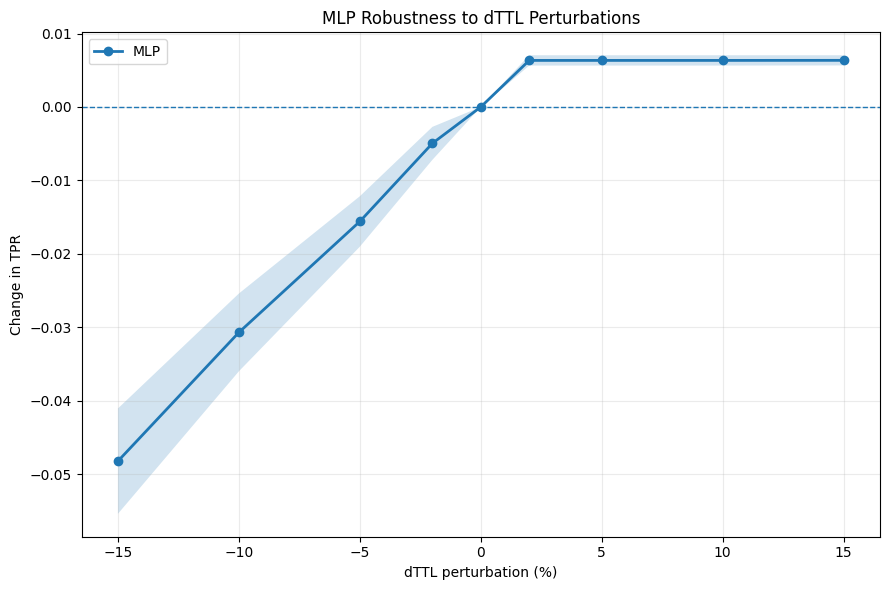

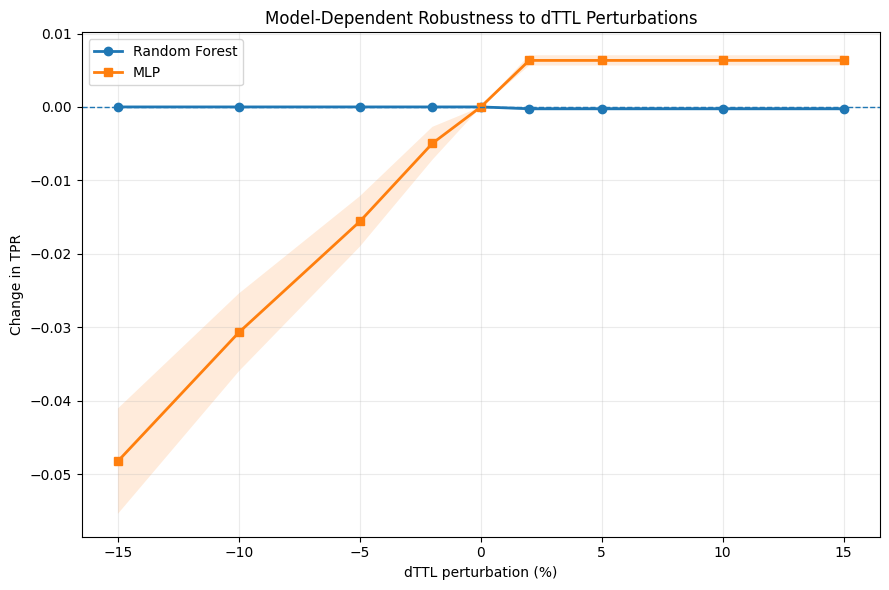

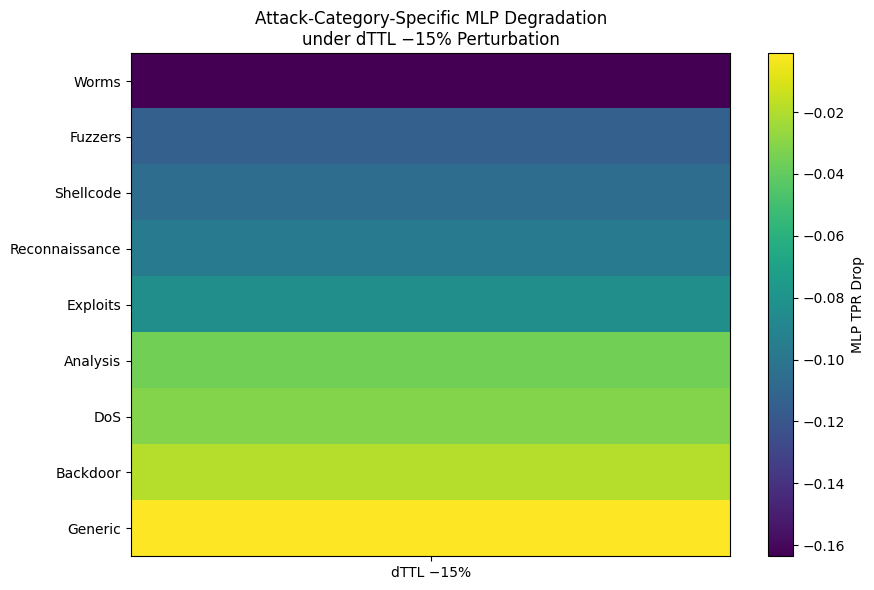

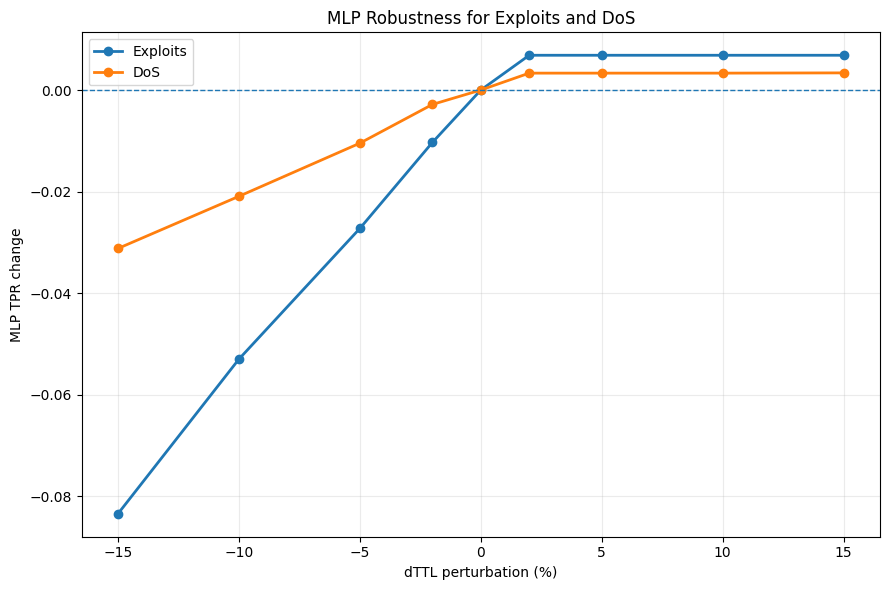



KEY PREPRINT RESULTS
Worms              | MLP ΔTPR = -0.1636 ± 0.0651
Shellcode          | MLP ΔTPR = -0.1053 ± 0.0208
Fuzzers            | MLP ΔTPR = -0.1138 ± 0.0197
Reconnaissance     | MLP ΔTPR = -0.0975 ± 0.0113
Exploits           | MLP ΔTPR = -0.0835 ± 0.0153
DoS                | MLP ΔTPR = -0.0312 ± 0.0089
Generic            | MLP ΔTPR = -0.0009 ± 0.0036


FILES CREATED

fig1_mlp_dttl_robustness.png
fig2_rf_vs_mlp_dttl.png
fig3_dttl_attack_category_heatmap.png
fig4_exploits_dos_dttl.png

table_dttl_overall_robustness.csv
table_dttl_attack_category.csv

VISUALIZATION COMPLETE


In [31]:
# ================================================================
# VISUALIZATION — TTL ROBUSTNESS RESULTS FOR PREPRINT
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("PREPRINT VISUALIZATION — TTL ROBUSTNESS")
print("=" * 80)


# ================================================================
# 1. LOAD RESULTS
# ================================================================

summary_file = "ttl_multiseed_mean_sd.csv"
category_file = "ttl_attack_category_mean_sd_ci.csv"

summary = pd.read_csv(summary_file)
category = pd.read_csv(category_file)

print("\nLoaded:")
print(summary_file)
print(category_file)


# ================================================================
# 2. HELPER
# ================================================================

def sort_perturbations(df):

    return df.sort_values(
        "Perturbation (%)"
    ).reset_index(drop=True)


# ================================================================
# 3. FIGURE 1
# OVERALL MLP ROBUSTNESS — dttl
# ================================================================

dttl = summary[
    summary["TTL Feature"] == "dttl"
].copy()

dttl = sort_perturbations(dttl)

x = dttl["Perturbation (%)"].to_numpy()

mlp_mean = dttl[
    "MLP TPR Drop Mean"
].to_numpy()

mlp_sd = dttl[
    "MLP TPR Drop SD"
].to_numpy()

plt.figure(figsize=(9, 6))

plt.plot(
    x,
    mlp_mean,
    marker="o",
    linewidth=2,
    label="MLP"
)

plt.fill_between(
    x,
    mlp_mean - mlp_sd,
    mlp_mean + mlp_sd,
    alpha=0.20
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "dTTL perturbation (%)"
)

plt.ylabel(
    "Change in TPR"
)

plt.title(
    "MLP Robustness to dTTL Perturbations"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fig1_mlp_dttl_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 4. FIGURE 2
# RF VS MLP — dttl
# ================================================================

rf_mean = dttl[
    "RF TPR Drop Mean"
].to_numpy()

rf_sd = dttl[
    "RF TPR Drop SD"
].to_numpy()

plt.figure(figsize=(9, 6))

plt.plot(
    x,
    rf_mean,
    marker="o",
    linewidth=2,
    label="Random Forest"
)

plt.fill_between(
    x,
    rf_mean - rf_sd,
    rf_mean + rf_sd,
    alpha=0.15
)

plt.plot(
    x,
    mlp_mean,
    marker="s",
    linewidth=2,
    label="MLP"
)

plt.fill_between(
    x,
    mlp_mean - mlp_sd,
    mlp_mean + mlp_sd,
    alpha=0.15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "dTTL perturbation (%)"
)

plt.ylabel(
    "Change in TPR"
)

plt.title(
    "Model-Dependent Robustness to dTTL Perturbations"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fig2_rf_vs_mlp_dttl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 5. FIGURE 3
# ATTACK-CATEGORY HEATMAP
# dttl at -15%
# ================================================================

cat15 = category[
    (category["TTL Feature"] == "dttl")
    &
    (category["Perturbation (%)"] == -15)
].copy()

heatmap_data = cat15.set_index(
    "Attack Category"
)[
    "MLP TPR Drop"
]

# Sort by degradation
heatmap_data = heatmap_data.sort_values()

plt.figure(
    figsize=(9, 6)
)

values = heatmap_data.to_numpy()

plt.imshow(
    values.reshape(-1, 1),
    aspect="auto"
)

plt.colorbar(
    label="MLP TPR Drop"
)

plt.yticks(
    np.arange(len(heatmap_data)),
    heatmap_data.index
)

plt.xticks(
    [0],
    ["dTTL −15%"]
)

plt.title(
    "Attack-Category-Specific MLP Degradation\n"
    "under dTTL −15% Perturbation"
)

plt.tight_layout()

plt.savefig(
    "fig3_dttl_attack_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 6. FIGURE 4
# EXPLOITS + DOS
# ================================================================

important_categories = [
    "Exploits",
    "DoS"
]

important = category[
    (category["TTL Feature"] == "dttl")
    &
    (
        category["Attack Category"]
        .isin(important_categories)
    )
].copy()

important = important.sort_values(
    [
        "Attack Category",
        "Perturbation (%)"
    ]
)

plt.figure(
    figsize=(9, 6)
)

for attack_type in important_categories:

    subset = important[
        important["Attack Category"]
        == attack_type
    ]

    plt.plot(
        subset["Perturbation (%)"],
        subset["MLP TPR Drop"],
        marker="o",
        linewidth=2,
        label=attack_type
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "dTTL perturbation (%)"
)

plt.ylabel(
    "MLP TPR change"
)

plt.title(
    "MLP Robustness for Exploits and DoS"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fig4_exploits_dos_dttl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 7. CREATE PUBLICATION SUMMARY TABLE
# ================================================================

publication_table = dttl[
    [
        "Perturbation (%)",

        "RF TPR Mean",
        "RF TPR SD",
        "RF TPR Drop Mean",
        "RF TPR Drop SD",

        "MLP TPR Mean",
        "MLP TPR SD",
        "MLP TPR Drop Mean",
        "MLP TPR Drop SD"
    ]
].copy()

publication_table = publication_table.round(6)

publication_table.to_csv(
    "table_dttl_overall_robustness.csv",
    index=False
)


# ================================================================
# 8. CATEGORY TABLE FOR PAPER
# ================================================================

category_paper = category[
    category["TTL Feature"] == "dttl"
].copy()

category_paper = category_paper[
    [
        "Perturbation (%)",
        "Attack Category",
        "Samples",

        "RF TPR",
        "RF TPR Drop",

        "MLP TPR",
        "MLP TPR Drop",

        "MLP TPR Drop SD",
        "MLP TPR Drop CI Low",
        "MLP TPR Drop CI High"
    ]
].sort_values(
    [
        "Perturbation (%)",
        "Attack Category"
    ]
)

category_paper.to_csv(
    "table_dttl_attack_category.csv",
    index=False
)


# ================================================================
# 9. PRINT KEY NUMBERS
# ================================================================

print("\n")
print("=" * 90)
print("KEY PREPRINT RESULTS")
print("=" * 90)

for attack_type in [
    "Worms",
    "Shellcode",
    "Fuzzers",
    "Reconnaissance",
    "Exploits",
    "DoS",
    "Generic"
]:

    row = category[
        (category["TTL Feature"] == "dttl")
        &
        (category["Perturbation (%)"] == -15)
        &
        (category["Attack Category"] == attack_type)
    ]

    if len(row) == 0:
        continue

    row = row.iloc[0]

    print(
        f"{attack_type:18s} | "
        f"MLP ΔTPR = "
        f"{row['MLP TPR Drop']:.4f} "
        f"± {row['MLP TPR Drop SD']:.4f}"
    )


print("\n")
print("=" * 90)
print("FILES CREATED")
print("=" * 90)

print("""
fig1_mlp_dttl_robustness.png
fig2_rf_vs_mlp_dttl.png
fig3_dttl_attack_category_heatmap.png
fig4_exploits_dos_dttl.png

table_dttl_overall_robustness.csv
table_dttl_attack_category.csv
""")

print("=" * 90)
print("VISUALIZATION COMPLETE")
print("=" * 90)

MLP+DATA AUGMENTATION


In [32]:
print("=" * 70)
print("CHECKING AVAILABLE TEST VARIABLES")
print("=" * 70)

for name in [
    "X_test",
    "X_test_processed",
    "X_test_transformed",
    "X_test_tensor",
    "X_test_processed_tensor",
    "model",
    "model_aug"
]:
    if name in globals():
        obj = globals()[name]
        print(f"{name:28s} -> {type(obj)}", end="")
        
        try:
            print(f" | shape = {obj.shape}")
        except:
            print()

CHECKING AVAILABLE TEST VARIABLES
X_test                       -> <class 'pandas.core.frame.DataFrame'> | shape = (82332, 43)
X_test_processed             -> <class 'numpy.ndarray'> | shape = (82332, 195)
X_test_tensor                -> <class 'torch.Tensor'> | shape = torch.Size([82332, 195])
model                        -> <class '__main__.MLP'>


In [33]:
# ============================================================
# TTL AUGMENTATION-STRENGTH SWEEP
# MLP BASELINE vs TTL-AUGMENTED MLP
#

# UNSW-NB15
#
# IMPORTANT:
# - 0% augmentation = STANDARD CLEAN MLP
# - 50% of TRAINING samples are augmented
# - Both sttl and dttl are perturbed
# - Test set is NEVER augmented
# - Augmentation levels: ±2%, ±5%, ±10%, ±15%
# - Three independent seeds: 42, 123, 2026
# ============================================================

import numpy as np
import pandas as pd
import random

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. CONFIGURATION
# ============================================================

TARGET = "label"

DROP_COLS = [
    "label",
    "attack_cat"
]

# Three seeds used throughout the experiments
SEEDS = [42, 123, 2026]

# Augmentation strengths
AUGMENTATION_LEVELS = [
    0,
    2,
    5,
    10,
    15
]

# IMPORTANT:
# 50% of training samples are selected for augmentation
AUGMENTATION_FRACTION = 0.50

EPOCHS = 10
BATCH_SIZE = 512
LEARNING_RATE = 1e-3


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic behaviour where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 3. DATA
# ============================================================

feature_cols = [
    c for c in train_df.columns
    if c not in DROP_COLS
]

X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()

y_train = train_df[TARGET].astype(int).to_numpy()
y_test = test_df[TARGET].astype(int).to_numpy()


print("=" * 80)
print("TTL AUGMENTATION EXPERIMENT")
print("=" * 80)

print("Training samples :", len(X_train_raw))
print("Testing samples  :", len(X_test_raw))

print("\nAugmentation fraction:", AUGMENTATION_FRACTION)

print("Seeds:", SEEDS)

print("Augmentation levels:", AUGMENTATION_LEVELS)

print("\nTTL columns:")
print("sttl")
print("dttl")


# ============================================================
# 4. CHECK TTL FEATURES
# ============================================================

for col in ["sttl", "dttl"]:

    if col not in X_train_raw.columns:
        raise ValueError(
            f"Required TTL feature '{col}' was not found "
            f"in the training dataframe."
        )


# ============================================================
# 5. PREPROCESSING
# ============================================================

categorical_cols = X_train_raw.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train_raw.select_dtypes(
    include=[np.number]
).columns.tolist()


numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])


print("\nFitting preprocessing pipeline...")

X_train_processed = preprocessor.fit_transform(
    X_train_raw
)

X_test_processed = preprocessor.transform(
    X_test_raw
)


X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)


print("Processed train shape:", X_train_processed.shape)
print("Processed test shape :", X_test_processed.shape)


# ============================================================
# 6. FIND TTL COLUMN POSITIONS AFTER PREPROCESSING
# ============================================================
#
# sttl and dttl are numeric features.
# ColumnTransformer keeps numeric features first, so their
# positions are obtained from numeric_cols.
# ============================================================

sttl_idx = numeric_cols.index("sttl")
dttl_idx = numeric_cols.index("dttl")

print("\nProcessed TTL column positions:")
print("sttl index:", sttl_idx)
print("dttl index:", dttl_idx)


# ============================================================
# 7. MLP ARCHITECTURE
# ============================================================

class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ============================================================
# 8. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", device)


# ============================================================
# 9. TTL AUGMENTATION FUNCTION
# ============================================================
#
# EXACT EXPERIMENT:
#
# For each augmentation level:
#
#   ±2%
#   ±5%
#   ±10%
#   ±15%
#
# 50% of the TRAINING samples are selected.
#
# For the selected samples:
#
#   sttl = sttl * (1 + random perturbation)
#   dttl = dttl * (1 + random perturbation)
#
# where the perturbation is uniformly sampled between
# -level and +level.
#
# Example for ±10%:
#
#   multiplier ∈ [0.90, 1.10]
#
# The remaining 50% are unchanged.
#
# TEST DATA IS NEVER MODIFIED.
# ============================================================

def augment_ttl_features(
    X,
    strength_percent,
    fraction,
    seed,
    sttl_index,
    dttl_index
):

    X_aug = X.copy()

    # --------------------------------------------------------
    # 0% = completely clean training data
    # --------------------------------------------------------

    if strength_percent == 0:

        return X_aug


    rng = np.random.default_rng(seed)

    n_samples = len(X_aug)

    n_selected = int(
        np.floor(
            fraction * n_samples
        )
    )

    # --------------------------------------------------------
    # Select exactly 50% of training samples
    # --------------------------------------------------------

    selected_indices = rng.choice(
        n_samples,
        size=n_selected,
        replace=False
    )


    # --------------------------------------------------------
    # Random perturbation independently for each sample
    # and each TTL feature.
    #
    # Example:
    # strength = 10
    #
    # perturbation ∈ [-0.10, +0.10]
    # --------------------------------------------------------

    max_change = strength_percent / 100.0


    sttl_perturbation = rng.uniform(
        -max_change,
        max_change,
        size=n_selected
    )

    dttl_perturbation = rng.uniform(
        -max_change,
        max_change,
        size=n_selected
    )


    # --------------------------------------------------------
    # Apply multiplicative perturbations
    # --------------------------------------------------------

    X_aug[
        selected_indices,
        sttl_index
    ] *= (
        1.0 + sttl_perturbation
    )


    X_aug[
        selected_indices,
        dttl_index
    ] *= (
        1.0 + dttl_perturbation
    )


    return X_aug


# ============================================================
# 10. TRAIN + EVALUATE MLP
# ============================================================

def train_and_evaluate_mlp(
    X_train,
    y_train,
    X_test,
    y_test,
    seed
):

    set_seed(seed)

    # --------------------------------------------------------
    # Convert to tensors
    # --------------------------------------------------------

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.astype(np.float32),
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )


    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )


    # IMPORTANT:
    # DataLoader shuffle is seeded because set_seed(seed)
    # was called immediately before creating it.
    # --------------------------------------------------------

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0
    )


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = MLP(
        input_dim=X_train.shape[1]
    ).to(device)


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    criterion = nn.BCEWithLogitsLoss()


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    for epoch in range(EPOCHS):

        total_loss = 0.0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            logits = model(batch_X)

            loss = criterion(
                logits,
                batch_y
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                * len(batch_X)
            )


    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        logits = model(
            X_test_tensor.to(device)
        )

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy()


    predictions = (
        probabilities >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    tpr = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_test,
        probabilities
    )

    auprc = average_precision_score(
        y_test,
        probabilities
    )


    return tpr, auroc, auprc


# ============================================================
# 11. RUN AUGMENTATION SWEEP
# ============================================================

all_results = []


print("\n")
print("=" * 80)
print("STARTING 50% TTL AUGMENTATION SWEEP")
print("=" * 80)


for strength in AUGMENTATION_LEVELS:

    print("\n" + "-" * 80)

    if strength == 0:

        print(
            "0% AUGMENTATION "
            "(STANDARD CLEAN MLP)"
        )

    else:

        print(
            f"±{strength}% TTL AUGMENTATION "
            f"(50% TRAINING SAMPLES)"
        )


    print("-" * 80)


    for seed in SEEDS:

        print(
            f"\nSeed: {seed}"
        )


        # ----------------------------------------------------
        # Create augmented training data
        # ----------------------------------------------------

        X_train_augmented = augment_ttl_features(
            X=X_train_processed,
            strength_percent=strength,
            fraction=AUGMENTATION_FRACTION,
            seed=seed,
            sttl_index=sttl_idx,
            dttl_index=dttl_idx
        )


        # ----------------------------------------------------
        # IMPORTANT:
        # X_test_processed is passed unchanged.
        # ----------------------------------------------------

        tpr, auroc, auprc = train_and_evaluate_mlp(
            X_train=X_train_augmented,
            y_train=y_train,
            X_test=X_test_processed,
            y_test=y_test,
            seed=seed
        )


        print(
            f"TPR   : {tpr:.6f}"
        )

        print(
            f"AUROC : {auroc:.6f}"
        )

        print(
            f"AUPRC : {auprc:.6f}"
        )


        all_results.append({

            "Augmentation_%": strength,

            "Seed": seed,

            "TPR": tpr,

            "AUROC": auroc,

            "AUPRC": auprc
        })


# ============================================================
# 12. RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    all_results
)


# ============================================================
# 13. MEAN ± SD
# ============================================================

summary = (
    results_df
    .groupby("Augmentation_%")
    .agg(

        TPR_mean=(
            "TPR",
            "mean"
        ),

        TPR_SD=(
            "TPR",
            "std"
        ),

        AUROC_mean=(
            "AUROC",
            "mean"
        ),

        AUROC_SD=(
            "AUROC",
            "std"
        ),

        AUPRC_mean=(
            "AUPRC",
            "mean"
        ),

        AUPRC_SD=(
            "AUPRC",
            "std"
        )
    )
    .reset_index()
)


# ============================================================
# 14. PRINT FULL SEED RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("RESULTS FOR ALL THREE SEEDS")
print("=" * 100)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 15. PRINT PAPER-READY SUMMARY
# ============================================================

print("\n")
print("=" * 110)
print("TTL AUGMENTATION-STRENGTH SWEEP — MEAN ± SD")
print("=" * 110)

print(
    f"{'Augmentation':<15}"
    f"{'TPR':<25}"
    f"{'AUROC':<25}"
    f"{'AUPRC':<25}"
)

print("-" * 110)


for _, row in summary.iterrows():

    strength = int(
        row["Augmentation_%"]
    )

    if strength == 0:

        label = "0%"

    else:

        label = f"±{strength}%"


    tpr_string = (
        f"{row['TPR_mean']:.4f} ± "
        f"{row['TPR_SD']:.4f}"
    )

    auroc_string = (
        f"{row['AUROC_mean']:.4f} ± "
        f"{row['AUROC_SD']:.4f}"
    )

    auprc_string = (
        f"{row['AUPRC_mean']:.4f} ± "
        f"{row['AUPRC_SD']:.4f}"
    )


    print(
        f"{label:<15}"
        f"{tpr_string:<25}"
        f"{auroc_string:<25}"
        f"{auprc_string:<25}"
    )


# ============================================================
# 16. PAPER-READY TABLE 7
# ============================================================

paper_table = summary.copy()

paper_table["Augmentation"] = (
    paper_table["Augmentation_%"]
    .apply(
        lambda x:
        "0%"
        if x == 0
        else f"±{int(x)}%"
    )
)


paper_table = paper_table[
    [
        "Augmentation",
        "TPR_mean",
        "TPR_SD",
        "AUROC_mean",
        "AUROC_SD",
        "AUPRC_mean",
        "AUPRC_SD"
    ]
]


paper_table.columns = [

    "Augmentation",

    "TPR_mean",
    "TPR_SD",

    "AUROC_mean",
    "AUROC_SD",

    "AUPRC_mean",
    "AUPRC_SD"
]


print("\n")
print("=" * 100)
print("PAPER-READY TABLE")
print("=" * 100)

print(
    paper_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 17. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "TTL_augmentation_all_seeds.csv",
    index=False
)

paper_table.to_csv(
    "TTL_augmentation_summary.csv",
    index=False
)


print("\n")
print("=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "TTL_augmentation_all_seeds.csv"
)

print(
    "TTL_augmentation_summary.csv"
)


# ============================================================
# 18. IMPORTANT EXPERIMENT CHECKS
# ============================================================

print("\n")
print("=" * 80)
print("EXPERIMENT CHECKS")
print("=" * 80)

print(
    "✓ 0% augmentation = standard clean MLP"
)

print(
    "✓ 50% of training samples selected for augmentation"
)

print(
    "✓ Both sttl and dttl perturbed"
)

print(
    "✓ Augmentation applied ONLY to training data"
)

print(
    "✓ Test data remained completely unchanged"
)

print(
    "✓ Augmentation levels = ±2%, ±5%, ±10%, ±15%"
)

print(
    "✓ Seeds = 42, 123, 2026"
)

print(
    "✓ Results reported as mean ± SD"
)

print(
    "✓ attack_cat excluded to prevent label leakage"
)

TTL AUGMENTATION EXPERIMENT
Training samples : 175341
Testing samples  : 82332

Augmentation fraction: 0.5
Seeds: [42, 123, 2026]
Augmentation levels: [0, 2, 5, 10, 15]

TTL columns:
sttl
dttl

Fitting preprocessing pipeline...
Processed train shape: (175341, 195)
Processed test shape : (82332, 195)

Processed TTL column positions:
sttl index: 7
dttl index: 8

Device: cpu


STARTING 50% TTL AUGMENTATION SWEEP

--------------------------------------------------------------------------------
0% AUGMENTATION (STANDARD CLEAN MLP)
--------------------------------------------------------------------------------

Seed: 42
TPR   : 0.428152
AUROC : 0.674407
AUPRC : 0.757370

Seed: 123
TPR   : 0.409843
AUROC : 0.663296
AUPRC : 0.736383

Seed: 2026
TPR   : 0.428991
AUROC : 0.656070
AUPRC : 0.748163

--------------------------------------------------------------------------------
±2% TTL AUGMENTATION (50% TRAINING SAMPLES)
---------------------------------------------------------------------------

In [34]:
# ============================================================
# TTL AUGMENTATION ROBUSTNESS EXPERIMENT
# STANDARD MLP vs TTL-AUGMENTED MLP
#
# 50% OF TRAINING SAMPLES ARE AUGMENTED
# Seeds: 42, 123, 2026
# ============================================================

import numpy as np
import pandas as pd
import random

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEEDS = [42, 123, 2026]

# dTTL perturbations applied to TEST SET
DTTL_LEVELS = [-15, -10, -5, -2, 0, 2, 5, 10, 15]

# ------------------------------------------------------------
# IMPORTANT:
# 50% of training samples will be selected for augmentation
# ------------------------------------------------------------

AUGMENT_FRACTION = 0.50

# Strength of TTL augmentation during training.
#
# If your TTL-augmentation experiment is the ±15% experiment,
# keep this as 15.
#
# You can change to 2, 5, 10, or 15 for the augmentation sweep.
# ------------------------------------------------------------

AUGMENTATION_STRENGTH = 15

EPOCHS = 10
BATCH_SIZE = 512
LEARNING_RATE = 1e-3

TARGET = "label"

DROP_COLS = [
    "label",
    "attack_cat"
]


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Make CUDA operations as deterministic as possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 3. DATA
# ============================================================

feature_cols = [
    c for c in train_df.columns
    if c not in DROP_COLS
]

X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()

y_train = train_df[TARGET].astype(int).to_numpy()
y_test = test_df[TARGET].astype(int).to_numpy()


print("=" * 80)
print("TTL AUGMENTATION ROBUSTNESS EXPERIMENT")
print("=" * 80)

print("Training samples :", len(X_train_raw))
print("Testing samples  :", len(X_test_raw))
print("Features         :", len(feature_cols))

print("\nAugmentation fraction:", AUGMENT_FRACTION)
print("Augmentation strength:", f"±{AUGMENTATION_STRENGTH}%")

print("Seeds:", SEEDS)


# ============================================================
# 4. IDENTIFY FEATURE TYPES
# ============================================================

categorical_cols = X_train_raw.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train_raw.select_dtypes(
    include=[np.number]
).columns.tolist()


print("\nNumeric features    :", len(numeric_cols))
print("Categorical features:", len(categorical_cols))


# ============================================================
# 5. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])


print("\nFitting preprocessing pipeline...")

X_train_processed = preprocessor.fit_transform(
    X_train_raw
)

X_test_processed = preprocessor.transform(
    X_test_raw
)


X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)


print("Processed train shape:", X_train_processed.shape)
print("Processed test shape :", X_test_processed.shape)


# ============================================================
# 6. FIND sttl AND dttl COLUMNS
# ============================================================
#
# We need to perturb the ORIGINAL numeric TTL values before
# preprocessing.
#
# This avoids incorrectly perturbing the standardized values.
# ============================================================

if "sttl" not in X_train_raw.columns:
    raise ValueError(
        "sttl column was not found in train_df."
    )

if "dttl" not in X_train_raw.columns:
    raise ValueError(
        "dttl column was not found in train_df."
    )


# ============================================================
# 7. TEST-SET dTTL PERTURBATION
# ============================================================

def perturb_dttl_test(
    X_test_original,
    percentage
):
    """
    Apply a controlled multiplicative dTTL perturbation.

    Example:
        -15% -> dttl * 0.85
        -10% -> dttl * 0.90
         +10% -> dttl * 1.10
    """

    X = X_test_original.copy()

    factor = 1.0 + (
        percentage / 100.0
    )

    X["dttl"] = (
        X["dttl"] * factor
    )

    return X


# ============================================================
# 8. TTL TRAINING AUGMENTATION
# ============================================================

def create_ttl_augmented_training_data(
    X_original,
    y,
    seed,
    augmentation_strength,
    fraction=0.50
):
    """
    Select exactly `fraction` of training samples and perturb
    BOTH sttl and dttl.

    The remaining training samples remain unchanged.

    Example for ±15%:
        sttl -> multiplied by a random factor between 0.85 and 1.15
        dttl -> multiplied by a random factor between 0.85 and 1.15

    The selection and perturbations are deterministic for each seed.
    """

    rng = np.random.default_rng(seed)

    X_aug = X_original.copy()

    n_samples = len(X_aug)

    n_augmented = int(
        round(
            n_samples * fraction
        )
    )

    # Select 50% of samples
    selected_indices = rng.choice(
        n_samples,
        size=n_augmented,
        replace=False
    )

    # Random perturbation factors
    lower = 1.0 - (
        augmentation_strength / 100.0
    )

    upper = 1.0 + (
        augmentation_strength / 100.0
    )

    sttl_factors = rng.uniform(
        lower,
        upper,
        size=n_augmented
    )

    dttl_factors = rng.uniform(
        lower,
        upper,
        size=n_augmented
    )

    # Apply perturbation only to selected samples
    X_aug.loc[
        X_aug.index[selected_indices],
        "sttl"
    ] = (
        X_aug.loc[
            X_aug.index[selected_indices],
            "sttl"
        ].to_numpy()
        * sttl_factors
    )

    X_aug.loc[
        X_aug.index[selected_indices],
        "dttl"
    ] = (
        X_aug.loc[
            X_aug.index[selected_indices],
            "dttl"
        ].to_numpy()
        * dttl_factors
    )

    return X_aug


# ============================================================
# 9. MLP MODEL
# ============================================================

class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                1
            )
        )

    def forward(self, x):

        return self.network(
            x
        ).squeeze(1)


# ============================================================
# 10. TRAIN MLP
# ============================================================

def train_mlp(
    X,
    y,
    seed
):

    set_seed(seed)

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    X_np = np.asarray(
        X,
        dtype=np.float32
    )

    y_np = np.asarray(
        y,
        dtype=np.float32
    )

    X_tensor = torch.tensor(
        X_np,
        dtype=torch.float32
    )

    y_tensor = torch.tensor(
        y_np,
        dtype=torch.float32
    )

    dataset = TensorDataset(
        X_tensor,
        y_tensor
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed)
    )

    model = MLP(
        X_np.shape[1]
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    for epoch in range(EPOCHS):

        model.train()

        for batch_X, batch_y in loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            logits = model(
                batch_X
            )

            loss = criterion(
                logits,
                batch_y
            )

            loss.backward()

            optimizer.step()

    return model, device


# ============================================================
# 11. MODEL PREDICTION
# ============================================================

def predict_mlp(
    model,
    device,
    X
):

    model.eval()

    X_np = np.asarray(
        X,
        dtype=np.float32
    )

    X_tensor = torch.tensor(
        X_np,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        logits = model(
            X_tensor
        )

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy()

    return probabilities


# ============================================================
# 12. EVALUATION
# ============================================================

def calculate_metrics(
    y_true,
    probabilities
):

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    tpr = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    auroc = roc_auc_score(
        y_true,
        probabilities
    )

    auprc = average_precision_score(
        y_true,
        probabilities
    )

    return (
        tpr,
        auroc,
        auprc
    )


# ============================================================
# 13. STORAGE
# ============================================================

standard_records = []
augmented_records = []


# ============================================================
# 14. RUN EXPERIMENT FOR EACH SEED
# ============================================================

for seed in SEEDS:

    print("\n" + "=" * 80)
    print(f"SEED {seed}")
    print("=" * 80)


    # --------------------------------------------------------
    # STANDARD MLP
    # --------------------------------------------------------

    print("\nTraining STANDARD MLP...")

    standard_model, device = train_mlp(
        X_train_processed,
        y_train,
        seed
    )


    # --------------------------------------------------------
    # TTL-AUGMENTED TRAINING DATA
    # --------------------------------------------------------

    print(
        "\nCreating TTL-augmented training data..."
    )

    X_train_augmented_raw = (
        create_ttl_augmented_training_data(
            X_train_raw,
            y_train,
            seed=seed,
            augmentation_strength=AUGMENTATION_STRENGTH,
            fraction=AUGMENT_FRACTION
        )
    )


    n_augmented = int(
        round(
            len(X_train_raw)
            * AUGMENT_FRACTION
        )
    )

    print(
        f"Augmented samples: "
        f"{n_augmented} / {len(X_train_raw)} "
        f"({AUGMENT_FRACTION * 100:.0f}%)"
    )


    # --------------------------------------------------------
    # IMPORTANT:
    # Use the SAME preprocessing pipeline.
    #
    # The preprocessor is fitted ONLY on the original clean
    # training data, then applied to augmented training data.
    # --------------------------------------------------------

    X_train_augmented_processed = (
        preprocessor.transform(
            X_train_augmented_raw
        )
    )

    X_train_augmented_processed = np.asarray(
        X_train_augmented_processed,
        dtype=np.float32
    )


    # --------------------------------------------------------
    # TRAIN TTL-AUGMENTED MLP
    # --------------------------------------------------------

    print(
        "Training TTL-AUGMENTED MLP..."
    )

    augmented_model, augmented_device = train_mlp(
        X_train_augmented_processed,
        y_train,
        seed
    )


    # ========================================================
    # TEST AT EACH dTTL LEVEL
    # ========================================================

    for dttl_level in DTTL_LEVELS:

        # ----------------------------------------------------
        # Create perturbed TEST SET
        # ----------------------------------------------------

        X_test_perturbed_raw = (
            perturb_dttl_test(
                X_test_raw,
                dttl_level
            )
        )

        X_test_perturbed_processed = (
            preprocessor.transform(
                X_test_perturbed_raw
            )
        )

        X_test_perturbed_processed = np.asarray(
            X_test_perturbed_processed,
            dtype=np.float32
        )


        # ----------------------------------------------------
        # STANDARD MODEL
        # ----------------------------------------------------

        standard_prob = predict_mlp(
            standard_model,
            device,
            X_test_perturbed_processed
        )

        (
            standard_tpr,
            standard_auroc,
            standard_auprc
        ) = calculate_metrics(
            y_test,
            standard_prob
        )


        # ----------------------------------------------------
        # TTL-AUGMENTED MODEL
        # ----------------------------------------------------

        augmented_prob = predict_mlp(
            augmented_model,
            augmented_device,
            X_test_perturbed_processed
        )

        (
            augmented_tpr,
            augmented_auroc,
            augmented_auprc
        ) = calculate_metrics(
            y_test,
            augmented_prob
        )


        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        standard_records.append({

            "Seed": seed,
            "dTTL_%": dttl_level,

            "TPR": standard_tpr,
            "AUROC": standard_auroc,
            "AUPRC": standard_auprc
        })


        augmented_records.append({

            "Seed": seed,
            "dTTL_%": dttl_level,

            "TPR": augmented_tpr,
            "AUROC": augmented_auroc,
            "AUPRC": augmented_auprc
        })


# ============================================================
# 15. DATAFRAMES
# ============================================================

standard_df = pd.DataFrame(
    standard_records
)

augmented_df = pd.DataFrame(
    augmented_records
)


# ============================================================
# 16. MEAN ± SD ACROSS THREE SEEDS
# ============================================================

standard_summary = (
    standard_df
    .groupby("dTTL_%")
    .agg(
        TPR_mean=("TPR", "mean"),
        TPR_SD=("TPR", "std"),

        AUROC_mean=("AUROC", "mean"),
        AUROC_SD=("AUROC", "std"),

        AUPRC_mean=("AUPRC", "mean"),
        AUPRC_SD=("AUPRC", "std")
    )
    .reset_index()
)


augmented_summary = (
    augmented_df
    .groupby("dTTL_%")
    .agg(
        TPR_mean=("TPR", "mean"),
        TPR_SD=("TPR", "std"),

        AUROC_mean=("AUROC", "mean"),
        AUROC_SD=("AUROC", "std"),

        AUPRC_mean=("AUPRC", "mean"),
        AUPRC_SD=("AUPRC", "std")
    )
    .reset_index()
)


# ============================================================
# 17. OWN CLEAN BASELINES
# ============================================================

standard_clean_tpr = (
    standard_summary
    .loc[
        standard_summary["dTTL_%"] == 0,
        "TPR_mean"
    ]
    .iloc[0]
)

augmented_clean_tpr = (
    augmented_summary
    .loc[
        augmented_summary["dTTL_%"] == 0,
        "TPR_mean"
    ]
    .iloc[0]
)


# ============================================================
# 18. TPR DEGRADATION FROM EACH MODEL'S OWN CLEAN BASELINE
# ============================================================

standard_summary[
    "TPR_degradation"
] = (
    standard_clean_tpr
    - standard_summary["TPR_mean"]
)


augmented_summary[
    "TPR_degradation"
] = (
    augmented_clean_tpr
    - augmented_summary["TPR_mean"]
)


# ============================================================
# 19. FINAL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "dTTL_%":
        standard_summary["dTTL_%"],

    "Standard_MLP_TPR":
        standard_summary["TPR_mean"],

    "Standard_MLP_TPR_SD":
        standard_summary["TPR_SD"],

    "TTL_Augmented_MLP_TPR":
        augmented_summary["TPR_mean"],

    "TTL_Augmented_MLP_TPR_SD":
        augmented_summary["TPR_SD"],

    "Standard_AUROC":
        standard_summary["AUROC_mean"],

    "Standard_AUROC_SD":
        standard_summary["AUROC_SD"],

    "Augmented_AUROC":
        augmented_summary["AUROC_mean"],

    "Augmented_AUROC_SD":
        augmented_summary["AUROC_SD"],

    "Standard_TPR_Degradation":
        standard_summary["TPR_degradation"],

    "Augmented_TPR_Degradation":
        augmented_summary["TPR_degradation"]
})


# ============================================================
# 20. PRINT CLEAN BASELINES
# ============================================================

print("\n" + "=" * 100)
print("CLEAN BASELINES")
print("=" * 100)

print(
    f"Standard MLP clean TPR : "
    f"{standard_clean_tpr:.6f}"
)

print(
    f"TTL-Augmented clean TPR: "
    f"{augmented_clean_tpr:.6f}"
)


# ============================================================
# 21. PRINT PAPER-READY TABLE
# ============================================================

print("\n" + "=" * 100)
print("TABLE 8 — STANDARD AND TTL-AUGMENTED MLP")
print("UNDER dTTL PERTURBATIONS")
print("=" * 100)

print(
    "dTTL   "
    "Standard MLP TPR      "
    "TTL-Augmented MLP TPR      "
    "Standard AUROC      "
    "Augmented AUROC"
)

print("-" * 100)

for _, row in comparison.iterrows():

    print(
        f"{row['dTTL_%']:>+4.0f}%   "

        f"{row['Standard_MLP_TPR']:.4f} ± "
        f"{row['Standard_MLP_TPR_SD']:.4f}      "

        f"{row['TTL_Augmented_MLP_TPR']:.4f} ± "
        f"{row['TTL_Augmented_MLP_TPR_SD']:.4f}      "

        f"{row['Standard_AUROC']:.4f} ± "
        f"{row['Standard_AUROC_SD']:.4f}      "

        f"{row['Augmented_AUROC']:.4f} ± "
        f"{row['Augmented_AUROC_SD']:.4f}"
    )


# ============================================================
# 22. TPR DEGRADATION TABLE
# ============================================================

print("\n" + "=" * 100)
print("TPR DEGRADATION FROM EACH MODEL'S OWN CLEAN BASELINE")
print("=" * 100)

print(
    comparison[
        [
            "dTTL_%",
            "Standard_MLP_TPR",
            "Standard_TPR_Degradation",
            "TTL_Augmented_MLP_TPR",
            "Augmented_TPR_Degradation"
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 23. SAVE RESULTS
# ============================================================

standard_df.to_csv(
    "standard_mlp_dttl_results_50pct.csv",
    index=False
)

augmented_df.to_csv(
    "ttl_augmented_mlp_dttl_results_50pct.csv",
    index=False
)

comparison.to_csv(
    "table8_standard_vs_ttl_augmented_50pct.csv",
    index=False
)


print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print(
    "standard_mlp_dttl_results_50pct.csv"
)

print(
    "ttl_augmented_mlp_dttl_results_50pct.csv"
)

print(
    "table8_standard_vs_ttl_augmented_50pct.csv"
)

print("\nExperiment completed.")

TTL AUGMENTATION ROBUSTNESS EXPERIMENT
Training samples : 175341
Testing samples  : 82332
Features         : 43

Augmentation fraction: 0.5
Augmentation strength: ±15%
Seeds: [42, 123, 2026]

Numeric features    : 40
Categorical features: 3

Fitting preprocessing pipeline...
Processed train shape: (175341, 195)
Processed test shape : (82332, 195)

SEED 42

Training STANDARD MLP...

Creating TTL-augmented training data...
Augmented samples: 87670 / 175341 (50%)


/tmp/ipykernel_58/801009625.py:321: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[228.16014848 246.83777428 235.76118724 ... 245.9947687  238.30392167
  31.05251225]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_aug.loc[
/tmp/ipykernel_58/801009625.py:332: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[259.64933784   0.           0.         ... 224.252581     0.
  25.91669272]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_aug.loc[


Training TTL-AUGMENTED MLP...

SEED 123

Training STANDARD MLP...

Creating TTL-augmented training data...
Augmented samples: 87670 / 175341 (50%)


/tmp/ipykernel_58/801009625.py:321: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 30.99159065 278.45649673 231.11655421 ...  66.93157966 280.4013872
  32.92673126]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_aug.loc[
/tmp/ipykernel_58/801009625.py:332: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 27.48766992 282.16988481   0.         ... 214.5176194    0.
  27.42981689]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_aug.loc[


Training TTL-AUGMENTED MLP...

SEED 2026

Training STANDARD MLP...

Creating TTL-augmented training data...
Augmented samples: 87670 / 175341 (50%)


/tmp/ipykernel_58/801009625.py:321: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[234.04427719 242.25977351 234.14508902 ...  28.66136396  26.63566343
 279.09214699]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_aug.loc[
/tmp/ipykernel_58/801009625.py:332: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  0.         274.7127475  250.7663343  ...  28.43497228  25.00212527
   0.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_aug.loc[


Training TTL-AUGMENTED MLP...

CLEAN BASELINES
Standard MLP clean TPR : 0.421659
TTL-Augmented clean TPR: 0.425454

TABLE 8 — STANDARD AND TTL-AUGMENTED MLP
UNDER dTTL PERTURBATIONS
dTTL   Standard MLP TPR      TTL-Augmented MLP TPR      Standard AUROC      Augmented AUROC
----------------------------------------------------------------------------------------------------
 -15%   0.3836 ± 0.0172      0.4205 ± 0.0149      0.6459 ± 0.0078      0.5907 ± 0.0183
 -10%   0.3943 ± 0.0174      0.4221 ± 0.0151      0.6505 ± 0.0081      0.5917 ± 0.0183
  -5%   0.4074 ± 0.0179      0.4238 ± 0.0150      0.6554 ± 0.0084      0.5925 ± 0.0183
  -2%   0.4157 ± 0.0182      0.4247 ± 0.0152      0.6585 ± 0.0086      0.5930 ± 0.0184
  +0%   0.4217 ± 0.0181      0.4255 ± 0.0153      0.6606 ± 0.0087      0.5934 ± 0.0184
  +2%   0.4272 ± 0.0179      0.4262 ± 0.0153      0.6627 ± 0.0090      0.5937 ± 0.0184
  +5%   0.4355 ± 0.0169      0.4271 ± 0.0151      0.6659 ± 0.0094      0.5942 ± 0.0185
 +10%   0.4483 ±

In [35]:
# ============================================================
# REPRODUCIBLE MLP AUGMENTATION EXPERIMENT
# UNSW-NB15
#
# 0%       = STANDARD MLP (NO AUGMENTATION)
# ±2%      = TTL augmentation
# ±5%      = TTL augmentation
# ±10%     = TTL augmentation
# ±15%     = TTL augmentation
#
# Seeds: 42, 123, 2026
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEEDS = [42, 123, 2026]

AUGMENTATION_LEVELS = [
    0,
    2,
    5,
    10,
    15
]

TARGET = "label"

DROP_COLS = [
    "label",
    "attack_cat"
]

# TTL features
TTL_FEATURES = [
    "sttl",
    "dttl"
]


# ============================================================
# 2. GLOBAL DETERMINISTIC SETTINGS
# ============================================================

def set_seed(seed):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic CUDA behaviour
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 3. VERIFY DATA
# ============================================================

print("=" * 80)
print("DATA VERIFICATION")
print("=" * 80)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTarget distribution - TRAIN")
print(train_df[TARGET].value_counts())

print("\nTarget distribution - TEST")
print(test_df[TARGET].value_counts())

print("\nChecking TTL features...")

for feature in TTL_FEATURES:

    if feature in train_df.columns:
        print(f"✓ {feature} found")
    else:
        print(f"⚠ {feature} NOT FOUND")


# ============================================================
# 4. FEATURES
# ============================================================

feature_cols = [
    c for c in train_df.columns
    if c not in DROP_COLS
]

X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()

y_train = (
    train_df[TARGET]
    .astype(int)
    .to_numpy()
)

y_test = (
    test_df[TARGET]
    .astype(int)
    .to_numpy()
)


# ============================================================
# 5. IDENTIFY NUMERIC / CATEGORICAL FEATURES
# ============================================================

categorical_cols = X_train_raw.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train_raw.select_dtypes(
    include=[np.number]
).columns.tolist()

print("\nNumeric features    :", len(numeric_cols))
print("Categorical features:", len(categorical_cols))


# ============================================================
# 6. PREPROCESSOR
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])


print("\nFitting preprocessing pipeline...")

X_train_processed = preprocessor.fit_transform(
    X_train_raw
)

X_test_processed = preprocessor.transform(
    X_test_raw
)

X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)

print(
    "Processed train:",
    X_train_processed.shape
)

print(
    "Processed test :",
    X_test_processed.shape
)


# ============================================================
# 7. MLP ARCHITECTURE
# ============================================================

class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


# ============================================================
# 8. TTL AUGMENTATION
# ============================================================

def augment_ttl_features(
    X_original,
    feature_columns,
    augmentation_percent,
    seed
):
    """
    Create augmented training samples by applying
    controlled multiplicative perturbations to TTL features.

    For ±N%:
        lower = feature * (1 - N/100)
        upper = feature * (1 + N/100)

    The original samples are retained and augmented
    samples are appended.

    0% returns the original training data unchanged.
    """

    # --------------------------------------------------------
    # 0% = STANDARD MLP
    # --------------------------------------------------------

    if augmentation_percent == 0:

        return X_original.copy()


    rng = np.random.default_rng(seed)

    X_augmented = X_original.copy()

    # --------------------------------------------------------
    # Find TTL columns
    # --------------------------------------------------------

    ttl_indices = []

    for feature in TTL_FEATURES:

        if feature in feature_columns:

            idx = feature_columns.index(feature)

            ttl_indices.append(idx)


    if len(ttl_indices) == 0:

        raise ValueError(
            "Neither sttl nor dttl was found "
            "in the feature columns."
        )


    # --------------------------------------------------------
    # Create one perturbed copy
    # --------------------------------------------------------

    X_new = X_original.copy()

    low = 1.0 - augmentation_percent / 100.0
    high = 1.0 + augmentation_percent / 100.0

    for idx in ttl_indices:

        # Controlled random multiplicative perturbation
        scale = rng.uniform(
            low,
            high,
            size=X_original.shape[0]
        ).astype(np.float32)

        X_new[:, idx] = (
            X_original[:, idx] *
            scale
        )


    # --------------------------------------------------------
    # Append augmented data
    # --------------------------------------------------------

    X_augmented = np.vstack([
        X_original,
        X_new
    ])


    return X_augmented


# ============================================================
# 9. TRAIN MLP
# ============================================================

def train_mlp(
    X_train,
    y_train,
    seed,
    epochs=10,
    batch_size=512,
    learning_rate=1e-3
):

    # Set seed BEFORE model creation
    set_seed(seed)

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    # --------------------------------------------------------
    # Tensors
    # --------------------------------------------------------

    X_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_tensor = torch.tensor(
        y_train,
        dtype=torch.float32
    )


    dataset = TensorDataset(
        X_tensor,
        y_tensor
    )


    # --------------------------------------------------------
    # Deterministic DataLoader
    # --------------------------------------------------------

    generator = torch.Generator()

    generator.manual_seed(seed)


    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = MLP(
        input_dim=X_train.shape[1]
    ).to(device)


    criterion = nn.BCEWithLogitsLoss()


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for batch_X, batch_y in loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            logits = model(batch_X)

            loss = criterion(
                logits,
                batch_y
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                * len(batch_X)
            )


    return model, device


# ============================================================
# 10. EVALUATE MLP
# ============================================================

def evaluate_mlp(
    model,
    device,
    X_test,
    y_test
):

    model.eval()

    X_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)


    with torch.no_grad():

        logits = model(
            X_tensor
        )

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy()


    predictions = (
        probabilities >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    tpr = recall_score(
        y_test,
        predictions,
        zero_division=0
    )


    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )


    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    ).ravel()


    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )


    auroc = roc_auc_score(
        y_test,
        probabilities
    )


    auprc = average_precision_score(
        y_test,
        probabilities
    )


    return {
        "TPR": tpr,
        "FPR": fpr,
        "AUROC": auroc,
        "AUPRC": auprc
    }


# ============================================================
# 11. RUN AUGMENTATION EXPERIMENT
# ============================================================

all_results = []


print("\n")
print("=" * 80)
print("MLP AUGMENTATION EXPERIMENT")
print("=" * 80)

print(
    "Seeds:",
    SEEDS
)

print(
    "Augmentation levels:",
    AUGMENTATION_LEVELS
)


for augmentation in AUGMENTATION_LEVELS:

    print("\n")
    print("-" * 80)

    if augmentation == 0:

        print(
            "0% AUGMENTATION = STANDARD MLP"
        )

    else:

        print(
            f"±{augmentation}% TTL AUGMENTATION"
        )

    print("-" * 80)


    for seed in SEEDS:

        print(
            f"\nSeed {seed}"
        )


        # ----------------------------------------------------
        # Create training data
        # ----------------------------------------------------

        X_train_aug = augment_ttl_features(
            X_train_processed,
            feature_cols,
            augmentation,
            seed
        )


        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        if augmentation == 0:

            y_train_aug = y_train.copy()

        else:

            y_train_aug = np.concatenate([
                y_train,
                y_train
            ])


        print(
            "Training samples:",
            len(y_train_aug)
        )


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        model, device = train_mlp(
            X_train_aug,
            y_train_aug,
            seed=seed,
            epochs=10,
            batch_size=512,
            learning_rate=1e-3
        )


        # ----------------------------------------------------
        # Evaluate
        # ----------------------------------------------------

        metrics = evaluate_mlp(
            model,
            device,
            X_test_processed,
            y_test
        )


        print(
            f"TPR   : {metrics['TPR']:.6f}"
        )

        print(
            f"FPR   : {metrics['FPR']:.6f}"
        )

        print(
            f"AUROC : {metrics['AUROC']:.6f}"
        )

        print(
            f"AUPRC : {metrics['AUPRC']:.6f}"
        )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        all_results.append({

            "augmentation": augmentation,

            "seed": seed,

            "TPR": metrics["TPR"],

            "FPR": metrics["FPR"],

            "AUROC": metrics["AUROC"],

            "AUPRC": metrics["AUPRC"]
        })


# ============================================================
# 12. RAW RESULTS
# ============================================================

results_df = pd.DataFrame(
    all_results
)


print("\n")
print("=" * 80)
print("PER-SEED RESULTS")
print("=" * 80)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 13. MEAN ± SD
# ============================================================

summary = (
    results_df
    .groupby("augmentation")
    .agg(
        TPR_mean=("TPR", "mean"),
        TPR_SD=("TPR", "std"),

        FPR_mean=("FPR", "mean"),
        FPR_SD=("FPR", "std"),

        AUROC_mean=("AUROC", "mean"),
        AUROC_SD=("AUROC", "std"),

        AUPRC_mean=("AUPRC", "mean"),
        AUPRC_SD=("AUPRC", "std")
    )
    .reset_index()
)


# ============================================================
# 14. FORMAT AUGMENTATION LABEL
# ============================================================

def augmentation_label(x):

    if x == 0:
        return "0% (Standard MLP)"

    return f"±{int(x)}%"


summary.insert(
    0,
    "Augmentation",
    summary["augmentation"].apply(
        augmentation_label
    )
)

summary = summary.drop(
    columns=["augmentation"]
)


# ============================================================
# 15. PRINT FINAL TABLE
# ============================================================

print("\n")
print("=" * 100)
print("TABLE 7 — MLP PERFORMANCE ACROSS AUGMENTATION LEVELS")
print("=" * 100)

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 16. PAPER-READY TABLE
# ============================================================

paper_table = summary.copy()

paper_table["TPR"] = (
    paper_table["TPR_mean"].map(lambda x: f"{x:.4f}")
    + " ± "
    + paper_table["TPR_SD"].map(lambda x: f"{x:.4f}")
)

paper_table["FPR"] = (
    paper_table["FPR_mean"].map(lambda x: f"{x:.4f}")
    + " ± "
    + paper_table["FPR_SD"].map(lambda x: f"{x:.4f}")
)

paper_table["AUROC"] = (
    paper_table["AUROC_mean"].map(lambda x: f"{x:.4f}")
    + " ± "
    + paper_table["AUROC_SD"].map(lambda x: f"{x:.4f}")
)

paper_table["AUPRC"] = (
    paper_table["AUPRC_mean"].map(lambda x: f"{x:.4f}")
    + " ± "
    + paper_table["AUPRC_SD"].map(lambda x: f"{x:.4f}")
)


paper_table = paper_table[
    [
        "Augmentation",
        "TPR",
        "FPR",
        "AUROC",
        "AUPRC"
    ]
]


print("\n")
print("=" * 100)
print("PAPER-READY TABLE 7")
print("=" * 100)

print(
    paper_table.to_string(
        index=False
    )
)


# ============================================================
# 17. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "MLP_augmentation_per_seed_results.csv",
    index=False
)

summary.to_csv(
    "MLP_augmentation_summary.csv",
    index=False
)

paper_table.to_csv(
    "Table_7_MLP_Augmentation.csv",
    index=False
)


print("\nSaved:")
print("✓ MLP_augmentation_per_seed_results.csv")
print("✓ MLP_augmentation_summary.csv")
print("✓ Table_7_MLP_Augmentation.csv")


# ============================================================
# 18. CLEAN STANDARD MLP RESULT
# ============================================================

standard_results = results_df[
    results_df["augmentation"] == 0
].copy()


print("\n")
print("=" * 80)
print("STANDARD MLP — 0% AUGMENTATION")
print("=" * 80)

print(
    standard_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print("\nSTANDARD MLP MEAN ± SD")

for metric in [
    "TPR",
    "FPR",
    "AUROC",
    "AUPRC"
]:

    mean = standard_results[
        metric
    ].mean()

    sd = standard_results[
        metric
    ].std()

    print(
        f"{metric:6s}: "
        f"{mean:.6f} ± {sd:.6f}"
    )

DATA VERIFICATION
Train shape: (175341, 45)
Test shape : (82332, 45)

Target distribution - TRAIN
label
1    119341
0     56000
Name: count, dtype: int64

Target distribution - TEST
label
1    45332
0    37000
Name: count, dtype: int64

Checking TTL features...
✓ sttl found
✓ dttl found

Numeric features    : 40
Categorical features: 3

Fitting preprocessing pipeline...
Processed train: (175341, 195)
Processed test : (82332, 195)


MLP AUGMENTATION EXPERIMENT
Seeds: [42, 123, 2026]
Augmentation levels: [0, 2, 5, 10, 15]


--------------------------------------------------------------------------------
0% AUGMENTATION = STANDARD MLP
--------------------------------------------------------------------------------

Seed 42
Training samples: 175341
TPR   : 0.435211
FPR   : 0.316324
AUROC : 0.667768
AUPRC : 0.751133

Seed 123
Training samples: 175341
TPR   : 0.401107
FPR   : 0.278459
AUROC : 0.663162
AUPRC : 0.744493

Seed 2026
Training samples: 175341
TPR   : 0.428660
FPR   : 0.255081
AURO

In [36]:
# ============================================================
# TABLE 8
# STANDARD MLP vs TTL-AUGMENTED MLP
# UNDER dTTL PERTURBATIONS
#
# Standard MLP:
#     0% training augmentation
#
# TTL-Augmented MLP:
#     ±AUGMENT_PCT training augmentation
#
# Test perturbations:
#     -15%, -10%, -5%, -2%, 0%, +2%, +5%, +10%, +15%
#
# Seeds:
#     42, 123, 2026
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)


# ============================================================
# 2. EXPERIMENT SETTINGS
# ============================================================

SEEDS = [42, 123, 2026]

# ------------------------------------------------------------
# IMPORTANT:
# Set this to the augmentation level used for your
# TTL-Augmented MLP.
#
# Example:
# 15 = ±15% TTL augmentation
# 10 = ±10% TTL augmentation
# 5  = ±5% TTL augmentation
# ------------------------------------------------------------

AUGMENT_PCT = 15


# dTTL test perturbation levels

DTTL_LEVELS = [
    -15,
    -10,
    -5,
    -2,
    0,
    2,
    5,
    10,
    15
]


TARGET = "label"

DROP_COLS = [
    "label",
    "attack_cat"
]

TTL_FEATURES = [
    "sttl",
    "dttl"
]

DTTL_FEATURE = "dttl"


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

def set_seed(seed):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 4. VERIFY DATA
# ============================================================

print("=" * 80)
print("TABLE 8 — DATA CHECK")
print("=" * 80)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

if DTTL_FEATURE not in train_df.columns:

    raise ValueError(
        f"{DTTL_FEATURE} is not present in train_df."
    )

if DTTL_FEATURE not in test_df.columns:

    raise ValueError(
        f"{DTTL_FEATURE} is not present in test_df."
    )

print("\n✓ dTTL column found")


# ============================================================
# 5. RAW FEATURES
# ============================================================

feature_cols = [
    c for c in train_df.columns
    if c not in DROP_COLS
]


X_train_raw = train_df[
    feature_cols
].copy()


X_test_raw = test_df[
    feature_cols
].copy()


y_train = (
    train_df[TARGET]
    .astype(int)
    .to_numpy()
)


y_test = (
    test_df[TARGET]
    .astype(int)
    .to_numpy()
)


print(
    "\nNumber of features:",
    len(feature_cols)
)


# ============================================================
# 6. IDENTIFY FEATURE TYPES
# ============================================================

categorical_cols = X_train_raw.select_dtypes(
    include=["object", "category"]
).columns.tolist()


numeric_cols = X_train_raw.select_dtypes(
    include=[np.number]
).columns.tolist()


print(
    "Numeric features    :",
    len(numeric_cols)
)

print(
    "Categorical features:",
    len(categorical_cols)
)


# ============================================================
# 7. PREPROCESSING
#
# IMPORTANT:
# The preprocessor is fitted ONLY on the clean training data.
#
# It is then used for:
#   clean training data
#   augmented training data
#   clean test data
#   perturbed test data
#
# This prevents preprocessing leakage.
# ============================================================

numeric_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer([

    (
        "num",
        numeric_pipeline,
        numeric_cols
    ),

    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])


print("\nFitting preprocessing on CLEAN training data...")


X_train_clean_processed = (
    preprocessor.fit_transform(
        X_train_raw
    )
)


X_test_clean_processed = (
    preprocessor.transform(
        X_test_raw
    )
)


X_train_clean_processed = np.asarray(
    X_train_clean_processed,
    dtype=np.float32
)


X_test_clean_processed = np.asarray(
    X_test_clean_processed,
    dtype=np.float32
)


print(
    "Processed train:",
    X_train_clean_processed.shape
)

print(
    "Processed test :",
    X_test_clean_processed.shape
)


# ============================================================
# 8. MLP ARCHITECTURE
# ============================================================

class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                1
            )
        )


    def forward(self, x):

        return self.network(
            x
        ).squeeze(1)


# ============================================================
# 9. CREATE TTL-AUGMENTED TRAINING DATA
#
# Augmentation is performed on RAW feature values BEFORE
# preprocessing.
#
# Original samples are retained.
# Augmented samples are appended.
# ============================================================

def create_ttl_augmented_training_data(
    X_raw,
    y,
    augmentation_percent,
    seed
):

    # --------------------------------------------------------
    # 0% = STANDARD MLP
    # --------------------------------------------------------

    if augmentation_percent == 0:

        return (
            X_raw.copy(),
            y.copy()
        )


    X_original = X_raw.copy()


    # --------------------------------------------------------
    # Random generator
    # --------------------------------------------------------

    rng = np.random.default_rng(
        seed
    )


    # --------------------------------------------------------
    # Create augmented copy
    # --------------------------------------------------------

    X_aug = X_original.copy()


    # --------------------------------------------------------
    # Perturb TTL features
    #
    # Each sample receives a random scale between:
    #
    # 1 - p/100
    # and
    # 1 + p/100
    # --------------------------------------------------------

    for feature in TTL_FEATURES:

        if feature not in X_aug.columns:

            continue


        scale = rng.uniform(

            1.0 -
            augmentation_percent / 100.0,

            1.0 +
            augmentation_percent / 100.0,

            size=len(X_aug)
        )


        X_aug[feature] = (
            X_aug[feature].astype(float)
            * scale
        )


    # --------------------------------------------------------
    # Append original + augmented
    # --------------------------------------------------------

    X_combined = pd.concat(
        [
            X_original,
            X_aug
        ],
        axis=0,
        ignore_index=True
    )


    y_combined = np.concatenate(
        [
            y,
            y
        ]
    )


    return (
        X_combined,
        y_combined
    )


# ============================================================
# 10. TRAIN MLP
# ============================================================

def train_mlp(
    X,
    y,
    seed,
    epochs=10,
    batch_size=512,
    learning_rate=1e-3
):

    # --------------------------------------------------------
    # Set seed BEFORE model initialization
    # --------------------------------------------------------

    set_seed(seed)


    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )


    # --------------------------------------------------------
    # Tensors
    # --------------------------------------------------------

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    )


    y_tensor = torch.tensor(
        y,
        dtype=torch.float32
    )


    dataset = TensorDataset(
        X_tensor,
        y_tensor
    )


    # --------------------------------------------------------
    # Deterministic shuffle
    # --------------------------------------------------------

    generator = torch.Generator()

    generator.manual_seed(
        seed
    )


    loader = DataLoader(

        dataset,

        batch_size=batch_size,

        shuffle=True,

        generator=generator
    )


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = MLP(
        X.shape[1]
    ).to(device)


    criterion = nn.BCEWithLogitsLoss()


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()


    for epoch in range(
        epochs
    ):

        for batch_X, batch_y in loader:

            batch_X = batch_X.to(
                device
            )

            batch_y = batch_y.to(
                device
            )


            optimizer.zero_grad()


            logits = model(
                batch_X
            )


            loss = criterion(
                logits,
                batch_y
            )


            loss.backward()


            optimizer.step()


    return (
        model,
        device
    )


# ============================================================
# 11. APPLY dTTL PERTURBATION TO TEST DATA
#
# This modifies ONLY dTTL.
#
# Example:
#
# -15% → dttl × 0.85
# -10% → dttl × 0.90
#  -5% → dttl × 0.95
#   0% → dttl × 1.00
#  +5% → dttl × 1.05
# +15% → dttl × 1.15
# ============================================================

def perturb_dttl(
    X_raw,
    percentage
):

    X = X_raw.copy()


    multiplier = (
        1.0 +
        percentage / 100.0
    )


    X[DTTL_FEATURE] = (
        X[DTTL_FEATURE].astype(float)
        * multiplier
    )


    return X


# ============================================================
# 12. EVALUATE MODEL
# ============================================================

def evaluate_model(
    model,
    device,
    X_test_processed,
    y_test
):

    model.eval()


    X_tensor = torch.tensor(
        X_test_processed,
        dtype=torch.float32
    ).to(device)


    with torch.no_grad():

        logits = model(
            X_tensor
        )


        probabilities = (
            torch.sigmoid(
                logits
            )
            .cpu()
            .numpy()
        )


    predictions = (
        probabilities >= 0.5
    ).astype(int)


    tpr = recall_score(
        y_test,
        predictions,
        zero_division=0
    )


    auroc = roc_auc_score(
        y_test,
        probabilities
    )


    auprc = average_precision_score(
        y_test,
        probabilities
    )


    return {
        "TPR": tpr,
        "AUROC": auroc,
        "AUPRC": auprc
    }


# ============================================================
# 13. RESULTS STORAGE
# ============================================================

all_results = []


# ============================================================
# 14. MAIN EXPERIMENT
# ============================================================

print("\n")
print("=" * 80)
print("TABLE 8 EXPERIMENT")
print("=" * 80)

print(
    f"TTL augmentation level: ±{AUGMENT_PCT}%"
)

print(
    f"Seeds: {SEEDS}"
)

print(
    f"dTTL levels: {DTTL_LEVELS}"
)


for seed in SEEDS:

    print("\n")
    print("#" * 80)

    print(
        f"SEED {seed}"
    )

    print(
        "#" * 80
    )


    # ========================================================
    # A. STANDARD MLP
    #
    # 0% augmentation
    # ========================================================

    print(
        "\nTraining STANDARD MLP..."
    )


    X_standard_raw = X_train_raw.copy()

    y_standard = y_train.copy()


    X_standard_processed = (
        preprocessor.transform(
            X_standard_raw
        )
    )


    X_standard_processed = np.asarray(
        X_standard_processed,
        dtype=np.float32
    )


    standard_model, standard_device = (
        train_mlp(
            X_standard_processed,
            y_standard,
            seed=seed
        )
    )


    # ========================================================
    # B. TTL-AUGMENTED MLP
    # ========================================================

    print(
        f"Training TTL-AUGMENTED MLP "
        f"(±{AUGMENT_PCT}%)..."
    )


    (
        X_aug_raw,
        y_aug
    ) = create_ttl_augmented_training_data(

        X_train_raw,

        y_train,

        AUGMENT_PCT,

        seed
    )


    # IMPORTANT:
    # Transform using the SAME preprocessor
    # fitted on clean training data.

    X_aug_processed = (
        preprocessor.transform(
            X_aug_raw
        )
    )


    X_aug_processed = np.asarray(
        X_aug_processed,
        dtype=np.float32
    )


    augmented_model, augmented_device = (
        train_mlp(

            X_aug_processed,

            y_aug,

            seed=seed
        )
    )


    # ========================================================
    # C. EVALUATE BOTH MODELS UNDER EVERY dTTL LEVEL
    # ========================================================

    for dttl_level in DTTL_LEVELS:

        print(
            f"\nSeed {seed} | "
            f"dTTL {dttl_level:+d}%"
        )


        # ----------------------------------------------------
        # Create perturbed RAW test data
        # ----------------------------------------------------

        X_test_perturbed_raw = (
            perturb_dttl(
                X_test_raw,
                dttl_level
            )
        )


        # ----------------------------------------------------
        # Transform using SAME preprocessor
        # ----------------------------------------------------

        X_test_perturbed_processed = (
            preprocessor.transform(
                X_test_perturbed_raw
            )
        )


        X_test_perturbed_processed = (
            np.asarray(
                X_test_perturbed_processed,
                dtype=np.float32
            )
        )


        # ----------------------------------------------------
        # STANDARD MLP
        # ----------------------------------------------------

        standard_metrics = evaluate_model(

            standard_model,

            standard_device,

            X_test_perturbed_processed,

            y_test
        )


        # ----------------------------------------------------
        # TTL-AUGMENTED MLP
        # ----------------------------------------------------

        augmented_metrics = evaluate_model(

            augmented_model,

            augmented_device,

            X_test_perturbed_processed,

            y_test
        )


        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        all_results.append({

            "Seed": seed,

            "dTTL_%": dttl_level,

            "Standard_TPR":
                standard_metrics["TPR"],

            "Standard_AUROC":
                standard_metrics["AUROC"],

            "Standard_AUPRC":
                standard_metrics["AUPRC"],

            "Augmented_TPR":
                augmented_metrics["TPR"],

            "Augmented_AUROC":
                augmented_metrics["AUROC"],

            "Augmented_AUPRC":
                augmented_metrics["AUPRC"]

        })


        print(
            f"  Standard  TPR={standard_metrics['TPR']:.6f} "
            f"AUROC={standard_metrics['AUROC']:.6f}"
        )

        print(
            f"  Augmented TPR={augmented_metrics['TPR']:.6f} "
            f"AUROC={augmented_metrics['AUROC']:.6f}"
        )


# ============================================================
# 15. RAW PER-SEED RESULTS
# ============================================================

results_df = pd.DataFrame(
    all_results
)


print("\n")
print("=" * 100)
print("PER-SEED RESULTS")
print("=" * 100)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 16. MEAN AND SD ACROSS THE THREE SEEDS
# ============================================================

summary = (

    results_df

    .groupby("dTTL_%")

    .agg(

        Standard_TPR_mean=(
            "Standard_TPR",
            "mean"
        ),

        Standard_TPR_SD=(
            "Standard_TPR",
            "std"
        ),

        Augmented_TPR_mean=(
            "Augmented_TPR",
            "mean"
        ),

        Augmented_TPR_SD=(
            "Augmented_TPR",
            "std"
        ),

        Standard_AUROC_mean=(
            "Standard_AUROC",
            "mean"
        ),

        Standard_AUROC_SD=(
            "Standard_AUROC",
            "std"
        ),

        Augmented_AUROC_mean=(
            "Augmented_AUROC",
            "mean"
        ),

        Augmented_AUROC_SD=(
            "Augmented_AUROC",
            "std"
        ),

        Standard_AUPRC_mean=(
            "Standard_AUPRC",
            "mean"
        ),

        Standard_AUPRC_SD=(
            "Standard_AUPRC",
            "std"
        ),

        Augmented_AUPRC_mean=(
            "Augmented_AUPRC",
            "mean"
        ),

        Augmented_AUPRC_SD=(
            "Augmented_AUPRC",
            "std"
        )

    )

    .reset_index()
)


# ============================================================
# 17. PAPER-READY TABLE 8
# ============================================================

table8 = pd.DataFrame({

    "dTTL":

        summary["dTTL_%"].map(
            lambda x: f"{x:+d}%"
        ),


    "Standard MLP TPR":

        summary.apply(

            lambda r:
            f"{r['Standard_TPR_mean']:.4f} ± "
            f"{r['Standard_TPR_SD']:.4f}",

            axis=1
        ),


    "TTL-Augmented MLP TPR":

        summary.apply(

            lambda r:
            f"{r['Augmented_TPR_mean']:.4f} ± "
            f"{r['Augmented_TPR_SD']:.4f}",

            axis=1
        ),


    "Standard AUROC":

        summary.apply(

            lambda r:
            f"{r['Standard_AUROC_mean']:.4f} ± "
            f"{r['Standard_AUROC_SD']:.4f}",

            axis=1
        ),


    "Augmented AUROC":

        summary.apply(

            lambda r:
            f"{r['Augmented_AUROC_mean']:.4f} ± "
            f"{r['Augmented_AUROC_SD']:.4f}",

            axis=1
        )

})


# ============================================================
# 18. PRINT FINAL TABLE
# ============================================================

print("\n")
print("=" * 120)
print("TABLE 8 — STANDARD AND TTL-AUGMENTED MLP")
print("UNDER dTTL PERTURBATIONS")
print("=" * 120)

print(
    table8.to_string(
        index=False
    )
)


# ============================================================
# 19. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "Table8_per_seed_results.csv",
    index=False
)


summary.to_csv(
    "Table8_mean_SD_results.csv",
    index=False
)


table8.to_csv(
    "Table8_paper_ready.csv",
    index=False
)


print("\n")
print("=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "✓ Table8_per_seed_results.csv"
)

print(
    "✓ Table8_mean_SD_results.csv"
)

print(
    "✓ Table8_paper_ready.csv"
)


# ============================================================
# 20. CHECK THE 0% dTTL STANDARD BASELINE
# ============================================================

baseline_0 = summary[
    summary["dTTL_%"] == 0
]


print("\n")
print("=" * 80)
print("0% dTTL — STANDARD MLP CHECK")
print("=" * 80)


if len(baseline_0) == 1:

    row = baseline_0.iloc[0]

    print(
        f"Standard MLP TPR   : "
        f"{row['Standard_TPR_mean']:.6f} "
        f"± {row['Standard_TPR_SD']:.6f}"
    )

    print(
        f"Standard MLP AUROC : "
        f"{row['Standard_AUROC_mean']:.6f} "
        f"± {row['Standard_AUROC_SD']:.6f}"
    )

    print(
        f"Standard MLP AUPRC : "
        f"{row['Standard_AUPRC_mean']:.6f} "
        f"± {row['Standard_AUPRC_SD']:.6f}"
    )


# ============================================================
# 21. ROBUSTNESS DEGRADATION FROM OWN CLEAN BASELINE
#
# This is useful for the Discussion and for your mentor's
# requirement that robustness must NOT be confused with
# clean predictive performance.
# ============================================================

clean_standard_tpr = (
    summary.loc[
        summary["dTTL_%"] == 0,
        "Standard_TPR_mean"
    ].iloc[0]
)


clean_augmented_tpr = (
    summary.loc[
        summary["dTTL_%"] == 0,
        "Augmented_TPR_mean"
    ].iloc[0]
)


summary["Standard_TPR_Degradation"] = (
    clean_standard_tpr
    - summary["Standard_TPR_mean"]
)


summary["Augmented_TPR_Degradation"] = (
    clean_augmented_tpr
    - summary["Augmented_TPR_mean"]
)


print("\n")
print("=" * 100)
print("TPR DEGRADATION FROM EACH MODEL'S OWN CLEAN BASELINE")
print("=" * 100)

print(
    summary[
        [
            "dTTL_%",
            "Standard_TPR_mean",
            "Standard_TPR_Degradation",
            "Augmented_TPR_mean",
            "Augmented_TPR_Degradation"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 22. FINAL NOTE
# ============================================================

print("\n")
print("=" * 80)
print("EXPERIMENT COMPLETE")
print("=" * 80)

print(
    f"Standard MLP = 0% training augmentation"
)

print(
    f"TTL-Augmented MLP = ±{AUGMENT_PCT}% training augmentation"
)

print(
    "All results averaged over seeds:",
    SEEDS
)

print(
    "Test perturbations:",
    DTTL_LEVELS
)

TABLE 8 — DATA CHECK
Train shape: (175341, 45)
Test shape : (82332, 45)

✓ dTTL column found

Number of features: 43
Numeric features    : 40
Categorical features: 3

Fitting preprocessing on CLEAN training data...
Processed train: (175341, 195)
Processed test : (82332, 195)


TABLE 8 EXPERIMENT
TTL augmentation level: ±15%
Seeds: [42, 123, 2026]
dTTL levels: [-15, -10, -5, -2, 0, 2, 5, 10, 15]


################################################################################
SEED 42
################################################################################

Training STANDARD MLP...
Training TTL-AUGMENTED MLP (±15%)...

Seed 42 | dTTL -15%
  Standard  TPR=0.393938 AUROC=0.653155
  Augmented TPR=0.433116 AUROC=0.577098

Seed 42 | dTTL -10%
  Standard  TPR=0.405188 AUROC=0.657880
  Augmented TPR=0.434219 AUROC=0.577688

Seed 42 | dTTL -5%
  Standard  TPR=0.420034 AUROC=0.662741
  Augmented TPR=0.435300 AUROC=0.578230

Seed 42 | dTTL -2%
  Standard  TPR=0.428836 AUROC=0.665736
  Aug

In [37]:
# ================================================================
# SCARF — PILOT IMPLEMENTATION
# ================================================================

import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset


print("=" * 80)
print("SCARF PILOT — CONTRASTIVE REPRESENTATION LEARNING")
print("=" * 80)


# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

SEED = 42

def set_seed_scarf(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed_scarf(SEED)


# ================================================================
# 2. DEVICE
# ================================================================

device_scarf = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device_scarf)


# ================================================================
# 3. PREPARE DATA
# ================================================================

TARGET = "label"
CATEGORY = "attack_cat"

X_train_raw_s = train_df.drop(
    columns=[TARGET, CATEGORY],
    errors="ignore"
).copy()

X_test_raw_s = test_df.drop(
    columns=[TARGET, CATEGORY],
    errors="ignore"
).copy()

y_train_s = (
    train_df[TARGET]
    .astype(int)
    .to_numpy()
)

y_test_s = (
    test_df[TARGET]
    .astype(int)
    .to_numpy()
)


# ================================================================
# 4. SAME FITTED PREPROCESSOR
# ================================================================

X_train_s = preprocessor.transform(
    X_train_raw_s
)

X_test_s = preprocessor.transform(
    X_test_raw_s
)

# Convert sparse matrix if necessary
if hasattr(X_train_s, "toarray"):
    X_train_s = X_train_s.toarray()

if hasattr(X_test_s, "toarray"):
    X_test_s = X_test_s.toarray()


X_train_s = np.asarray(
    X_train_s,
    dtype=np.float32
)

X_test_s = np.asarray(
    X_test_s,
    dtype=np.float32
)


print(
    "Training shape:",
    X_train_s.shape
)

print(
    "Test shape:",
    X_test_s.shape
)


# ================================================================
# 5. SCARF PARAMETERS
# ================================================================

INPUT_DIM = X_train_s.shape[1]

EMBED_DIM = 64

HIDDEN_DIM = 128

CORRUPTION_RATE = 0.30

TEMPERATURE = 0.20

CONTRASTIVE_EPOCHS = 10

FINETUNE_EPOCHS = 10

BATCH_SIZE = 2048

LEARNING_RATE = 1e-3


print("\nSCARF configuration:")
print("Input dimension:", INPUT_DIM)
print("Embedding dimension:", EMBED_DIM)
print("Corruption rate:", CORRUPTION_RATE)
print("Temperature:", TEMPERATURE)


# ================================================================
# 6. SCARF ENCODER
# ================================================================

class SCARFEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=128,
        embed_dim=64
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                embed_dim
            )
        )

    def forward(self, x):

        z = self.network(x)

        # Normalize representation
        z = F.normalize(
            z,
            dim=1
        )

        return z


# ================================================================
# 7. SCARF FEATURE CORRUPTION
# ================================================================

def scarf_corrupt_batch(
    x,
    corruption_rate
):

    """
    SCARF-style random feature corruption.

    Each sample receives a corrupted view where a subset
    of feature values is replaced using values drawn from
    other samples in the batch.

    This corruption is used ONLY for representation learning.
    It is NOT the TTL robustness transformation.
    """

    batch_size, num_features = x.shape

    corrupted = x.clone()

    mask = (
        torch.rand_like(x)
        < corruption_rate
    )

    # Random donor rows
    donor_indices = torch.randperm(
        batch_size,
        device=x.device
    )

    donor_values = x[
        donor_indices
    ]

    corrupted[mask] = donor_values[mask]

    return corrupted


# ================================================================
# 8. CONTRASTIVE LOSS
# ================================================================

def scarf_contrastive_loss(
    z1,
    z2,
    temperature=0.20
):

    """
    NT-Xent / InfoNCE-style loss.

    Positive pair:
        original sample ↔ corrupted view

    Negatives:
        other samples in the batch
    """

    similarity = torch.matmul(
        z1,
        z2.T
    ) / temperature

    labels = torch.arange(
        z1.size(0),
        device=z1.device
    )

    loss_12 = F.cross_entropy(
        similarity,
        labels
    )

    loss_21 = F.cross_entropy(
        similarity.T,
        labels
    )

    return (
        loss_12 + loss_21
    ) / 2


# ================================================================
# 9. CREATE ENCODER
# ================================================================

encoder_scarf = SCARFEncoder(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    embed_dim=EMBED_DIM
).to(device_scarf)


# ================================================================
# 10. CONTRASTIVE PRETRAINING
# ================================================================

train_tensor_s = torch.tensor(
    X_train_s,
    dtype=torch.float32
)

contrastive_loader = DataLoader(
    TensorDataset(train_tensor_s),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)


optimizer_scarf = torch.optim.Adam(
    encoder_scarf.parameters(),
    lr=LEARNING_RATE
)


print("\n")
print("=" * 80)
print("SCARF CONTRASTIVE PRETRAINING")
print("=" * 80)


encoder_scarf.train()

for epoch in range(
    CONTRASTIVE_EPOCHS
):

    total_loss = 0.0

    for (xb,) in contrastive_loader:

        xb = xb.to(
            device_scarf
        )

        # Original representation
        z1 = encoder_scarf(
            xb
        )

        # Corrupted representation
        xb_corrupted = scarf_corrupt_batch(
            xb,
            CORRUPTION_RATE
        )

        z2 = encoder_scarf(
            xb_corrupted
        )

        # Contrastive loss
        loss = scarf_contrastive_loss(
            z1,
            z2,
            TEMPERATURE
        )

        optimizer_scarf.zero_grad()

        loss.backward()

        optimizer_scarf.step()

        total_loss += loss.item()

    mean_loss = (
        total_loss /
        len(contrastive_loader)
    )

    print(
        f"Epoch {epoch + 1:02d}/"
        f"{CONTRASTIVE_EPOCHS} "
        f"| Contrastive Loss: "
        f"{mean_loss:.6f}"
    )


# ================================================================
# 11. CLASSIFICATION HEAD
# ================================================================

class SCARFClassifier(nn.Module):

    def __init__(
        self,
        encoder,
        embed_dim
    ):

        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Linear(
            embed_dim,
            1
        )

    def forward(self, x):

        z = self.encoder(x)

        return self.classifier(
            z
        ).squeeze(1)


scarf_model = SCARFClassifier(
    encoder_scarf,
    EMBED_DIM
).to(device_scarf)


# ================================================================
# 12. SUPERVISED FINE-TUNING
# ================================================================

y_tensor_s = torch.tensor(
    y_train_s,
    dtype=torch.float32
)

supervised_dataset = TensorDataset(
    train_tensor_s,
    y_tensor_s
)

supervised_loader = DataLoader(
    supervised_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# Class imbalance handling
positives = y_train_s.sum()
negatives = len(y_train_s) - positives

pos_weight = torch.tensor(
    [negatives / positives],
    dtype=torch.float32,
    device=device_scarf
)


criterion_scarf = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)


optimizer_finetune = torch.optim.Adam(
    scarf_model.parameters(),
    lr=LEARNING_RATE
)


print("\n")
print("=" * 80)
print("SCARF SUPERVISED FINE-TUNING")
print("=" * 80)


for epoch in range(
    FINETUNE_EPOCHS
):

    scarf_model.train()

    total_loss = 0.0

    for xb, yb in supervised_loader:

        xb = xb.to(
            device_scarf
        )

        yb = yb.to(
            device_scarf
        )

        logits = scarf_model(
            xb
        )

        loss = criterion_scarf(
            logits,
            yb
        )

        optimizer_finetune.zero_grad()

        loss.backward()

        optimizer_finetune.step()

        total_loss += loss.item()

    mean_loss = (
        total_loss /
        len(supervised_loader)
    )

    print(
        f"Epoch {epoch + 1:02d}/"
        f"{FINETUNE_EPOCHS} "
        f"| Classification Loss: "
        f"{mean_loss:.6f}"
    )


# ================================================================
# 13. EVALUATION
# ================================================================

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)


def evaluate_scarf(
    model,
    X,
    y
):

    model.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X,
            dtype=torch.float32,
            device=device_scarf
        )

        logits = model(
            X_tensor
        )

        probability = (
            torch.sigmoid(logits)
            .cpu()
            .numpy()
        )

    prediction = (
        probability >= 0.5
    ).astype(int)

    tpr = recall_score(
        y,
        prediction,
        zero_division=0
    )

    auroc = roc_auc_score(
        y,
        probability
    )

    auprc = average_precision_score(
        y,
        probability
    )

    return (
        tpr,
        auroc,
        auprc
    )


clean_tpr, clean_auc, clean_ap = (
    evaluate_scarf(
        scarf_model,
        X_test_s,
        y_test_s
    )
)


print("\n")
print("=" * 80)
print("SCARF CLEAN TEST PERFORMANCE")
print("=" * 80)

print(
    f"TPR   : {clean_tpr:.6f}"
)

print(
    f"AUROC : {clean_auc:.6f}"
)

print(
    f"AUPRC : {clean_ap:.6f}"
)


# ================================================================
# 14. dTTL ROBUSTNESS TEST
# ================================================================

print("\n")
print("=" * 80)
print("SCARF dTTL ROBUSTNESS TEST")
print("=" * 80)


dttl_results = []


for percent in [
    -15, -10, -5, -2,
     0,
     2, 5, 10, 15
]:

    if percent == 0:

        X_transformed = X_test_s

    else:

        transformed_raw = X_test_raw_s.copy()

        values = (
            transformed_raw["dttl"]
            .astype(float)
            .to_numpy()
        )

        transformed = (
            values *
            (1 + percent / 100.0)
        )

        transformed = np.round(
            transformed
        )

        transformed = np.clip(
            transformed,
            1,
            255
        )

        transformed_raw["dttl"] = (
            transformed
        )

        X_transformed = (
            preprocessor.transform(
                transformed_raw
            )
        )

        if hasattr(
            X_transformed,
            "toarray"
        ):

            X_transformed = (
                X_transformed.toarray()
            )

        X_transformed = np.asarray(
            X_transformed,
            dtype=np.float32
        )


    tpr, auc, ap = evaluate_scarf(
        scarf_model,
        X_transformed,
        y_test_s
    )

    drop = (
        tpr -
        clean_tpr
    )

    dttl_results.append({

        "dTTL Perturbation (%)":
            percent,

        "TPR":
            tpr,

        "TPR Drop":
            drop,

        "AUROC":
            auc,

        "AUPRC":
            ap
    })


scarf_dttl_results = pd.DataFrame(
    dttl_results
)


print(
    scarf_dttl_results.round(6)
    .to_string(index=False)
)


# ================================================================
# 15. SAVE PILOT RESULTS
# ================================================================

scarf_dttl_results.to_csv(
    "scarf_pilot_dttl_results.csv",
    index=False
)


print("\n")
print("=" * 80)
print("SCARF PILOT COMPLETE")
print("=" * 80)

print(
    "Saved: scarf_pilot_dttl_results.csv"
)

SCARF PILOT — CONTRASTIVE REPRESENTATION LEARNING
Device: cpu
Training shape: (175341, 195)
Test shape: (82332, 195)

SCARF configuration:
Input dimension: 195
Embedding dimension: 64
Corruption rate: 0.3
Temperature: 0.2


SCARF CONTRASTIVE PRETRAINING
Epoch 01/10 | Contrastive Loss: 5.404039
Epoch 02/10 | Contrastive Loss: 5.058662
Epoch 03/10 | Contrastive Loss: 4.888998
Epoch 04/10 | Contrastive Loss: 4.781070
Epoch 05/10 | Contrastive Loss: 4.714933
Epoch 06/10 | Contrastive Loss: 4.669587
Epoch 07/10 | Contrastive Loss: 4.630953
Epoch 08/10 | Contrastive Loss: 4.596718
Epoch 09/10 | Contrastive Loss: 4.577585
Epoch 10/10 | Contrastive Loss: 4.552440


SCARF SUPERVISED FINE-TUNING
Epoch 01/10 | Classification Loss: 0.284546
Epoch 02/10 | Classification Loss: 0.176317
Epoch 03/10 | Classification Loss: 0.134304
Epoch 04/10 | Classification Loss: 0.110466
Epoch 05/10 | Classification Loss: 0.094795
Epoch 06/10 | Classification Loss: 0.081659
Epoch 07/10 | Classification Loss: 0.0727

In [38]:
# ================================================================
# SCARF — 5 SEED REPRODUCIBILITY EXPERIMENT
# ================================================================

import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------
# SETTINGS
# ------------------------------------------------

SEEDS = [42, 123, 2026]

DTTL_LEVELS = [
    -15, -10, -5, -2,
      0,
       2,  5, 10, 15
]

BATCH_SIZE = 2048

EMBED_DIM = 64
HIDDEN_DIM = 128

CORRUPTION_RATE = 0.30
TEMPERATURE = 0.20

CONTRASTIVE_EPOCHS = 10
FINETUNE_EPOCHS = 10

LEARNING_RATE = 1e-3

device_scarf_multi = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("=" * 80)
print("SCARF — 5 SEED REPRODUCIBILITY EXPERIMENT")
print("=" * 80)

print("Device:", device_scarf_multi)
print("Seeds:", SEEDS)
print("dTTL levels:", DTTL_LEVELS)


# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

def set_seed_multi(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ================================================================
# 2. SCARF ENCODER
# ================================================================

class SCARFEncoderMulti(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=128,
        embed_dim=64
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                embed_dim
            )
        )

    def forward(self, x):

        z = self.network(x)

        return F.normalize(
            z,
            dim=1
        )


# ================================================================
# 3. SCARF CLASSIFIER
# ================================================================

class SCARFClassifierMulti(nn.Module):

    def __init__(
        self,
        encoder,
        embed_dim
    ):

        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Linear(
            embed_dim,
            1
        )

    def forward(self, x):

        z = self.encoder(x)

        return self.classifier(
            z
        ).squeeze(1)


# ================================================================
# 4. SCARF CORRUPTION
# ================================================================

def scarf_corrupt_batch_multi(
    x,
    corruption_rate
):

    batch_size, num_features = x.shape

    corrupted = x.clone()

    mask = (
        torch.rand_like(x)
        < corruption_rate
    )

    donor_indices = torch.randperm(
        batch_size,
        device=x.device
    )

    donor_values = x[
        donor_indices
    ]

    corrupted[mask] = donor_values[mask]

    return corrupted


# ================================================================
# 5. CONTRASTIVE LOSS
# ================================================================

def scarf_loss_multi(
    z1,
    z2,
    temperature
):

    similarity = (
        torch.matmul(
            z1,
            z2.T
        )
        / temperature
    )

    labels = torch.arange(
        z1.size(0),
        device=z1.device
    )

    loss_12 = F.cross_entropy(
        similarity,
        labels
    )

    loss_21 = F.cross_entropy(
        similarity.T,
        labels
    )

    return (
        loss_12 + loss_21
    ) / 2


# ================================================================
# 6. EVALUATION
# ================================================================

def evaluate_scarf_multi(
    model,
    X,
    y
):

    model.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X,
            dtype=torch.float32,
            device=device_scarf_multi
        )

        logits = model(
            X_tensor
        )

        probability = (
            torch.sigmoid(logits)
            .cpu()
            .numpy()
        )

    prediction = (
        probability >= 0.5
    ).astype(int)

    tpr = recall_score(
        y,
        prediction,
        zero_division=0
    )

    auroc = roc_auc_score(
        y,
        probability
    )

    auprc = average_precision_score(
        y,
        probability
    )

    return tpr, auroc, auprc


# ================================================================
# 7. BUILD dTTL TEST SET
# ================================================================

def make_dttl_test_set(
    percent
):

    if percent == 0:

        X_transformed = X_test_s

    else:

        transformed_raw = (
            X_test_raw_s.copy()
        )

        values = (
            transformed_raw["dttl"]
            .astype(float)
            .to_numpy()
        )

        transformed = (
            values *
            (1 + percent / 100.0)
        )

        # dttl is integer-valued in UNSW-NB15
        transformed = np.round(
            transformed
        )

        # Keep technically valid byte-range values
        transformed = np.clip(
            transformed,
            1,
            255
        )

        transformed_raw["dttl"] = (
            transformed
        )

        X_transformed = (
            preprocessor.transform(
                transformed_raw
            )
        )

        if hasattr(
            X_transformed,
            "toarray"
        ):

            X_transformed = (
                X_transformed.toarray()
            )

        X_transformed = np.asarray(
            X_transformed,
            dtype=np.float32
        )

    return X_transformed


# ================================================================
# 8. PRE-COMPUTE TEST SETS
# ================================================================

print("\nPreparing dTTL test sets...")

dttl_test_sets = {}

for level in DTTL_LEVELS:

    dttl_test_sets[level] = (
        make_dttl_test_set(level)
    )

    print(
        f"dTTL {level:+d}% -> "
        f"{dttl_test_sets[level].shape}"
    )


# ================================================================
# 9. TRAIN ONE SCARF MODEL
# ================================================================

def train_one_scarf(seed):

    print("\n")
    print("=" * 80)
    print(f"SCARF SEED {seed}")
    print("=" * 80)

    set_seed_multi(seed)

    # ------------------------------------------------
    # Fresh encoder
    # ------------------------------------------------

    encoder = SCARFEncoderMulti(
        input_dim=X_train_s.shape[1],
        hidden_dim=HIDDEN_DIM,
        embed_dim=EMBED_DIM
    ).to(device_scarf_multi)

    # ------------------------------------------------
    # Training tensor
    # ------------------------------------------------

    X_tensor = torch.tensor(
        X_train_s,
        dtype=torch.float32
    )

    y_tensor = torch.tensor(
        y_train_s,
        dtype=torch.float32
    )

    contrastive_loader = DataLoader(
        TensorDataset(X_tensor),
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    # ------------------------------------------------
    # Contrastive pretraining
    # ------------------------------------------------

    optimizer = torch.optim.Adam(
        encoder.parameters(),
        lr=LEARNING_RATE
    )

    encoder.train()

    for epoch in range(
        CONTRASTIVE_EPOCHS
    ):

        total_loss = 0.0

        for (xb,) in contrastive_loader:

            xb = xb.to(
                device_scarf_multi
            )

            z1 = encoder(xb)

            xb_corrupted = (
                scarf_corrupt_batch_multi(
                    xb,
                    CORRUPTION_RATE
                )
            )

            z2 = encoder(
                xb_corrupted
            )

            loss = scarf_loss_multi(
                z1,
                z2,
                TEMPERATURE
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        if (
            epoch == 0
            or epoch == CONTRASTIVE_EPOCHS - 1
        ):

            print(
                f"Contrastive epoch "
                f"{epoch + 1}/"
                f"{CONTRASTIVE_EPOCHS} "
                f"| Loss = "
                f"{total_loss / len(contrastive_loader):.6f}"
            )

    # ------------------------------------------------
    # Classification model
    # ------------------------------------------------

    model = SCARFClassifierMulti(
        encoder,
        EMBED_DIM
    ).to(device_scarf_multi)

    supervised_loader = DataLoader(
        TensorDataset(
            X_tensor,
            y_tensor
        ),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    positives = y_train_s.sum()

    negatives = (
        len(y_train_s)
        - positives
    )

    pos_weight = torch.tensor(
        [negatives / positives],
        dtype=torch.float32,
        device=device_scarf_multi
    )

    criterion = (
        nn.BCEWithLogitsLoss(
            pos_weight=pos_weight
        )
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    # ------------------------------------------------
    # Fine-tuning
    # ------------------------------------------------

    for epoch in range(
        FINETUNE_EPOCHS
    ):

        model.train()

        total_loss = 0.0

        for xb, yb in supervised_loader:

            xb = xb.to(
                device_scarf_multi
            )

            yb = yb.to(
                device_scarf_multi
            )

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        if (
            epoch == 0
            or epoch == FINETUNE_EPOCHS - 1
        ):

            print(
                f"Fine-tune epoch "
                f"{epoch + 1}/"
                f"{FINETUNE_EPOCHS} "
                f"| Loss = "
                f"{total_loss / len(supervised_loader):.6f}"
            )

    # ------------------------------------------------
    # Evaluate
    # ------------------------------------------------

    clean_tpr, clean_auc, clean_ap = (
        evaluate_scarf_multi(
            model,
            X_test_s,
            y_test_s
        )
    )

    print(
        f"\nClean -> "
        f"TPR={clean_tpr:.6f}, "
        f"AUROC={clean_auc:.6f}, "
        f"AUPRC={clean_ap:.6f}"
    )

    results = []

    for level in DTTL_LEVELS:

        tpr, auc, ap = (
            evaluate_scarf_multi(
                model,
                dttl_test_sets[level],
                y_test_s
            )
        )

        results.append({

            "Seed": seed,

            "dTTL (%)": level,

            "TPR": tpr,

            "TPR Drop": (
                tpr - clean_tpr
            ),

            "AUROC": auc,

            "AUPRC": ap

        })

    return pd.DataFrame(
        results
    )


# ================================================================
# 10. RUN ALL FIVE SEEDS
# ================================================================

all_scarf_results = []

for seed in SEEDS:

    seed_results = train_one_scarf(
        seed
    )

    all_scarf_results.append(
        seed_results
    )


scarf_5seed_results = pd.concat(
    all_scarf_results,
    ignore_index=True
)


# ================================================================
# 11. SAVE RAW RESULTS
# ================================================================

scarf_5seed_results.to_csv(
    "scarf_dttl_5seed_results.csv",
    index=False
)


# ================================================================
# 12. MEAN ± SD
# ================================================================

summary = (
    scarf_5seed_results
    .groupby("dTTL (%)")
    .agg({

        "TPR": ["mean", "std"],

        "TPR Drop": ["mean", "std"],

        "AUROC": ["mean", "std"],

        "AUPRC": ["mean", "std"]

    })
)

summary.columns = [
    "TPR Mean",
    "TPR SD",
    "TPR Drop Mean",
    "TPR Drop SD",
    "AUROC Mean",
    "AUROC SD",
    "AUPRC Mean",
    "AUPRC SD"
]

summary = summary.reset_index()


# ================================================================
# 13. DISPLAY
# ================================================================

print("\n")
print("=" * 100)
print("SCARF — 5 SEED dTTL ROBUSTNESS SUMMARY")
print("=" * 100)

print(
    summary.round(6)
    .to_string(index=False)
)


# ================================================================
# 14. SAVE SUMMARY
# ================================================================

summary.to_csv(
    "scarf_dttl_5seed_summary.csv",
    index=False
)

print("\n")
print("=" * 80)
print("5-SEED SCARF EXPERIMENT COMPLETE")
print("=" * 80)

print(
    "Saved:"
)

print(
    "  scarf_dttl_5seed_results.csv"
)

print(
    "  scarf_dttl_5seed_summary.csv"
)

SCARF — 5 SEED REPRODUCIBILITY EXPERIMENT
Device: cpu
Seeds: [42, 123, 2026]
dTTL levels: [-15, -10, -5, -2, 0, 2, 5, 10, 15]

Preparing dTTL test sets...
dTTL -15% -> (82332, 195)
dTTL -10% -> (82332, 195)
dTTL -5% -> (82332, 195)
dTTL -2% -> (82332, 195)
dTTL +0% -> (82332, 195)
dTTL +2% -> (82332, 195)
dTTL +5% -> (82332, 195)
dTTL +10% -> (82332, 195)
dTTL +15% -> (82332, 195)


SCARF SEED 42
Contrastive epoch 1/10 | Loss = 5.404039
Contrastive epoch 10/10 | Loss = 4.552440
Fine-tune epoch 1/10 | Loss = 0.284546
Fine-tune epoch 10/10 | Loss = 0.055527

Clean -> TPR=0.442447, AUROC=0.764817, AUPRC=0.806609


SCARF SEED 123
Contrastive epoch 1/10 | Loss = 5.387567
Contrastive epoch 10/10 | Loss = 4.559114
Fine-tune epoch 1/10 | Loss = 0.276996
Fine-tune epoch 10/10 | Loss = 0.054466

Clean -> TPR=0.432630, AUROC=0.778663, AUPRC=0.810587


SCARF SEED 2026
Contrastive epoch 1/10 | Loss = 5.401051
Contrastive epoch 10/10 | Loss = 4.542339
Fine-tune epoch 1/10 | Loss = 0.272611
Fine-tune

In [ ]:
# ================================================================
# M7 — STATISTICAL SIGNIFICANCE OF SCARF ROBUSTNESS IMPROVEMENT
# ================================================================

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("=" * 80)
print("M7 — SCARF vs STANDARD: PAIRED BOOTSTRAP ANALYSIS")
print("=" * 80)

# ------------------------------------------------
# SETTINGS
# ------------------------------------------------

N_BOOT = 2000
SEED = 2026

rng = np.random.default_rng(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("Bootstrap iterations:", N_BOOT)


# ------------------------------------------------
# CHECK MODELS
# ------------------------------------------------

if "standard_model_found" not in globals():
    raise RuntimeError(
        "standard_model_found not found. "
        "Run M6 first."
    )

if "scarf_model_found" not in globals():
    raise RuntimeError(
        "scarf_model_found not found. "
        "Run M6 first."
    )

if "test_df" not in globals():
    raise RuntimeError(
        "test_df not found."
    )

if "preprocessor" not in globals():
    raise RuntimeError(
        "preprocessor not found."
    )


# ------------------------------------------------
# TEST LABELS
# ------------------------------------------------

y = test_df["label"].astype(int).values

print("Test samples:", len(y))


# ------------------------------------------------
# PREDICTION FUNCTION
# ------------------------------------------------

def predict_probs(model, X):

    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(DEVICE)

    outputs = []

    with torch.no_grad():

        for start in range(
            0,
            len(X_tensor),
            4096
        ):

            batch = X_tensor[
                start:start + 4096
            ]

            out = model(batch)

            if out.ndim > 1:
                out = out.squeeze(-1)

            prob = torch.sigmoid(out)

            outputs.append(
                prob.cpu().numpy()
            )

    return np.concatenate(outputs)


# ------------------------------------------------
# CREATE TEST DATA
# ------------------------------------------------

def make_dttl_test(percent):

    df = test_df.drop(
        columns=["label"]
    ).copy()

    if percent != 0:

        values = pd.to_numeric(
            df["dttl"],
            errors="coerce"
        ).astype(float)

        factor = 1 + percent / 100.0

        transformed = np.round(
            values * factor
        )

        transformed = np.clip(
            transformed,
            1,
            255
        )

        df["dttl"] = transformed

    X = preprocessor.transform(df)

    if hasattr(X, "toarray"):
        X = X.toarray()

    return np.asarray(
        X,
        dtype=np.float32
    )


# ------------------------------------------------
# METRIC FUNCTION
# ------------------------------------------------

def metrics_from_probs(y_true, probs):

    pred = (
        probs >= 0.5
    ).astype(int)

    tp = np.sum(
        (y_true == 1) &
        (pred == 1)
    )

    fn = np.sum(
        (y_true == 1) &
        (pred == 0)
    )

    tpr = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    auroc = roc_auc_score(
        y_true,
        probs
    )

    auprc = average_precision_score(
        y_true,
        probs
    )

    return tpr, auroc, auprc


# ================================================================
# 1. COLLECT PER-SAMPLE PREDICTIONS
# ================================================================

perturbations = [-15, -10, -5, -2, 0]

prediction_store = {}

print("\nCollecting predictions...")

for pct in perturbations:

    print(
        f"  dTTL {pct:+d}%"
    )

    X = make_dttl_test(pct)

    standard_probs = predict_probs(
        standard_model_found,
        X
    )

    scarf_probs = predict_probs(
        scarf_model_found,
        X
    )

    prediction_store[pct] = {
        "standard": standard_probs,
        "scarf": scarf_probs
    }


# ================================================================
# 2. PAIRED BOOTSTRAP
# ================================================================

def paired_bootstrap(
    y_true,
    standard_probs,
    scarf_probs,
    n_boot=2000
):

    n = len(y_true)

    observed_std = metrics_from_probs(
        y_true,
        standard_probs
    )

    observed_scarf = metrics_from_probs(
        y_true,
        scarf_probs
    )

    observed_difference = (
        np.array(observed_scarf)
        -
        np.array(observed_std)
    )

    bootstrap_differences = []

    for _ in range(n_boot):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        y_b = y_true[indices]

        std_b = standard_probs[
            indices
        ]

        scarf_b = scarf_probs[
            indices
        ]

        try:

            std_metrics = metrics_from_probs(
                y_b,
                std_b
            )

            scarf_metrics = metrics_from_probs(
                y_b,
                scarf_b
            )

            diff = (
                np.array(scarf_metrics)
                -
                np.array(std_metrics)
            )

            bootstrap_differences.append(
                diff
            )

        except ValueError:
            continue

    bootstrap_differences = np.asarray(
        bootstrap_differences
    )

    ci_low = np.percentile(
        bootstrap_differences,
        2.5,
        axis=0
    )

    ci_high = np.percentile(
        bootstrap_differences,
        97.5,
        axis=0
    )

    return (
        observed_difference,
        ci_low,
        ci_high
    )


# ================================================================
# 3. RUN SIGNIFICANCE TEST
# ================================================================

significance_rows = []

for pct in perturbations:

    print(
        f"\nBootstrap testing dTTL {pct:+d}%..."
    )

    std_probs = prediction_store[
        pct
    ]["standard"]

    scarf_probs = prediction_store[
        pct
    ]["scarf"]

    difference, low, high = paired_bootstrap(
        y,
        std_probs,
        scarf_probs,
        N_BOOT
    )

    metrics_names = [
        "TPR",
        "AUROC",
        "AUPRC"
    ]

    for i, metric in enumerate(
        metrics_names
    ):

        significant = (
            low[i] > 0
            or
            high[i] < 0
        )

        significance_rows.append({

            "dTTL_%": pct,

            "Metric": metric,

            "SCARF_minus_Standard":
                difference[i],

            "CI_95_low":
                low[i],

            "CI_95_high":
                high[i],

            "Significant_95pct":
                significant
        })


significance_df = pd.DataFrame(
    significance_rows
)


# ================================================================
# 4. DISPLAY
# ================================================================

print("\n" + "=" * 80)
print("SCARF vs STANDARD — PAIRED BOOTSTRAP")
print("=" * 80)

print(
    significance_df.round(6).to_string(
        index=False
    )
)


# ================================================================
# 5. ROBUSTNESS-OF-DEGRADATION ANALYSIS
# ================================================================

print("\n" + "=" * 80)
print("ROBUSTNESS DEGRADATION ANALYSIS")
print("=" * 80)

clean_std = metrics_from_probs(
    y,
    prediction_store[0]["standard"]
)

clean_scarf = metrics_from_probs(
    y,
    prediction_store[0]["scarf"]
)

robustness_rows = []

for pct in [-2, -5, -10, -15]:

    std_metrics = metrics_from_probs(
        y,
        prediction_store[pct]["standard"]
    )

    scarf_metrics = metrics_from_probs(
        y,
        prediction_store[pct]["scarf"]
    )

    # TPR changes from each model's own clean state

    std_tpr_change = (
        std_metrics[0]
        -
        clean_std[0]
    )

    scarf_tpr_change = (
        scarf_metrics[0]
        -
        clean_scarf[0]
    )

    # Positive = SCARF loses less TPR
    robustness_gain = (
        abs(std_tpr_change)
        -
        abs(scarf_tpr_change)
    )

    relative_gain = (
        robustness_gain /
        abs(std_tpr_change)
        * 100
    )

    robustness_rows.append({

        "dTTL_%": pct,

        "Standard_TPR_change":
            std_tpr_change,

        "SCARF_TPR_change":
            scarf_tpr_change,

        "SCARF_less_degradation":
            robustness_gain,

        "Relative_reduction_in_degradation_%":
            relative_gain
    })


robustness_df = pd.DataFrame(
    robustness_rows
)

print(
    robustness_df.round(6).to_string(
        index=False
    )
)


# ================================================================
# 6. CLEAN PERFORMANCE COST
# ================================================================

print("\n" + "=" * 80)
print("CLEAN PERFORMANCE COST OF SCARF")
print("=" * 80)

print(
    f"Standard TPR  : {clean_std[0]:.6f}"
)

print(
    f"SCARF TPR     : {clean_scarf[0]:.6f}"
)

print(
    f"TPR difference: "
    f"{clean_scarf[0] - clean_std[0]:+.6f}"
)

print()

print(
    f"Standard AUROC  : {clean_std[1]:.6f}"
)

print(
    f"SCARF AUROC     : {clean_scarf[1]:.6f}"
)

print(
    f"AUROC difference: "
    f"{clean_scarf[1] - clean_std[1]:+.6f}"
)

print()

print(
    f"Standard AUPRC : {clean_std[2]:.6f}"
)

print(
    f"SCARF AUPRC    : {clean_scarf[2]:.6f}"
)

print(
    f"AUPRC difference: "
    f"{clean_scarf[2] - clean_std[2]:+.6f}"
)


# ================================================================
# 7. SAVE
# ================================================================

significance_df.to_csv(
    "M7_scarf_paired_bootstrap.csv",
    index=False
)

robustness_df.to_csv(
    "M7_scarf_robustness_degradation.csv",
    index=False
)

print("\nSaved:")
print("M7_scarf_paired_bootstrap.csv")
print("M7_scarf_robustness_degradation.csv")

print("\n" + "=" * 80)
print("M7 COMPLETE")
print("=" * 80)

M7 — SCARF vs STANDARD: PAIRED BOOTSTRAP ANALYSIS
Device: cpu
Bootstrap iterations: 2000
Test samples: 82332

  dTTL -15%
  dTTL -10%
  dTTL -5%
  dTTL -2%
  dTTL +0%

Bootstrap testing dTTL -15%...

Bootstrap testing dTTL -10%...

Bootstrap testing dTTL -5%...

Bootstrap testing dTTL -2%...

Bootstrap testing dTTL +0%...


In [41]:
# =============================================================================
# FINAL SCARF COMPARISON — replaces cells 45 through 56 entirely.
# Trains and evaluates BOTH models explicitly, no globals() guessing.
# Requires from earlier cells: X_train_s, X_test_s, y_train_s, y_test_s,
# train_df, preprocessor, SCARFEncoderMulti, SCARFClassifierMulti,
# HIDDEN_DIM, EMBED_DIM, device_scarf_multi, dttl_test_sets
# =============================================================================

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

SEEDS = [42, 123, 2026]
DTTL_LEVELS = [-2, -5, -10, -15]
BATCH_SIZE = 512
LR = 1e-4
CONTRASTIVE_EPOCHS = 10
FINETUNE_EPOCHS = 10
CORRUPTION_RATE = 0.6
TEMPERATURE = 0.5
PERT_WEIGHT = 0.40
CONS_WEIGHT = 0.15

device = device_scarf_multi


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def scarf_corrupt(x, rate):
    b, f = x.shape
    mask = torch.rand(b, f, device=x.device) < rate
    idx = torch.randint(0, b, (b, f), device=x.device)
    return torch.where(mask, x[idx, torch.arange(f, device=x.device)], x)


def nt_xent(z1, z2, temp):
    z1, z2 = F.normalize(z1, dim=1), F.normalize(z2, dim=1)
    b = z1.shape[0]
    reps = torch.cat([z1, z2], dim=0)
    sim = torch.matmul(reps, reps.T) / temp
    sim.fill_diagonal_(-1e9)
    targets = torch.arange(b, device=z1.device)
    targets = torch.cat([targets + b, targets], dim=0)
    return F.cross_entropy(sim, targets)


def evaluate(model, X, y):
    model.eval()
    X_t = torch.tensor(np.asarray(X, dtype=np.float32), device=device)
    y_np = np.asarray(y).reshape(-1).astype(int)
    with torch.no_grad():
        probs = torch.sigmoid(model(X_t).reshape(-1)).cpu().numpy()
    preds = (probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_np, preds, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    auc = roc_auc_score(y_np, probs)
    ap = average_precision_score(y_np, probs)
    return tpr, fpr, auc, ap


def make_model():
    encoder = SCARFEncoderMulti(input_dim=X_train_s.shape[1],
                                 hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM).to(device)
    return SCARFClassifierMulti(encoder, EMBED_DIM).to(device)


def get_pos_weight():
    pos = float(np.sum(np.asarray(y_train_s)))
    neg = float(len(y_train_s) - pos)
    return torch.tensor([neg / pos], dtype=torch.float32, device=device)


def build_ttl_perturbed_training_sets():
    """Raw-feature dTTL perturbation of the TRAINING set, matching
    Section 3.3.3's protocol, reused for TTL-aware training."""
    dttl_col = [c for c in train_df.columns if "dttl" in str(c).lower()][0]
    target_col = "label" if "label" in train_df.columns else "Label"
    out = {}
    for pct in DTTL_LEVELS:
        df = train_df.copy()
        df[dttl_col] = pd.to_numeric(df[dttl_col], errors="coerce") * (1 + pct / 100.0)
        df[dttl_col] = df[dttl_col].round().clip(lower=1, upper=255)
        X_raw = df.drop(columns=[target_col])
        processed = preprocessor.transform(X_raw)
        if hasattr(processed, "toarray"):
            processed = processed.toarray()
        out[pct] = np.asarray(processed, dtype=np.float32)
    return out


# =============================================================================
# MODEL A — ORIGINAL SCARF (contrastive pretrain + finetune, no TTL exposure)
# =============================================================================

def train_original_scarf(seed):
    print(f"\n[Original SCARF] seed {seed}")
    set_seed(seed)
    model = make_model()

    X_t = torch.tensor(np.asarray(X_train_s, dtype=np.float32))
    y_t = torch.tensor(np.asarray(y_train_s, dtype=np.float32)).reshape(-1)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE,
                         shuffle=True, drop_last=True)

    pretrain_opt = torch.optim.Adam(model.encoder.parameters(), lr=LR)
    for epoch in range(CONTRASTIVE_EPOCHS):
        model.encoder.train()
        for xb, _ in loader:
            xb = xb.to(device)
            z1 = model.encoder(scarf_corrupt(xb, CORRUPTION_RATE))
            z2 = model.encoder(scarf_corrupt(xb, CORRUPTION_RATE))
            loss = nt_xent(z1, z2, TEMPERATURE)
            pretrain_opt.zero_grad(); loss.backward(); pretrain_opt.step()

    criterion = nn.BCEWithLogitsLoss(pos_weight=get_pos_weight())
    finetune_opt = torch.optim.Adam(model.parameters(), lr=LR)
    for epoch in range(FINETUNE_EPOCHS):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb).reshape(-1), yb)
            finetune_opt.zero_grad(); loss.backward(); finetune_opt.step()

    return model


# =============================================================================
# MODEL B — TTL-AWARE SCARF (same contrastive stage + TTL-perturbed finetune)
# =============================================================================
# =============================================================================
# CORRECTED TTL-AWARE SCARF TRAINING
# =============================================================================

def train_ttl_aware_scarf(seed, pert_tensors):
    print(f"\n[TTL-aware SCARF] seed {seed}")

    set_seed(seed)

    model = make_model()

    # ---------------------------------------------------------
    # Clean training data WITH SAMPLE INDICES
    # ---------------------------------------------------------

    X_t = torch.tensor(
        np.asarray(X_train_s, dtype=np.float32)
    )

    y_t = torch.tensor(
        np.asarray(y_train_s, dtype=np.float32)
    ).reshape(-1)

    index_t = torch.arange(len(X_t))

    dataset = TensorDataset(
        X_t,
        y_t,
        index_t
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    # ---------------------------------------------------------
    # CONTRASTIVE PRETRAINING
    # Same as Original SCARF
    # ---------------------------------------------------------

    pretrain_opt = torch.optim.Adam(
        model.encoder.parameters(),
        lr=LR
    )

    for epoch in range(CONTRASTIVE_EPOCHS):

        model.encoder.train()

        for xb, _, _ in loader:

            xb = xb.to(device)

            z1 = model.encoder(
                scarf_corrupt(xb, CORRUPTION_RATE)
            )

            z2 = model.encoder(
                scarf_corrupt(xb, CORRUPTION_RATE)
            )

            loss = nt_xent(
                z1,
                z2,
                TEMPERATURE
            )

            pretrain_opt.zero_grad()
            loss.backward()
            pretrain_opt.step()

    # ---------------------------------------------------------
    # SUPERVISED TTL-AWARE FINE-TUNING
    # ---------------------------------------------------------

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=get_pos_weight()
    )

    finetune_opt = torch.optim.Adam(
        model.parameters(),
        lr=LR
    )

    for epoch in range(FINETUNE_EPOCHS):

        model.train()

        for xb, yb, batch_indices in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            # -------------------------------------------------
            # CLEAN PREDICTION
            # -------------------------------------------------

            logits_clean = model(xb).reshape(-1)

            clean_loss = criterion(
                logits_clean,
                yb
            )

            # -------------------------------------------------
            # TTL PERTURBATION LOSS
            #
            # IMPORTANT:
            # SAME SAMPLE INDICES ARE USED.
            # Therefore labels remain correctly aligned.
            # -------------------------------------------------

            pert_losses = []
            pert_probs = []

            for level in DTTL_LEVELS:

                pert_pool = pert_tensors[level]

                # Same samples, same ordering
                xb_pert = pert_pool[batch_indices].to(device)

                logits_pert = model(
                    xb_pert
                ).reshape(-1)

                pert_loss = criterion(
                    logits_pert,
                    yb
                )

                pert_losses.append(
                    pert_loss
                )

                pert_probs.append(
                    torch.sigmoid(logits_pert)
                )

            # Mean loss across all four dTTL conditions
            pert_loss = torch.stack(
                pert_losses
            ).mean()

            # -------------------------------------------------
            # CONSISTENCY LOSS
            # Force predictions to remain stable under
            # controlled dTTL perturbations.
            # -------------------------------------------------

            clean_prob = torch.sigmoid(
                logits_clean
            )

            consistency_losses = []

            for pert_prob in pert_probs:

                consistency_losses.append(
                    torch.mean(
                        (clean_prob - pert_prob) ** 2
                    )
                )

            cons_loss = torch.stack(
                consistency_losses
            ).mean()

            # -------------------------------------------------
            # FINAL TTL-AWARE OBJECTIVE
            # -------------------------------------------------

            loss = (
                clean_loss
                + PERT_WEIGHT * pert_loss
                + CONS_WEIGHT * cons_loss
            )

            finetune_opt.zero_grad()
            loss.backward()
            finetune_opt.step()

    return model

# =============================================================================
# RUN
# =============================================================================

print("Building TTL-perturbed training sets...")
ttl_train_np = build_ttl_perturbed_training_sets()
ttl_train_tensors = {k: torch.tensor(v, dtype=torch.float32) for k, v in ttl_train_np.items()}

rows = []
for seed in SEEDS:
    orig_model = train_original_scarf(seed)
    ttl_model = train_ttl_aware_scarf(seed, ttl_train_tensors)

    orig_clean = evaluate(orig_model, X_test_s, y_test_s)
    ttl_clean = evaluate(ttl_model, X_test_s, y_test_s)

    rows.append({"Seed": seed, "Model": "Original", "dTTL_%": 0,
                 "TPR": orig_clean[0], "FPR": orig_clean[1],
                 "AUROC": orig_clean[2], "AUPRC": orig_clean[3],
                 "TPR_degradation": 0.0})
    rows.append({"Seed": seed, "Model": "TTL-aware", "dTTL_%": 0,
                 "TPR": ttl_clean[0], "FPR": ttl_clean[1],
                 "AUROC": ttl_clean[2], "AUPRC": ttl_clean[3],
                 "TPR_degradation": 0.0})

    for level in DTTL_LEVELS:
        X_pert = dttl_test_sets[level]

        o = evaluate(orig_model, X_pert, y_test_s)
        rows.append({"Seed": seed, "Model": "Original", "dTTL_%": level,
                     "TPR": o[0], "FPR": o[1], "AUROC": o[2], "AUPRC": o[3],
                     "TPR_degradation": orig_clean[0] - o[0]})

        t = evaluate(ttl_model, X_pert, y_test_s)
        rows.append({"Seed": seed, "Model": "TTL-aware", "dTTL_%": level,
                     "TPR": t[0], "FPR": t[1], "AUROC": t[2], "AUPRC": t[3],
                     "TPR_degradation": ttl_clean[0] - t[0]})

final_df = pd.DataFrame(rows)
final_df.to_csv("FINAL_scarf_comparison_raw.csv", index=False)

summary = (final_df.groupby(["Model", "dTTL_%"])
           [["TPR", "AUROC", "AUPRC", "TPR_degradation"]]
           .agg(["mean", "std"]))
summary.to_csv("FINAL_scarf_comparison_summary.csv")

print("\n" + "=" * 80)
print("FINAL SUMMARY (mean ± std across seeds 42, 123, 2026)")
print("=" * 80)
print(summary.round(4).to_string())


[TTL-aware SCARF] seed 42

[Original SCARF] seed 123

[TTL-aware SCARF] seed 123

[Original SCARF] seed 2026

[TTL-aware SCARF] seed 2026

FINAL SUMMARY (mean ± std across seeds 42, 123, 2026)
                     TPR           AUROC           AUPRC         TPR_degradation        
                    mean     std    mean     std    mean     std            mean     std
Model     dTTL_%                                                                        
Original  -15     0.6932  0.0213  0.8901  0.0063  0.9162  0.0054          0.0532  0.0058
          -10     0.7110  0.0207  0.8911  0.0067  0.9165  0.0058          0.0354  0.0038
          -5      0.7285  0.0204  0.8919  0.0071  0.9167  0.0060          0.0180  0.0023
          -2      0.7396  0.0193  0.8923  0.0072  0.9168  0.0061          0.0068  0.0009
           0      0.7464  0.0189  0.8923  0.0074  0.9166  0.0062          0.0000  0.0000
TTL-aware -15     0.7098  0.0168  0.8874  0.0066  0.9131  0.0061          0.0348  0.0030
     

In [42]:
# ================================================================
# M7.1 — CORRECT STATISTICAL TEST OF ROBUSTNESS IMPROVEMENT
#
# Difference-in-differences:
#
#   (SCARF perturbed - SCARF clean)
# - (Standard perturbed - Standard clean)
#
# Positive value = SCARF degraded LESS than Standard.
# ================================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("M7.1 — DIFFERENCE-IN-DIFFERENCES ROBUSTNESS TEST")
print("=" * 80)

N_BOOT = 2000
rng = np.random.default_rng(2026)

# ------------------------------------------------
# TPR CHANGE FOR EACH INDIVIDUAL SAMPLE
# ------------------------------------------------

def binary_tpr(y_true, probs, threshold=0.5):

    pred = (probs >= threshold).astype(int)

    positive = (y_true == 1)

    if positive.sum() == 0:
        return np.nan

    return (
        pred[positive] == 1
    ).mean()


# ------------------------------------------------
# BOOTSTRAP ROBUSTNESS EFFECT
# ------------------------------------------------

rows = []

negative_levels = [-2, -5, -10, -15]

for pct in negative_levels:

    print(f"\nTesting dTTL {pct:+d}% ...")

    std_clean = prediction_store[0]["standard"]
    std_pert  = prediction_store[pct]["standard"]

    scarf_clean = prediction_store[0]["scarf"]
    scarf_pert  = prediction_store[pct]["scarf"]

    # ------------------------------------------------
    # Observed robustness changes
    # ------------------------------------------------

    std_clean_tpr = binary_tpr(
        y,
        std_clean
    )

    std_pert_tpr = binary_tpr(
        y,
        std_pert
    )

    scarf_clean_tpr = binary_tpr(
        y,
        scarf_clean
    )

    scarf_pert_tpr = binary_tpr(
        y,
        scarf_pert
    )

    std_change = (
        std_pert_tpr -
        std_clean_tpr
    )

    scarf_change = (
        scarf_pert_tpr -
        scarf_clean_tpr
    )

    observed_effect = (
        scarf_change -
        std_change
    )

    # ------------------------------------------------
    # PAIRED BOOTSTRAP
    # ------------------------------------------------

    n = len(y)

    bootstrap_effects = []

    for _ in range(N_BOOT):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        y_b = y[idx]

        try:

            std_clean_b = binary_tpr(
                y_b,
                std_clean[idx]
            )

            std_pert_b = binary_tpr(
                y_b,
                std_pert[idx]
            )

            scarf_clean_b = binary_tpr(
                y_b,
                scarf_clean[idx]
            )

            scarf_pert_b = binary_tpr(
                y_b,
                scarf_pert[idx]
            )

            std_change_b = (
                std_pert_b -
                std_clean_b
            )

            scarf_change_b = (
                scarf_pert_b -
                scarf_clean_b
            )

            effect_b = (
                scarf_change_b -
                std_change_b
            )

            bootstrap_effects.append(
                effect_b
            )

        except Exception:
            continue

    bootstrap_effects = np.asarray(
        bootstrap_effects
    )

    ci_low = np.percentile(
        bootstrap_effects,
        2.5
    )

    ci_high = np.percentile(
        bootstrap_effects,
        97.5
    )

    significant = (
        ci_low > 0
        or
        ci_high < 0
    )

    # ------------------------------------------------
    # RELATIVE ROBUSTNESS IMPROVEMENT
    # ------------------------------------------------

    std_loss = abs(std_change)

    if std_loss > 0:

        relative_improvement = (
            observed_effect /
            std_loss
        ) * 100

    else:

        relative_improvement = np.nan

    rows.append({

        "dTTL_%": pct,

        "Standard_clean_TPR":
            std_clean_tpr,

        "Standard_perturbed_TPR":
            std_pert_tpr,

        "Standard_TPR_change":
            std_change,

        "SCARF_clean_TPR":
            scarf_clean_tpr,

        "SCARF_perturbed_TPR":
            scarf_pert_tpr,

        "SCARF_TPR_change":
            scarf_change,

        "Robustness_effect_SCARF_minus_Standard":
            observed_effect,

        "CI_95_low":
            ci_low,

        "CI_95_high":
            ci_high,

        "Relative_robustness_improvement_%":
            relative_improvement,

        "Significant_95pct":
            significant
    })


m71_df = pd.DataFrame(rows)


# ================================================================
# DISPLAY
# ================================================================

print("\n")
print("=" * 80)
print("CORRECT ROBUSTNESS SIGNIFICANCE RESULTS")
print("=" * 80)

print(
    m71_df.round(6).to_string(
        index=False
    )
)


# ================================================================
# SIMPLE INTERPRETATION
# ================================================================

print("\n")
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

for _, row in m71_df.iterrows():

    pct = int(row["dTTL_%"])

    effect = row[
        "Robustness_effect_SCARF_minus_Standard"
    ]

    low = row["CI_95_low"]
    high = row["CI_95_high"]

    improvement = row[
        "Relative_robustness_improvement_%"
    ]

    sig = row[
        "Significant_95pct"
    ]

    print(
        f"dTTL {pct:+d}% | "
        f"robustness effect = {effect:+.6f} | "
        f"95% CI = [{low:+.6f}, {high:+.6f}] | "
        f"relative improvement = {improvement:.2f}% | "
        f"significant = {sig}"
    )


# ================================================================
# SAVE
# ================================================================

m71_df.to_csv(
    "M7_1_difference_in_differences_robustness.csv",
    index=False
)

print("\nSaved:")
print(
    "M7_1_difference_in_differences_robustness.csv"
)

print("\n" + "=" * 80)
print("M7.1 COMPLETE")
print("=" * 80)

M7.1 — DIFFERENCE-IN-DIFFERENCES ROBUSTNESS TEST

Testing dTTL -2% ...

Testing dTTL -5% ...

Testing dTTL -10% ...

Testing dTTL -15% ...


CORRECT ROBUSTNESS SIGNIFICANCE RESULTS
 dTTL_%  Standard_clean_TPR  Standard_perturbed_TPR  Standard_TPR_change  SCARF_clean_TPR  SCARF_perturbed_TPR  SCARF_TPR_change  Robustness_effect_SCARF_minus_Standard  CI_95_low  CI_95_high  Relative_robustness_improvement_%  Significant_95pct
     -2             0.42866                0.423498            -0.005162         0.442447             0.438322         -0.004125                                0.001037   0.000066    0.001979                          20.085470               True
     -5             0.42866                0.415181            -0.013478         0.442447             0.427843         -0.014603                               -0.001125  -0.002478    0.000265                          -8.346972              False
    -10             0.42866                0.404130            -0.024530         

In [43]:
# =============================================================================
# 3-SEED TTL-AWARE SCARF SUMMARY TABLE
# =============================================================================

print("\n" + "=" * 90)
print("TTL-AWARE SCARF — THREE-SEED CLEAN TEST SUMMARY")
print("=" * 90)

# -------------------------------------------------------------------------
# 1. Extract clean-test performance for TTL-aware SCARF for each seed
# -------------------------------------------------------------------------

ttl_clean_summary = (
    final_df[
        (final_df["Model"] == "TTL-aware") &
        (final_df["dTTL_%"] == 0)
    ][
        ["Seed", "TPR", "FPR", "AUROC", "AUPRC"]
    ]
    .sort_values("Seed")
    .reset_index(drop=True)
)

print("\nPer-seed clean-test performance:")
print(ttl_clean_summary.round(4).to_string(index=False))

ttl_clean_summary.to_csv(
    "FINAL_TTL_aware_SCARF_three_seed_clean_summary.csv",
    index=False
)


# =============================================================================
# 2. THREE-SEED ROBUSTNESS SUMMARY
# =============================================================================
# For each seed, calculate the mean TPR degradation over the four evaluated
# negative dTTL perturbations: -2%, -5%, -10%, -15%.
#
# Lower TPR degradation = better robustness.
# -------------------------------------------------------------------------

negative_levels = [-2, -5, -10, -15]

ttl_robustness_summary = (
    final_df[
        (final_df["Model"] == "TTL-aware") &
        (final_df["dTTL_%"].isin(negative_levels))
    ]
    .groupby("Seed")
    .agg(
        Clean_TPR=("TPR", lambda x: np.nan),  # replaced below
        Mean_TPR=("TPR", "mean"),
        Mean_TPR_degradation=("TPR_degradation", "mean"),
        Worst_TPR_degradation=("TPR_degradation", "max"),
        Mean_AUROC=("AUROC", "mean"),
        Mean_AUPRC=("AUPRC", "mean")
    )
    .reset_index()
)

# Add the actual clean TPR for each seed
clean_tpr_by_seed = (
    final_df[
        (final_df["Model"] == "TTL-aware") &
        (final_df["dTTL_%"] == 0)
    ][["Seed", "TPR"]]
    .rename(columns={"TPR": "Clean_TPR"})
)

ttl_robustness_summary = ttl_robustness_summary.drop(
    columns=["Clean_TPR"]
).merge(
    clean_tpr_by_seed,
    on="Seed",
    how="left"
)

# Reorder columns
ttl_robustness_summary = ttl_robustness_summary[
    [
        "Seed",
        "Clean_TPR",
        "Mean_TPR",
        "Mean_TPR_degradation",
        "Worst_TPR_degradation",
        "Mean_AUROC",
        "Mean_AUPRC"
    ]
].sort_values("Seed")

print("\nThree-seed robustness summary:")
print(ttl_robustness_summary.round(4).to_string(index=False))

ttl_robustness_summary.to_csv(
    "FINAL_TTL_aware_SCARF_three_seed_robustness_summary.csv",
    index=False
)


# =============================================================================
# 3. OVERALL THREE-SEED MEAN ± SD
# =============================================================================

ttl_overall = (
    ttl_clean_summary[
        ["TPR", "FPR", "AUROC", "AUPRC"]
    ]
    .agg(["mean", "std"])
)

print("\n" + "=" * 90)
print("TTL-AWARE SCARF — OVERALL THREE-SEED MEAN ± SD")
print("=" * 90)
print(ttl_overall.round(4).to_string())


# =============================================================================
# 4. SAVE FINAL PAPER-READY SUMMARY
# =============================================================================

paper_ttl_summary = pd.DataFrame({
    "Metric": ["TPR", "FPR", "AUROC", "AUPRC"],
    "Mean": [
        ttl_clean_summary["TPR"].mean(),
        ttl_clean_summary["FPR"].mean(),
        ttl_clean_summary["AUROC"].mean(),
        ttl_clean_summary["AUPRC"].mean()
    ],
    "SD": [
        ttl_clean_summary["TPR"].std(),
        ttl_clean_summary["FPR"].std(),
        ttl_clean_summary["AUROC"].std(),
        ttl_clean_summary["AUPRC"].std()
    ]
})

paper_ttl_summary.to_csv(
    "FINAL_TTL_aware_SCARF_paper_summary.csv",
    index=False
)

print("\nSaved:")
print("FINAL_TTL_aware_SCARF_three_seed_clean_summary.csv")
print("FINAL_TTL_aware_SCARF_three_seed_robustness_summary.csv")
print("FINAL_TTL_aware_SCARF_paper_summary.csv")


TTL-AWARE SCARF — THREE-SEED CLEAN TEST SUMMARY

Per-seed clean-test performance:
 Seed    TPR    FPR  AUROC  AUPRC
   42 0.7504 0.2227 0.8886 0.9120
  123 0.7575 0.2211 0.8966 0.9206
 2026 0.7258 0.2395 0.8810 0.9071

Three-seed robustness summary:
 Seed  Clean_TPR  Mean_TPR  Mean_TPR_degradation  Worst_TPR_degradation  Mean_AUROC  Mean_AUPRC
   42     0.7504    0.7305                0.0199                 0.0381      0.8874      0.9117
  123     0.7575    0.7402                0.0173                 0.0323      0.8957      0.9203
 2026     0.7258    0.7078                0.0180                 0.0339      0.8815      0.9078

TTL-AWARE SCARF — OVERALL THREE-SEED MEAN ± SD
         TPR     FPR   AUROC   AUPRC
mean  0.7446  0.2277  0.8887  0.9132
std   0.0166  0.0102  0.0078  0.0068

Saved:
FINAL_TTL_aware_SCARF_three_seed_clean_summary.csv
FINAL_TTL_aware_SCARF_three_seed_robustness_summary.csv
FINAL_TTL_aware_SCARF_paper_summary.csv



MLP vs ORIGINAL SCARF vs TTL-AWARE SCARF — dTTL COMPARISON
       Model  dTTL_%    TPR  AUROC  AUPRC  TPR_degradation
    Original     -15 0.6932 0.8901 0.9162           0.0532
Standard MLP     -15 0.3837 0.6460 0.7334           0.0379
   TTL-aware     -15 0.7098 0.8874 0.9131           0.0348
    Original     -10 0.7110 0.8911 0.9165           0.0354
Standard MLP     -10 0.3949 0.6510 0.7377           0.0268
   TTL-aware     -10 0.7217 0.8881 0.9133           0.0229
    Original      -5 0.7285 0.8919 0.9167           0.0180
Standard MLP      -5 0.4072 0.6554 0.7419           0.0145
   TTL-aware      -5 0.7329 0.8886 0.9134           0.0117
    Original      -2 0.7396 0.8923 0.9168           0.0068
Standard MLP      -2 0.4160 0.6590 0.7452           0.0057
   TTL-aware      -2 0.7404 0.8888 0.9134           0.0042
    Original       0 0.7464 0.8923 0.9166           0.0000
Standard MLP       0 0.4217 0.6606 0.7469           0.0000
   TTL-aware       0 0.7446 0.8887 0.9132           0.0

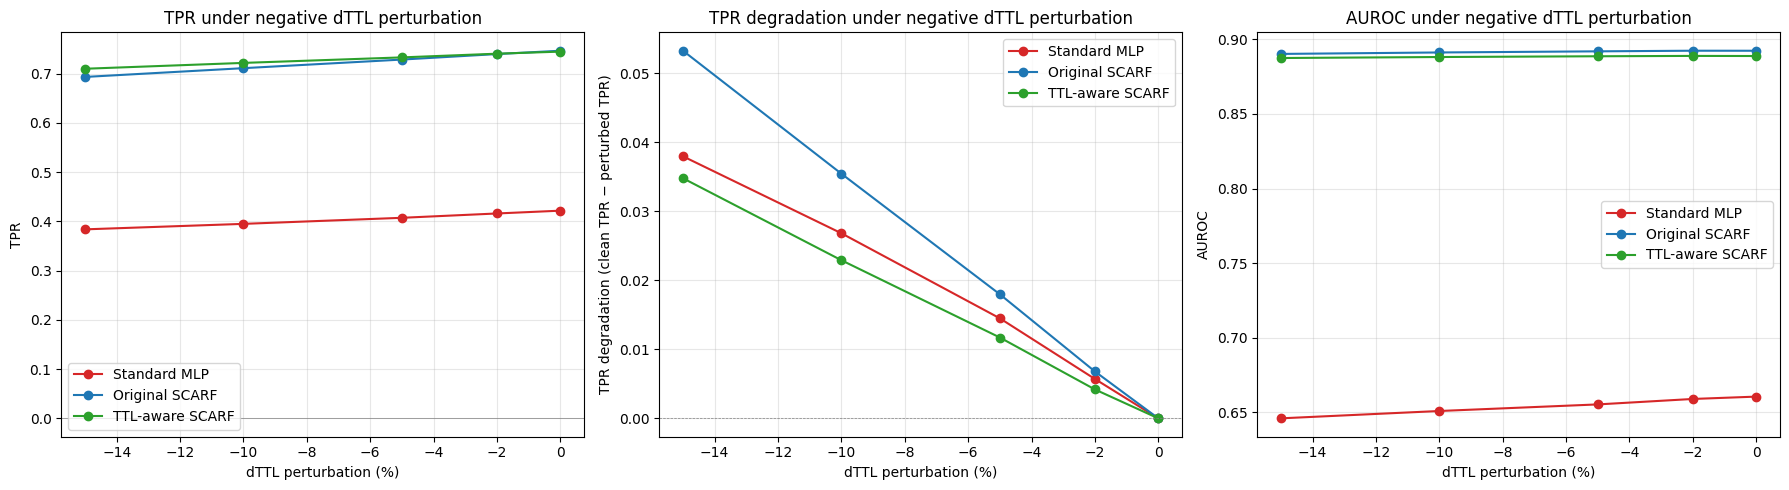


Saved:
FINAL_mlp_dttl_results.csv
FINAL_three_way_comparison.csv
FINAL_mlp_vs_scarf_comparison.png


In [44]:
# =============================================================================
# APPEND THIS AFTER FINAL_scarf_comparison.py (needs final_df from that script,
# plus the standard MLP model + its evaluate function from the baseline cells)
# =============================================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

DTTL_LEVELS = [-2, -5, -10, -15]

# -----------------------------------------------------------------------
# 1. MLP EVALUATION HELPER — matches your frozen baseline (cell 26):
#    mlp_models is a dict {42: model, 123: model, 2026: model}, and
#    `device` is the single global torch.device from that cell.
# -----------------------------------------------------------------------

def evaluate_mlp(model, X, y, device):
    model.eval()
    X_t = torch.tensor(np.asarray(X, dtype=np.float32), device=device)
    y_np = np.asarray(y).reshape(-1).astype(int)
    with torch.no_grad():
        logits = model(X_t).reshape(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_np, preds, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    auc = roc_auc_score(y_np, probs)
    ap = average_precision_score(y_np, probs)
    return tpr, auc, ap


# -----------------------------------------------------------------------
# 2. BUILD MLP ROWS, per-seed, same 3 seeds as SCARF, using the SAME
#    dttl_test_sets so the comparison is apples-to-apples.
# -----------------------------------------------------------------------
# Requires mlp_models (dict keyed by seed) and device from cell 26.

assert "mlp_models" in globals(), "Run cell 26 first (freezes mlp_models)."

mlp_rows = []
for seed in [42, 123, 2026]:
    model = mlp_models[seed]
    seed_device = next(model.parameters()).device  # robust even if `device` changed later

    clean = evaluate_mlp(model, X_test_s, y_test_s, seed_device)
    mlp_rows.append({"Seed": seed, "Model": "Standard MLP", "dTTL_%": 0,
                      "TPR": clean[0], "AUROC": clean[1], "AUPRC": clean[2],
                      "TPR_degradation": 0.0})

    for level in DTTL_LEVELS:
        m = evaluate_mlp(model, dttl_test_sets[level], y_test_s, seed_device)
        mlp_rows.append({"Seed": seed, "Model": "Standard MLP", "dTTL_%": level,
                          "TPR": m[0], "AUROC": m[1], "AUPRC": m[2],
                          "TPR_degradation": clean[0] - m[0]})

mlp_df_raw = pd.DataFrame(mlp_rows)
mlp_df_raw.to_csv("FINAL_mlp_dttl_results_by_seed.csv", index=False)

# Average over seeds to match the SCARF summary format
mlp_df = (mlp_df_raw.groupby(["Model", "dTTL_%"])[["TPR", "AUROC", "AUPRC", "TPR_degradation"]]
          .mean().reset_index())
mlp_df.to_csv("FINAL_mlp_dttl_results.csv", index=False)

# -----------------------------------------------------------------------
# 3. COMBINE MLP + SCARF (Original + TTL-aware) INTO ONE TABLE
# -----------------------------------------------------------------------
# final_df comes from FINAL_scarf_comparison.py (has Seed-level rows for
# Original / TTL-aware SCARF). Average over seeds first for a clean 3-way
# comparison table.

scarf_summary = (
    final_df.groupby(["Model", "dTTL_%"])[["TPR", "AUROC", "AUPRC", "TPR_degradation"]]
    .mean()
    .reset_index()
)

three_way = pd.concat([scarf_summary, mlp_df], ignore_index=True)
three_way = three_way.sort_values(["dTTL_%", "Model"])
three_way.to_csv("FINAL_three_way_comparison.csv", index=False)

print("\n" + "=" * 90)
print("MLP vs ORIGINAL SCARF vs TTL-AWARE SCARF — dTTL COMPARISON")
print("=" * 90)
print(three_way.round(4).to_string(index=False))


# =============================================================================
# 4. VISUALIZATION
# =============================================================================

colors = {"Standard MLP": "#d62728", "Original": "#1f77b4", "TTL-aware": "#2ca02c"}
labels = {"Standard MLP": "Standard MLP", "Original": "Original SCARF", "TTL-aware": "TTL-aware SCARF"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: TPR vs dTTL ---
ax = axes[0]
for model_name in ["Standard MLP", "Original", "TTL-aware"]:
    sub = three_way[three_way["Model"] == model_name].sort_values("dTTL_%")
    ax.plot(sub["dTTL_%"], sub["TPR"], marker="o", label=labels[model_name],
            color=colors[model_name])
ax.set_xlabel("dTTL perturbation (%)")
ax.set_ylabel("TPR")
ax.set_title("TPR under negative dTTL perturbation")
ax.axhline(0, color="gray", linewidth=0.5)
ax.legend()
ax.grid(alpha=0.3)

# --- Panel 2: TPR degradation vs dTTL ---
ax = axes[1]
for model_name in ["Standard MLP", "Original", "TTL-aware"]:
    sub = three_way[three_way["Model"] == model_name].sort_values("dTTL_%")
    ax.plot(sub["dTTL_%"], sub["TPR_degradation"], marker="o", label=labels[model_name],
            color=colors[model_name])
ax.set_xlabel("dTTL perturbation (%)")
ax.set_ylabel("TPR degradation (clean TPR − perturbed TPR)")
ax.set_title("TPR degradation under negative dTTL perturbation")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.legend()
ax.grid(alpha=0.3)

# --- Panel 3: AUROC vs dTTL (ranking-quality stability) ---
ax = axes[2]
for model_name in ["Standard MLP", "Original", "TTL-aware"]:
    sub = three_way[three_way["Model"] == model_name].sort_values("dTTL_%")
    ax.plot(sub["dTTL_%"], sub["AUROC"], marker="o", label=labels[model_name],
            color=colors[model_name])
ax.set_xlabel("dTTL perturbation (%)")
ax.set_ylabel("AUROC")
ax.set_title("AUROC under negative dTTL perturbation")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("FINAL_mlp_vs_scarf_comparison.png", dpi=200)
plt.show()

print("\nSaved:")
print("FINAL_mlp_dttl_results.csv")
print("FINAL_three_way_comparison.csv")
print("FINAL_mlp_vs_scarf_comparison.png")